# Surveillance Perception Study — Data Analysis
**Charlotte Mädler**  
**Master’s Thesis, University of Bonn**

---

# Table of Contents
1. Overview
2. Participant Numbers, Exclusion Reasons
3. Data Cleaning
4. General Results of Questions
5. Verdict on Data Quality, Representativeness
6. Main Hypotheses and corresponding tests
7. Calculation and creation of all necessary measured variables for the main hypotheses
8. Statistical Analysis I
9. Exploratory Hypotheses and corresponding tests
10. Statistical Analysis II
11. Demographic Analysis
12. Other analysis (comparison to trust questions from previous study)

---

## 1. Overview

This is an observational, cross-sectional, between-subjects survey study conducted using Qualtrics as the survey platform and Prolific for recruiting a representative sample of 1,000 U.S. adults.

Participants are randomly assigned to one of two groups that differ in the order of question blocks: one group is first presented with descriptions of surveillance methods, while the other is first asked about the general acceptability of different surveillance types (covert/overt, digital/physical).

Some follow-up questions are conditionally shown (e.g., questions about minority status or justifications for choosing a more invasive surveillance method). 

### Data Quality Controls
- Bot detection (via Recaptcha by Google and Qualtrics meausres)
- One attention check
- Embedded “duration” field to exclude speeders, excluding anyone taking under 1/3 of the median time
- IP and device data (for duplicate screening)

### Randomization Procedures
- **Group Assignment (Between-Subjects)**: Order of blocks (description first vs. judgment first)
- **Question Order Randomization (Within-Subjects)**: Randomized response option order, unless ordinal
- **Formulation Bias Control**: Random direction for comparative formulations (e.g., “digital vs. physical”)

All randomizations are implemented using Qualtrics’ built-in simple randomization features.

### Ethics
Sensitive questions include a “Prefer not to answer” option to protect participant privacy.




In [1]:
# === Basic Setup ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# === Statistical Packages ===
from collections import Counter
from scipy.stats import (
    shapiro,
    wilcoxon,
    ttest_rel,
    mannwhitneyu,
    spearmanr,
    kruskal,
    binomtest,
    norm,
    chi2_contingency,
    chisquare
)
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import scikit_posthocs as sp
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats


# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

# Load survey data
df = pd.read_csv("MasterData.csv")
df.head()


,Progress,Duration (in seconds),Finished,ResponseId,Q_RecaptchaScore,Consent,Q1_1,Q1_2,Q1_3,Q1_4,Q2_1,Q2_2,Q2_3,Q2_4,Time 1_First Click,Time 1_Last Click,Time 1_Page Submit,Time 1_Click Count,Q3.1,Q3.2,Q157,Q8,Q8_DO_1,Q8_DO_2,Q8_DO_3,Time 3.1_First Click,Time 3.1_Last Click,Time 3.1_Page Submit,Time 3.1_Click Count,Q9,Q9_DO_1,Q9_DO_2,Q9_DO_3,Q11,Q10,Time 3.2_First Click,Time 3.2_Last Click,Time 3.2_Page Submit,Time 3.2_Click Count,Q153_1,Q153_2,Q153_DO_1,Q153_DO_2,Q135,Q160,Q160_DO_1,Q160_DO_2,Q160_DO_3,Q151,Q161,Q161_DO_1,Q161_DO_2,Q161_DO_3,Q171,Q171_DO_1,Q171_DO_2,Q171_DO_3,Q152,Time 4_First Click,Time 4_Last Click,Time 4_Page Submit,Time 4_Click Count,Q14_1,Q14_2,Q14_3,Q14_DO_Q14_1,Q14_DO_Q14_2,Q14_DO_Q14_3,Q138,Q15,Q16,Q17,AC,AC_DO_1,AC_DO_2,AC_DO_3,Q18,Time 5_First Click,Time 5_Last Click,Time 5_Page Submit,Time 5_Click Count,Q169_1,Q169_2,Q169_3,Q169_4,Q169_5,Q169_6,Q169_7,Q169_8,Q169_DO_Q169_1,Q169_DO_Q169_2,Q169_DO_Q169_3,Q169_DO_Q169_4,Q169_DO_Q169_5,Q169_DO_Q169_6,Q169_DO_Q169_7,Q169_DO_Q169_8,Time 6.1_First Click,Time 6.1_Last Click,Time 6.1_Page Submit,Time 6.1_Click Count,Q164_1,Q164_2,Q164_3,Q164_4,Q164_5,Q164_6,Q164_7,Q164_8,Q164_DO_Q164_1,Q164_DO_Q164_2,Q164_DO_Q164_3,Q164_DO_Q164_4,Q164_DO_Q164_5,Q164_DO_Q164_6,Q164_DO_Q164_7,Q164_DO_Q164_8,Time 6.2_First Click,Time 6.2_Last Click,Time 6.2_Page Submit,Time 6.2_Click Count,Q129,Q128,Q131,Q145,Q147,Q170_1,Q170_2,Q170_3,Q170_4,Q170_8,Q170_5,Q170_6,Q170_5_TEXT,Q149,Q150,Q21.1,Q21.2_1,Q21.2_2,Q21.2_3,Q21.2_DO_1,Q21.2_DO_2,Q21.2_DO_3,Time 7_First Click,Time 7_Last Click,Time 7_Page Submit,Time 7_Click Count,Q173,Q181_1,Q181_2,Q181_3,Q181_4,Q181_ADO_1,Q181_ADO_2,Q181_ADO_3,Q182,Q130,Q23,Q23_4_TEXT,Q24,Q25_4,Q25_5,Q25_6,Q25_5_TEXT,Q98_1,Q98_7,Q98_2,Q98_4,Q98_8,Q98_3,Q98_5,Q98_6,Q98_9,Q98_6_TEXT,Q134_4,Q134_5,Q134_6,Q134_7,Q134_8,Q134_9,Q134_10,Q27_1,Q28,Q28_4_TEXT,Q106,Q107,Time 8_First Click,Time 8_Last Click,Time 8_Page Submit,Time 8_Click Count,Finish,FL_3_DO_FL_5,FL_3_DO_FL_297,02InvasivenessPerceptionA/B_DO_Q3.2,02InvasivenessPerceptionA/B_DO_Q3.1
0,100,503,1,R_2xUYTT4usndL3h1,0.9,1,1.0,1.0,1.0,1.0,1.0,2.0,1.0,2.0,7.414,23.159,23.166,9.0,2.0,NaN,4.0,2.0,2.0,1.0,3.0,3.367,8.904,8.908,3.0,2.0,3.0,1.0,2.0,5.0,5.0,3.973,10.180,10.186,4.0,10.0,5.0,1.0,2.0,2.0,1.0,3.0,2.0,1.0,5.0,1.0,3.0,1.0,2.0,NaN,NaN,NaN,NaN,1.0,4.041,6.720,6.723,3.0,3.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,5.0,5.0,2.0,1.0,3.0,2.0,4.0,2.779,27.553,27.557,10.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,6.0,8.0,5.0,2.0,1.0,3.0,7.0,10.588,24.042,24.045,9.0,1.0,2.0,1.0,1.0,1.0,1.0,5.0,1.0,5.0,8.0,6.0,1.0,2.0,3.0,7.0,4.0,4.779,19.798,19.804,9.0,NaN,NaN,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,1.0,2.0,4.0,4.0,3.0,2.0,1.0,8.877,17.117,17.121,5.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,1.0,-99,23.0,1.0,-99.0,-99.0,-99,-99.0,-99.0,1.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99,-99.0,-99.0,-99.0,-99.0,-99.0,1.0,-99.0,90.0,2.0,-99,5.0,4.0,1.751,81.287,81.291,13.0,-99,1.0,NaN,NaN,1.0
1,100,480,1,R_26gWkBRvK2ilG70,1.0,1,1.0,1.0,2.0,3.0,3.0,3.0,2.0,2.0,15.005,59.914,59.930,9.0,NaN,2.0,3.0,3.0,3.0,1.0,2.0,5.600,14.005,14.019,3.0,3.0,3.0,2.0,1.0,4.0,4.0,10.168,26.717,26.722,4.0,2.0,3.0,1.0,2.0,1.0,3.0,3.0,1.0,2.0,5.0,3.0,1.0,3.0,2.0,NaN,NaN,NaN,NaN,1.0,3.618,6.857,6.866,3.0,2.0,2.0,2.0,2.0,3.0,1.0,4.0,4.0,3.0,2.0,2.0,1.0,2.0,3.0,2.0,8.230,63.407,63.420,10.0,1.0,2.0,2.0,4.0,1.0,4.0,1.0,2.0,8.0,6.0,4.0,1.0,7.0,2.0,5.0,3.0,11.649,54.387,54.405,9.0,3.0,3.0,1.0,2.0,3.0,2.0,4.0,4.0,8.0,3.0,5.0,2.0,7.0,6.0,4.0,1.0,10.714,42.496,42.513,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,6.218,22.892,22.904,2.0,4.0,1.0,2.0,2.0,3.0,2.0,3.0,1.0,-99,7.0,2.0,-99,42.0,1.0,-99.0,-99.0,-99,1.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99,-99.0,-99.0,-99.0,-99.0,-99.0,1.0,-99.0,40.0,1.0,-99,5.0,4.0,9.487,56.043,56.051,12.0,-99,1.0,NaN,1.0,NaN
2,100,749,1,R_3lY9rQS67s8LLdC,0.9,1,2.0,3.0,1.0,2.0,1.0,2.0,2.0,1.0,280.353,284.771,284.782,17.0,2.0,NaN,3.0,3.0,3.0,1.0,2.0,1.355,3.312,3.335,3.0,3.0,3

# 2.Partipants
Inclusion criteria:  
-Age 18 or older  
-Consent given  
-Currently residing in the United States  
-Fluent in English  
-Passed Prolific’s pre-screening for representative eligibility  

Exclusion criteria:  
-Participants who fail the attention check  
-Participants flagged as bots or providing incomplete responses  
-Participants who complete the survey in less than 1/3 of the median completion time  
-Participants who did not consent to the study  
-Participants who did not complete the study  

Each participant is compensated at a fair hourly rate, in line with or exceeding Prolific’s minimum pay guidelines.

Recruitment and data collection are expected to be completed within less than a week

The study will analyze data from 1,000 individual participants, all adults residing in the United States. Each participant completes the survey once, providing a single data point per variable measured. This sample size was determined using G*Power to provide sufficient power (0.80) to detect small to medium effect sizes (e.g. r=0.1, r=0.3) in the key relationships, such as between trust in institutions and acceptance of surveillance methods, at the standard .05 alpha error probability. Additionally, a margin was added for answers that will be excluded from analysis.

In [2]:
# Initial number of responses
initial_n = df.shape[0]
print(f"Initial sample size: {initial_n}")

Initial sample size: 1089


In [3]:
#Excluding Participants
df_clean = pd.read_csv("MasterData.csv", header=0)

# Convert relevant columns to numeric
df_clean['Duration (in seconds)'] = pd.to_numeric(df_clean['Duration (in seconds)'], errors='coerce')
df_clean['Q_RecaptchaScore'] = pd.to_numeric(df_clean['Q_RecaptchaScore'], errors='coerce')

# Compute threshold for speeders (1/3 of median)
median_duration = df_clean['Duration (in seconds)'].median()
duration_threshold = median_duration / 3

#xclusion criteria
df_clean['AC_clean'] = df_clean['AC'].astype(str).str.strip()
df_clean['fail_attention'] = df_clean['AC_clean'] != '2.0'
df_clean['fail_recaptcha'] = df_clean['Q_RecaptchaScore'] < 0.5
df_clean['fail_duration'] = (df_clean['Duration (in seconds)'] < duration_threshold) | (df_clean['Duration (in seconds)'].isna())
df_clean['fail_consent'] = df_clean['Consent'] == 2
df_clean['fail_complete'] = df_clean['Finished'] == 0

# Combine
df_clean['exclude'] = (
    df_clean['fail_attention'] |
    df_clean['fail_recaptcha'] |
    df_clean['fail_duration'] |
    df_clean['fail_consent'] |
    df_clean['fail_complete']
)

#filtered dataset
df_included = df_clean[~df_clean['exclude']]

# Print
print("Total participants:", len(df_clean))
print("Excluded due to failed attention check:", df_clean['fail_attention'].sum())
print("Excluded due to low Recaptcha score:", df_clean['fail_recaptcha'].sum())
print("Excluded due to short duration:", df_clean['fail_duration'].sum())
print("Median:", median_duration)
print("Median / 3:", duration_threshold)
print("Excluded due to no consent:", df_clean['fail_consent'].sum())
print("Excluded due to non completion:", df_clean['fail_complete'].sum())
print("Excluded for any reason:", df_clean['exclude'].sum())
print("Final included participants:", len(df_included))



Total participants: 1089
Excluded due to failed attention check: 47
Excluded due to low Recaptcha score: 44
Excluded due to short duration: 23
Median: 584.0
Median / 3: 194.66666666666666
Excluded due to no consent: 1
Excluded due to non completion: 44
Excluded for any reason: 107
Final included participants: 982


# 3.Data Cleaning and Preperation
Several steps were performed to prepare the data for analysis.  
a) Categorizing "other" answers that were free-text into useable categories for demographics (Gender, Nationality, Ethnicity, Political Preferences)  
b) Questions posed in two directions (digital first/physical first) in a uniform answer  
c) Summing up responses from Multiple Choice question with multiple answer possibilities into one answer

In [4]:
#Preprocess
df_included["Duration (in seconds)"] = pd.to_numeric(df_included["Duration (in seconds)"], errors="coerce")
valid_durations = df_included["Duration (in seconds)"].dropna()

# Calculate average and median
average_duration = valid_durations.mean()
median_duration = valid_durations.median()

# print
print(f"Average Duration: {average_duration:.2f} seconds")
print(f"Median Duration: {median_duration:.2f} seconds")

# Convert to minutes
valid_durations_min = valid_durations / 60

# Calculate average and median
average_duration_min = valid_durations_min.mean()
median_duration_min = valid_durations_min.median()

# print
print(f"Average Duration: {average_duration_min:.2f} minutes")
print(f"Median Duration: {median_duration_min:.2f} minutes")


Average Duration: 701.22 seconds
Median Duration: 587.00 seconds
Average Duration: 11.69 minutes
Median Duration: 9.78 minutes


C:\Users\charl\AppData\Local\Temp\ipykernel_23760\1463836104.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_included["Duration (in seconds)"] = pd.to_numeric(df_included["Duration (in seconds)"], errors="coerce")


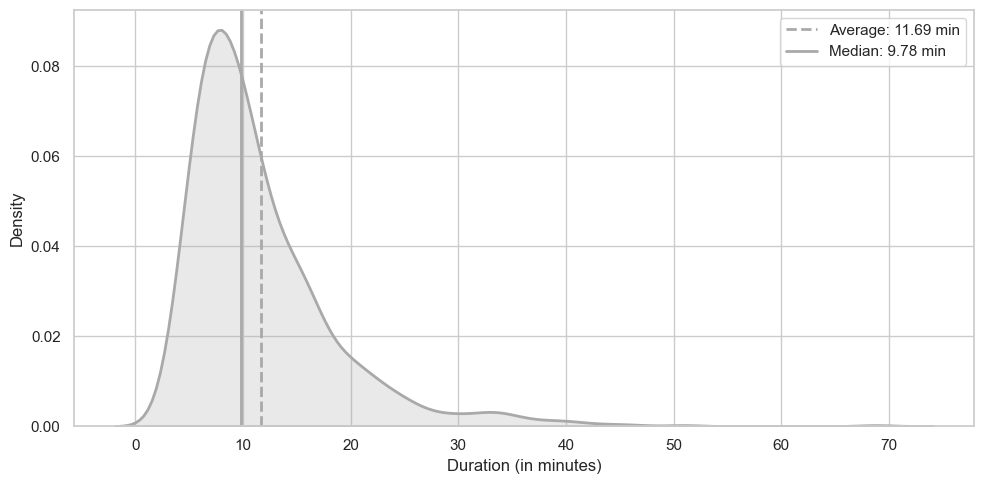

In [5]:
# Plot
plt.figure(figsize=(10, 5))
sns.kdeplot(valid_durations_min, fill=True, color='darkgray', linewidth=2)
plt.axvline(average_duration_min, color='darkgray', linestyle='--', linewidth=2, label=f'Average: {average_duration_min:.2f} min')
plt.axvline(median_duration_min, color='darkgray', linestyle='-', linewidth=2, label=f'Median: {median_duration_min:.2f} min')
plt.legend()
plt.xlabel("Duration (in minutes)")
plt.tight_layout()
plt.show()


In [6]:
df_raw = pd.read_csv("data.csv")

# Convert StartDate and EndDate to datetime
df_raw['StartDate'] = pd.to_datetime(df_raw['StartDate'], errors='coerce')
df_raw['EndDate'] = pd.to_datetime(df_raw['EndDate'], errors='coerce')

# Find first and last timestamps
first_started = df_raw['StartDate'].min()
last_ended = df_raw['EndDate'].max()

print(f"First response started: {first_started}")
print(f"Last response ended: {last_ended}")



First response started: 2025-05-27 16:41:02
Last response ended: 2025-06-03 16:54:12


C:\Users\charl\AppData\Local\Temp\ipykernel_23760\1993007915.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw['StartDate'] = pd.to_datetime(df_raw['StartDate'], errors='coerce')
C:\Users\charl\AppData\Local\Temp\ipykernel_23760\1993007915.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw['EndDate'] = pd.to_datetime(df_raw['EndDate'], errors='coerce')


In [7]:
#Data Cleaning: Demographics Analysis of "other" answer options
for col in ['Q23_4_TEXT', 'Q25_5_TEXT', 'Q98_6_TEXT', 'Q28_4_TEXT']:
    print(f"\nUnique values in {col}:")
    print(df_included[col].dropna().unique())



Unique values in Q23_4_TEXT:
['-99' 'transgender woman']

Unique values in Q25_5_TEXT:
['-99' 'Africa American' 'British' 'German' 'South Africa' 'Netherlands'
 'Ethiopian' 'SOUTH AFRICA' 'Chinese' 'Brazilian' 'mexican' 'Mexican'
 'Russian' 'Haiti' 'Mexican-American']

Unique values in Q98_6_TEXT:
['-99' 'Native Black American' 'African' 'European American' 'caribbean'
 'Hebrew' 'mixed' 'Mixed' 'Native American' 'Black and White'
 'Indigenous American' 'Human' 'American Citizen']

Unique values in Q28_4_TEXT:
['-99'
 'Libertarian if good candidate, otherwise republican but never ever psychotic ignorant evil country destroying left.'
 'I vote for the person, not the party' 'PSL' 'Green'
 'I would vote for the best candidate, in my opinion, regardless of party.'
 'whoever I believe e is best for the job'
 'no party affiliation at all, including with your so called independent party listed above because if it is a party and you belong to it, THENTHERE IS NO WAY IN HELL YOU ARE AN INDEPEN

In [8]:
#Gender does not need to be cleaned, as there was exactly one response "other", hence the code 4 now becomes that response. 
# 1:Male, 2:Female, 3: Non-Binary, 4: Transgender Woman (self described), 5: Prefer not to say
# Define labels
gender_labels = {
    1: "Male",
    2: "Female",
    3: "Non-Binary",
    4: "Transgender Woman",
    5: "Prefer not to say"
}

# Convert to numeric
df_included.loc[:, 'Q23'] = pd.to_numeric(df_included['Q23'], errors='coerce')

# Count and map
gender_counts = df_included['Q23'].value_counts().sort_index()
gender_counts.index = gender_counts.index.map(gender_labels)

# Output
print("=== Gender Distribution (Count) ===")
print(gender_counts)

print("\n=== Gender Distribution (Percent) ===")
print((gender_counts / gender_counts.sum() * 100).round(1))


=== Gender Distribution (Count) ===
Q23
Male                 467
Female               503
Non-Binary             8
Transgender Woman      1
Prefer not to say      3
Name: count, dtype: int64

=== Gender Distribution (Percent) ===
Q23
Male                 47.6
Female               51.2
Non-Binary            0.8
Transgender Woman     0.1
Prefer not to say     0.3
Name: count, dtype: float64


Overall close (very lightly underrespresented male)

In [9]:
#Clean Nationality
# normalize free-text field
df_included.loc[:, 'Q25_5_clean'] = df_included['Q25_5_TEXT'].str.strip().str.lower()


dual_keywords = ['africa american', 'mexican-american'] # recoding key words

def classify_nationality(row):
    is_american = row['Q25_4'] == 1
    is_other = row['Q25_5'] == 1
    is_prefer_not = row['Q25_6'] == 1
    other_text = str(row['Q25_5_clean']).lower()
    
    # Manual override
    if any(k in other_text for k in dual_keywords):
        return 2  # Dual citizenship
    if is_american and is_other:
        return 2
    elif is_american:
        return 1
    elif is_other:
        return 3
    elif is_prefer_not:
        return 4
    #else:
    #   return 4  # fallback: prefer not to say

df_included.loc[:, 'Nationality_Cleaned'] = df_included.apply(classify_nationality, axis=1)

#Create label mapping
nationality_label_map = {
    1: 'US American',
    2: 'Dual Citizenship',
    3: 'Non-American',
    4: 'Prefer not to answer'
}

df_included.loc[:, 'Nationality_Label'] = df_included['Nationality_Cleaned'].map(nationality_label_map)

# Count and print
counts_labeled = df_included['Nationality_Label'].value_counts()
percentages = (counts_labeled / counts_labeled.sum()) * 100

print("=== Nationality (Labeled) ===")
print(counts_labeled)

print("\n=== Percentages ===")
print(percentages.round(1))

=== Nationality (Labeled) ===
Nationality_Label
US American             962
Non-American             14
Dual Citizenship          3
Prefer not to answer      3
Name: count, dtype: int64

=== Percentages ===
Nationality_Label
US American             98.0
Non-American             1.4
Dual Citizenship         0.3
Prefer not to answer     0.3
Name: count, dtype: float64


C:\Users\charl\AppData\Local\Temp\ipykernel_23760\3783612086.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_included.loc[:, 'Q25_5_clean'] = df_included['Q25_5_TEXT'].str.strip().str.lower()
C:\Users\charl\AppData\Local\Temp\ipykernel_23760\3783612086.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_included.loc[:, 'Nationality_Cleaned'] = df_included.apply(classify_nationality, axis=1)
C:\Users\charl\AppData\Local\Temp\ipykernel_23760\3783612086.py:38: SettingWithCopyWarning: 
A value is try

C:\Users\charl\AppData\Local\Temp\ipykernel_23760\3780818773.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_included.loc[:, 'Ethnicity_Code'] = df_included.apply(classify_ethnicity_numeric, axis=1)
C:\Users\charl\AppData\Local\Temp\ipykernel_23760\3780818773.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_included.loc[:, 'Ethnicity_Label'] = df_included['Ethnicity_Code'].map(ethnicity_label_map)


Ethnicity_Label
White/Caucasian            624
Black, African American    135
Hispanic, Latino/a          62
Asian                       54
Mixed (Other)               22
Mixed: White + Hispanic     19
Mixed: White + Black        18
Mixed: White + Asian        16
Other                       14
Indigenous                  12
Prefer not to say            6
Name: count, dtype: int64


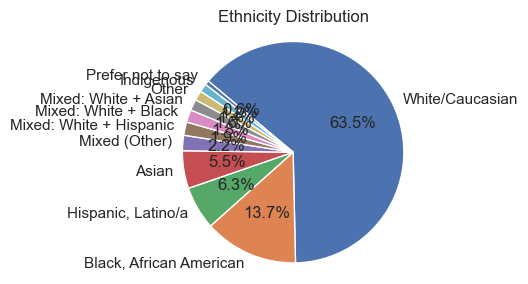

In [10]:
#Clean Ethnicity
#classify each participant's ethnicity
def classify_ethnicity_numeric(row):
    white = row['Q98_1'] == 1
    black = row['Q98_2'] == 1
    indigenous = row['Q98_3'] == 1
    asian = row['Q98_4'] == 1
    hispanic = row['Q98_7'] == 1
    prefer_not = row['Q98_9'] == 1
    other_text = str(row.get('Q98_6_TEXT', '')).strip().lower()

    # Count selected options
    selected_flags = [white, black, indigenous, asian, hispanic]
    total_selected = sum(selected_flags)

    # Handle missing/prefer not to say
    if prefer_not:
        return 11

    # Text-based overrides (free text)
    if other_text in ['native american', 'indigenous american']:
        return 5
    if other_text == 'black and white':
        return 8
    if other_text in ['mixed', 'native black american', 'hebrew', 'human', 'caribbean', 'american citizen', 'african']:
        return 9 if white else 10
    if other_text == 'european american':
        return 1

    # Mixed combinations
    if white and black and total_selected == 2:
        return 8
    if white and hispanic and total_selected == 2:
        return 6
    if white and asian and total_selected == 2:
        return 7
    if white and indigenous and total_selected == 2:
        return 9

    # Single group categories
    if white and total_selected == 1:
        return 1
    if hispanic and total_selected == 1:
        return 2
    if black and total_selected == 1:
        return 3
    if asian and total_selected == 1:
        return 4
    if indigenous and total_selected == 1:
        return 5

    # Fallback option
    return 9 if total_selected > 1 else 10


df_included.loc[:, 'Ethnicity_Code'] = df_included.apply(classify_ethnicity_numeric, axis=1)

# Mapping for readability
ethnicity_label_map = {
    1: 'White/Caucasian',
    2: 'Hispanic, Latino/a',
    3: 'Black, African American',
    4: 'Asian',
    5: 'Indigenous',
    6: 'Mixed: White + Hispanic',
    7: 'Mixed: White + Asian',
    8: 'Mixed: White + Black',
    9: 'Mixed (Other)',
    10: 'Other',
    11: 'Prefer not to say'
}
df_included.loc[:, 'Ethnicity_Label'] = df_included['Ethnicity_Code'].map(ethnicity_label_map)

# Count and plotting time
ethnicity_counts = df_included['Ethnicity_Label'].value_counts()
print(ethnicity_counts)

plt.figure(figsize=(5, 3))
plt.pie(
    ethnicity_counts,
    labels=ethnicity_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    counterclock=False
)
plt.title('Ethnicity Distribution')
plt.axis('equal') #Equal ensures circle
plt.tight_layout()
plt.show()



White/caucasian is slightly oversampled, Hispanic is slightly undersampled. Other categories fit roughly well.

In [11]:
#Political Affiliation does not need to be cleaned, as the other group is very small (11 or less) and no significant groups can be found in the answers
#Answers include: 4 I vote for the person, 3 libertarian, 2 green, 1 PSL, 1 maybe no one

# Labels
political_labels = {
    1: "Democratic Party",
    2: "Republican Party",
    3: "Independent",
    4: "Other",
    5: "I can not vote",
    6: "I would not vote",
    7: "Prefer not to answer"
}

# ensure numeric
df_included.loc[:, 'Q28'] = pd.to_numeric(df_included['Q28'], errors='coerce')

# Count, label and print
political_counts = df_included['Q28'].value_counts().sort_index()
political_counts.index = political_counts.index.map(political_labels)

print("=== Political Affiliation (Count) ===")
print(political_counts)

print("\n=== Political Affiliation (Percent) ===")
print((political_counts / political_counts.sum() * 100).round(1))


=== Political Affiliation (Count) ===
Q28
Democratic Party        387
Republican Party        383
Independent             142
Other                    11
I can not vote            8
I would not vote         35
Prefer not to answer     16
Name: count, dtype: int64

=== Political Affiliation (Percent) ===
Q28
Democratic Party        39.4
Republican Party        39.0
Independent             14.5
Other                    1.1
I can not vote           0.8
I would not vote         3.6
Prefer not to answer     1.6
Name: count, dtype: float64


=== Full Sector Combination Counts (up to 5 selections) ===
Sector_Combo
C                         2
C+G                       1
C+G+I                     5
C+G+I+M                   3
C+G+M                     1
C+I                      12
C+I+L+M                   1
C+I+M                     2
G                        77
G+I                      12
G+I+L                     2
G+I+M                     1
G+L                       1
G+M                       1
I                       202
I+L                       2
I+M                       8
L                         6
M                        18
None of the above       599
Prefer not to answer     26
Name: count, dtype: int64
=== Merged Sector Combination Counts ===
Sector_Combo_Merged
C                        14
C+G                       6
C+G+M                     4
C+I+L+M                   1
C+I+M                     2
G                        77
G+I                      12
G+I+L                     2
G+I+M                     1


C:\Users\charl\AppData\Local\Temp\ipykernel_23760\2081943854.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_included.loc[:, 'Sector_Combo'] = df_included.apply(classify_sector_full, axis=1)
C:\Users\charl\AppData\Local\Temp\ipykernel_23760\2081943854.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_included.loc[:, 'Sector_Combo_Merged'] = df_included['Sector_Combo'].replace(merge_map)


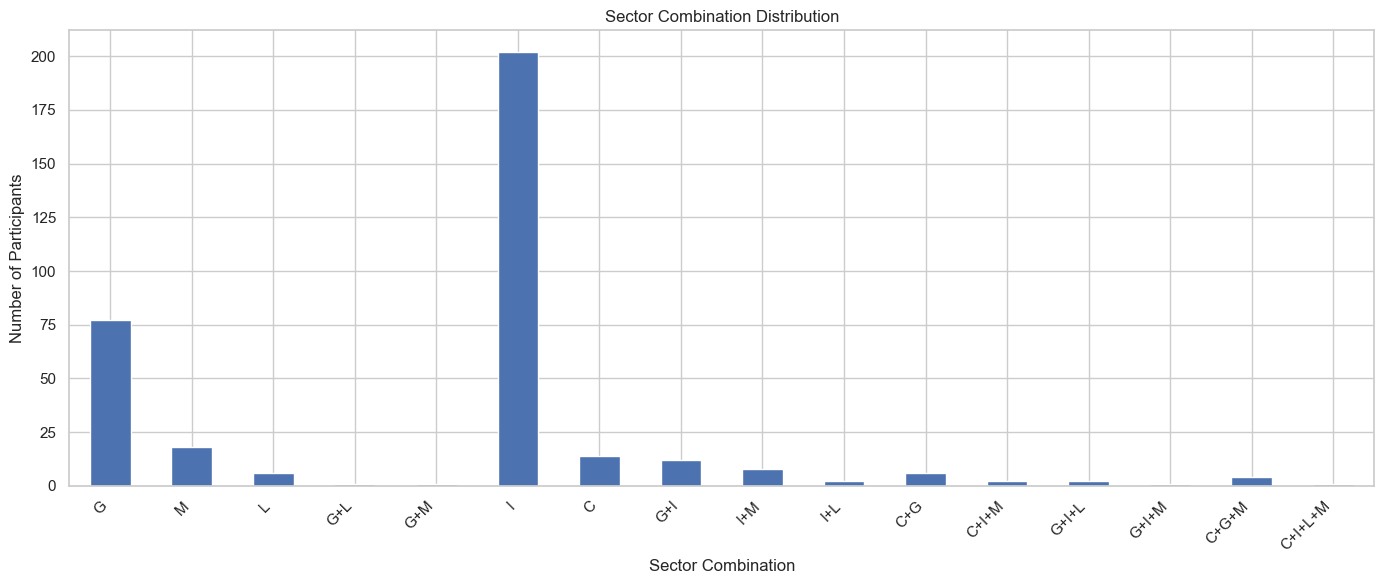

=== Exclusive Sector Groups ===
Sector_Group_Exclusive
None                 599
Cyber/IT             216
Government            95
Law/Military          46
Prefer not to say     26
Name: count, dtype: int64


In [12]:
#Work Sector
sector_cols = ['Q134_4', 'Q134_5', 'Q134_6', 'Q134_7', 'Q134_8', 'Q134_9', 'Q134_10']
code_map = {
    'Q134_4': 'G',  # Government
    'Q134_5': 'M',  # Military
    'Q134_6': 'L',  # Law Enforcement
    'Q134_7': 'I',  # IT/Tech
    'Q134_8': 'C'   # Cybersecurity
}

for col in sector_cols:
    df_included.loc[:, col] = pd.to_numeric(df_included[col], errors='coerce')

def classify_sector_full(row):
    selected = [code for col, code in code_map.items() if row[col] == 1.0]
    none_selected = row['Q134_9'] == 1.0
    prefer_not_selected = row['Q134_10'] == 1.0
    
    if len(selected) > 0:
        return '+'.join(sorted(selected))  # all combinations allowed
    elif none_selected:
        return 'None of the above'
    elif prefer_not_selected:
        return 'Prefer not to answer'
    else:
        return None  # fallback


df_included.loc[:, 'Sector_Combo'] = df_included.apply(classify_sector_full, axis=1)

# Count results and print
sector_combo_counts = df_included['Sector_Combo'].value_counts().sort_index()
print("=== Full Sector Combination Counts (up to 5 selections) ===")
print(sector_combo_counts)

# Merge specific combinations
merge_map = {
    'C+I': 'C',
    'C+G': 'C+G',
    'C+G+I': 'C+G',
    'C+G+M': 'C+G+M',
    'C+G+I+M': 'C+G+M'
}

df_included.loc[:, 'Sector_Combo_Merged'] = df_included['Sector_Combo'].replace(merge_map)

# Count and dprint
merged_counts = df_included['Sector_Combo_Merged'].value_counts().sort_index()

print("=== Merged Sector Combination Counts ===")
print(merged_counts)

display_order = [                                               #defining specific order
    'G', 'M', 'L', 'G+L', 'G+M', 'I', 'C', 'G+I', 'I+M', 'I+L',
    'C+G', 'C+I+M', 'G+I+L', 'G+I+M', 'C+G+M', 'C+I+L+M'
]

plot_data = df_included['Sector_Combo_Merged'].value_counts().reindex(display_order, fill_value=0) # fill 0 if count is missing

# Plot
plt.figure(figsize=(14, 6))
plot_data.plot(kind='bar')
plt.title("Sector Combination Distribution")
plt.xlabel("Sector Combination")
plt.ylabel("Number of Participants")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

valid_sector_df = df_included[df_included['Sector_Combo_Merged'].notna()].copy()
sector_cols = ['Q134_4', 'Q134_5', 'Q134_6', 'Q134_7', 'Q134_8', 'Q134_9', 'Q134_10', 'Sector_Combo_Merged'] # Relevant columns
df_included = df_included.dropna(subset=sector_cols, how='all').copy() # Drop rows that are NaN or empty

# Exclusive Sector Groups
def assign_sector_group(row):
    combo = row['Sector_Combo_Merged']
    if 'L' in combo or 'M' in combo:
        return 'Law/Military'
    if 'G' in combo:
        return 'Government'
    if 'I' in combo or 'C' in combo:
        return 'Cyber/IT'
    if combo == 'None of the above':
        return 'None'
    if combo == 'Prefer not to answer':
        return 'Prefer not to say'
    return 'Unknown'


valid_sector_df.loc[:, 'Sector_Group_Exclusive'] = valid_sector_df.apply(assign_sector_group, axis=1)       # Apply to valid rows only
df_included = df_included.copy()
df_included.loc[valid_sector_df.index, 'Sector_Group_Exclusive'] = valid_sector_df['Sector_Group_Exclusive']

# Count and print :)
group_counts = df_included['Sector_Group_Exclusive'].value_counts()
print("=== Exclusive Sector Groups ===")
print(group_counts)


In [13]:

def assign_sector_group(row):
    combo = row['Sector_Combo']
    if pd.isna(combo):
        return None
    elif all(s in combo.split('+') for s in ['G', 'M', 'L']):
        return 'Gov+Law+Mil'
    elif any(s in combo for s in ['G', 'L', 'M']) and not any(s in combo for s in ['C', 'I']):
        return 'Only Government'
    elif any(s in combo for s in ['C', 'I']) and not any(s in combo for s in ['G', 'L', 'M']):
        return 'Only Tech'
    elif 'None of the above' in combo:
        return 'None'
    elif 'Prefer not to answer' in combo:
        return 'Prefer not to say'
    else:
        return 'Mixed'

df_included['Sector_Group_Strict'] = df_included.apply(assign_sector_group, axis=1)


In [14]:
#Merge Digital/Physical Ordering Questions
#Surveillance of the digital space feels _________  compared to the physical space. (Q3.1) (1:Digital more invasive, 2:equal, 3:Physical more invasive)
#Surveillance of the physical space feels _________  compared to the digital space. (Q3.2) (1:Physical more invasive, 2:equal, 3:Digital more invasive)

# Ensure numeric
df_included.loc[:, 'Q3.1'] = pd.to_numeric(df_included['Q3.1'], errors='coerce')
df_included.loc[:, 'Q3.2'] = pd.to_numeric(df_included['Q3.2'], errors='coerce')

# Create merged invasiveness column
def merge_invasiveness(row):
    if row['Q3.1'] == 1 or row['Q3.2'] == 3:
        return 1  # Digital more invasive
    elif row['Q3.1'] == 2 or row['Q3.2'] == 2:
        return 2  # Equally invasive
    elif row['Q3.1'] == 3 or row['Q3.2'] == 1:
        return 3  # Physical more invasive
    else:
        return np.nan  # no answer

df_included.loc[:, 'Invasiveness_Merged'] = df_included.apply(merge_invasiveness, axis=1)

# Print with labels
labels = {
    1: "Digital more invasive",
    2: "Equally invasive",
    3: "Physical more invasive"
}

merged_counts = df_included['Invasiveness_Merged'].value_counts().sort_index()
print("=== Invasiveness Merged Distribution ===")
print(merged_counts.rename(index=labels))

# more labels for the seperate listing option
invasiveness_labels = {
    1: "More invasive",
    2: "Equally invasive",
    3: "Less invasive"
}

# Count and print Q3.1 (digital feels...)
q31_counts = df_included['Q3.1'].value_counts().sort_index()
print("=== Q3.1: Digital vs Physical Surveillance ===")
print(q31_counts.rename(index=invasiveness_labels))

# Count and print Q3.2 (physical feels...)
q32_counts = df_included['Q3.2'].value_counts().sort_index()
print("\n=== Q3.2: Physical vs Digital Surveillance ===")
print(q32_counts.rename(index=invasiveness_labels))


=== Invasiveness Merged Distribution ===
Invasiveness_Merged
Digital more invasive     286
Equally invasive          435
Physical more invasive    261
Name: count, dtype: int64
=== Q3.1: Digital vs Physical Surveillance ===
Q3.1
More invasive       218
Equally invasive    248
Less invasive        57
Name: count, dtype: int64

=== Q3.2: Physical vs Digital Surveillance ===
Q3.2
More invasive       204
Equally invasive    187
Less invasive        68
Name: count, dtype: int64


Very noteable is the ordering bias. Partipants are far more likely to select more invasive than less invasive. The distributions are very similar.

In [15]:
# Show all unique cleaned responses in Question what other surveillance meassures the police should use more (free text)

unique_q170_5 = (
    df_included['Q170_5_TEXT']
    .dropna()                             # Remove NaN values
    .astype(str).str.strip().str.lower() # Normalize text
    .unique()
)

# Sort and print
for entry in sorted(unique_q170_5):
    print(entry)


-99
all the above
cameras public areas
cctv
how about neighborhood patrols more frequently?
idk if this helps --- less tactical empathy, more real empathy.
increased use of drones
just all types of surveillance that fight crime in general
keeping track of criminals
license plate readers
more public cams and access
private financial transactions data of those in the highest tax brackets.
self regulation of law officers


In [16]:
#Cleaning of question Which surveillance methods do you think law enforcement is currently lacking or should have greater access
# to in order to better address organized and/or everyday crime? 

# Mapping of free text answers to categories
free_text_map = {
    'all the above': 7,
    'cameras public areas': 8,
    'cctv': 8,
    'how about neighborhood patrols more frequently?': 9,
    'idk if this helps --- less tactical empathy, more real empathy.': 9,
    'increased use of drones': 10,
    'just all types of surveillance that fight crime in general': 7,
    'keeping track of criminals': 10,
    'license plate readers': 10,
    'more public cams and access': 8,
    'private financial transactions data of those in the highest tax brackets.': 2,
    'self regulation of law officers': 9
}

# Assign categories
def assign_surveillance_categories(row):
    selected = []

    if row.get('Q170_1') == 1:
        selected.append(1)
    if row.get('Q170_2') == 1:
        selected.append(2)
    if row.get('Q170_3') == 1:
        selected.append(3)
    if row.get('Q170_4') == 1:
        selected.append(4)
    if row.get('Q170_8') == 1:
        selected.append(5)
    if row.get('Q170_6') == 1:
        selected.append(6)  # None of the above

    # Check for all of the above
    if all(row.get(f'Q170_{i}') == 1 for i in (1, 2, 3, 4, 8)):
        selected.append(7)

    # Handle freetext (Q170_5_TEXT)
    other_text = str(row.get('Q170_5_TEXT', '')).strip().lower()
    if other_text in free_text_map:
        category = free_text_map[other_text]
        if category == 7:
            # Add categories 1–5 if "all of the above" was mentioned in free text
            for i in range(1, 6):
                if i not in selected:
                    selected.append(i)
            selected.append(7)
        elif category not in selected:
            selected.append(category)

    return ','.join(str(c) for c in sorted(selected))


df_included.loc[:, 'Surveillance_Needs_Categories'] = df_included.apply(assign_surveillance_categories, axis=1)

# Count frequencies per category
flat_categories = df_included['Surveillance_Needs_Categories'].dropna().str.split(',').sum()
category_counts = Counter(int(cat) for cat in flat_categories if cat.isdigit())

# Category labels
category_labels = {
    1: 'Encrypted Messages',
    2: 'Private Financial Transactions',
    3: 'Location Tracking',
    4: 'Facial Recognition',
    5: 'Social Media Data Access',
    6: 'None of the Above',
    7: 'All of the Above',
    8: 'CCTV',
    9: 'Police Behaviour',
    10: 'Other'
}

# Printing time
print("=== Surveillance Method Categories Selected ===")
for k in sorted(category_counts.keys()):
    label = category_labels.get(k, f"Category {k}")
    print(f"{label}: {category_counts[k]}")


=== Surveillance Method Categories Selected ===
Encrypted Messages: 64
Private Financial Transactions: 75
Location Tracking: 69
Facial Recognition: 108
Social Media Data Access: 66
None of the Above: 20
All of the Above: 14
CCTV: 3
Police Behaviour: 3
Other: 3


In [17]:
# Distribution of number of responses selected
q170_real = ['Q170_1', 'Q170_2', 'Q170_3', 'Q170_4', 'Q170_5', 'Q170_8']
q170_none = 'Q170_6'
q170_all = q170_real + [q170_none]

# Filter to participants who saw the question (any Q170 not NaN)
saw_q170 = df_included[q170_all].notna().any(axis=1)
df_q170 = df_included[saw_q170].copy()

# Count number of selected real options (value == 1)
real_count = df_q170[q170_real].eq(1).sum(axis=1)

# Override to 0 only if "None of the above" == 1 and all real options are unselected
only_none_selected = (df_q170[q170_none] == 1) & (real_count == 0)
real_count = real_count.mask(only_none_selected, 0)

# Count how many selected 0, 1, 2, ... options
response_distribution = real_count.value_counts().sort_index()

# Print the results
print("=== Distribution of Number of Q190 Responses ===")
for num_selected, count in response_distribution.items():
    print(f"{num_selected} option(s): {count} participants")


=== Distribution of Number of Q190 Responses ===
0 option(s): 19 participants
1 option(s): 50 participants
2 option(s): 65 participants
3 option(s): 33 participants
4 option(s): 10 participants
5 option(s): 13 participants


The descrepency of one person is someone who selected none of the above and also something else.

# 4. General Results of the Questions

In [18]:
# Main Colours
colordigital   = '#5E81AC'  # light blue
colorphysical  = "#CF6570"   # pink
colorneutral   = '#88C0D0'   # light gray
color4         = '#A3BE8C'   # green
color5         = '#EBCB8B'   # orange

# Line colours
linedigital    = "#1B4F72"   # dark blue
linephysical   = "#910C2B"   # dark mauve
lineneutral    = "#4B7A92"   # medium gray
line4          = "#2E6040"   # dark green
line5          = "#B36806"   # dark orange

#Lists for use in plotting 
bar_colors5  = [colordigital, colorphysical, colorneutral, color4, color5]
line_colors5 = [linedigital, linephysical, lineneutral, line4, line5]
bar_colors4  = [colordigital, colorphysical, colorneutral, color4]
line_colors4 = [linedigital, linephysical, lineneutral, line4]
bar_colors3  = [colordigital, colorphysical, colorneutral]
line_colors3 = [linedigital, linephysical, lineneutral]
bar_colors2  = [colordigital, colorphysical]
line_colors2 = [linedigital, linephysical]

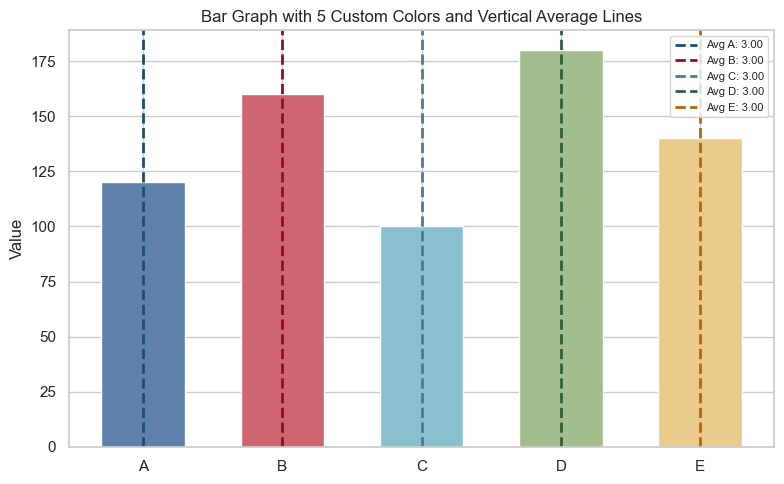

In [19]:
#Just testing to see if I like the colours. 
categories = ['A', 'B', 'C', 'D', 'E']
values = [120, 160, 100, 180, 140]
averages = [3, 3, 3, 3, 3]
x = np.arange(len(categories))
bar_width = 0.6
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(x, values, color=['#5E81AC',"#CF6570", '#88C0D0', '#A3BE8C', '#EBCB8B' ], width=bar_width)
for i, avg in enumerate(averages):
    ax.axvline(x=i + (avg - 3) * 0.12,  # shift within bar based on average (scaling)
               color=line_colors5[i], linestyle='--', linewidth=2,
               label=f"Avg {categories[i]}: {avg:.2f}")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Value")
ax.set_title("Bar Graph with 5 Custom Colors and Vertical Average Lines")
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

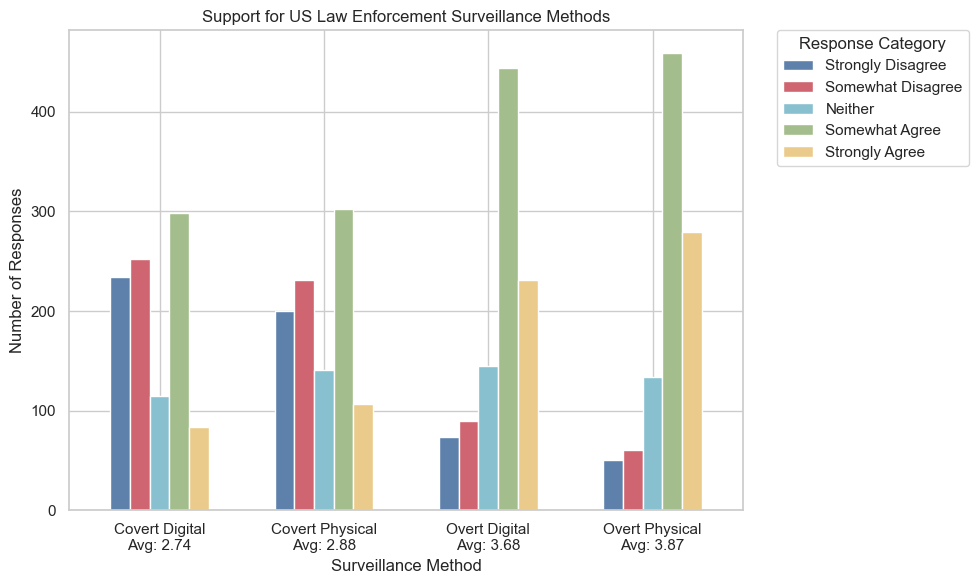

In [20]:
# Labels
columns = {
    'Q1_1': 'Covert Digital',
    'Q1_2': 'Covert Physical',
    'Q1_3': 'Overt Digital',
    'Q1_4': 'Overt Physical'
}

response_labels = ['Strongly Disagree', 'Somewhat Disagree', 'Neither', 'Somewhat Agree', 'Strongly Agree']
response_values = [1, 2, 3, 4, 5]

# calc avgs
data = {label: [] for label in response_labels}
averages = []

for col in columns:
    counts = df_included[col].value_counts().sort_index()
    counts = counts.reindex(response_values, fill_value=0)
    for i, label in enumerate(response_labels):
        data[label].append(counts[i + 1])
    
    # Calculate average
    total = counts.sum()
    avg = sum(counts[val] * val for val in response_values) / total if total > 0 else None
    averages.append(avg)

# labels
labels_with_avg = [
    f"{label}\nAvg: {avg:.2f}" if avg is not None else label
    for label, avg in zip(columns.values(), averages)
]

df_plot = pd.DataFrame(data, index=columns.values())

# Plot
ax = df_plot.plot(kind='bar', figsize=(10, 6), width=0.6, color=bar_colors5)
ax.set_title("Support for US Law Enforcement Surveillance Methods")
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Surveillance Method")
# Move the legend
ax.legend(
    title="Response Category",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.
)

ax.set_xticklabels(labels_with_avg, rotation=0)

plt.tight_layout()
plt.show()


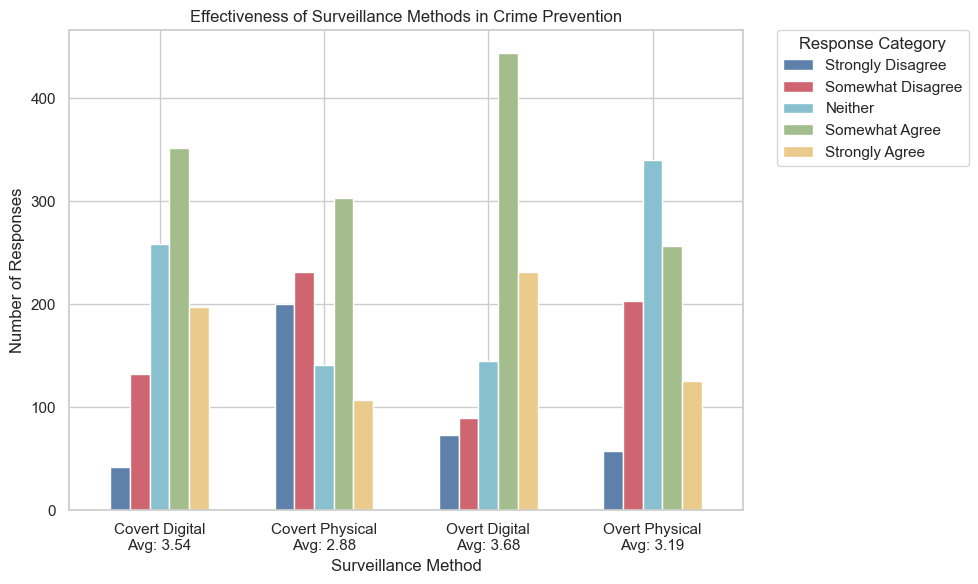

In [21]:
# Define labels
columns = {
    'Q2_1': 'Covert Digital',
    'Q1_2': 'Covert Physical',
    'Q1_3': 'Overt Digital',
    'Q2_4': 'Overt Physical'
}

response_labels = ['Strongly Disagree', 'Somewhat Disagree', 'Neither', 'Somewhat Agree', 'Strongly Agree']
response_values = [1, 2, 3, 4, 5]

# Calculate averagers
data = {label: [] for label in response_labels}
averages = []

for col in columns:
    counts = df_included[col].value_counts().sort_index()
    counts = counts.reindex(response_values, fill_value=0)
    for i, label in enumerate(response_labels):
        data[label].append(counts[i + 1])
    
    # Calculate average
    total = counts.sum()
    avg = sum(counts[val] * val for val in response_values) / total if total > 0 else None
    averages.append(avg)

# x-tick labels
labels_with_avg = [
    f"{label}\nAvg: {avg:.2f}" if avg is not None else label
    for label, avg in zip(columns.values(), averages)
]
df_plot = pd.DataFrame(data, index=columns.values())

# Plot
ax = df_plot.plot(kind='bar', figsize=(10, 6), width=0.6, color=bar_colors5)
ax.set_title("Effectiveness of Surveillance Methods in Crime Prevention")
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Surveillance Method")
# Move the legend outside the plot
ax.legend(
    title="Response Category",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.
)

# Set custom x-tick labels with line break and average
ax.set_xticklabels(labels_with_avg, rotation=0)

plt.tight_layout()
plt.show()


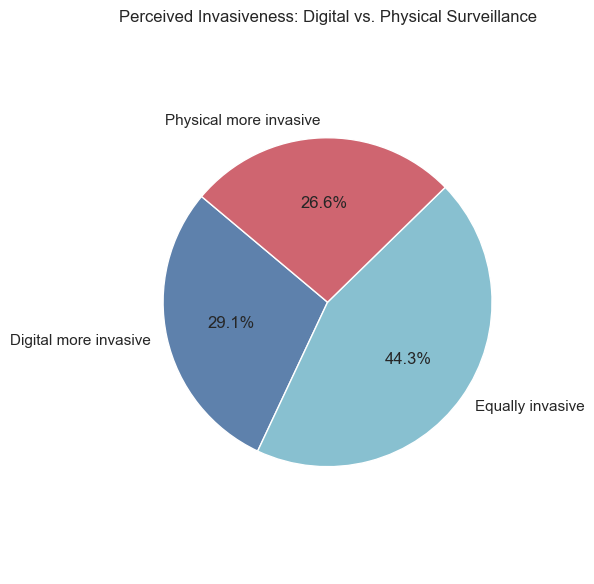

In [22]:
# Define response labels
invasiveness_labels = {
    1: "Digital more invasive",
    2: "Equally invasive",
    3: "Physical more invasive"
}

# Count and relabel responses
counts = df_included["Invasiveness_Merged"].value_counts().sort_index()
labels = [invasiveness_labels[val] for val in counts.index]

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(counts.values, labels=labels, autopct='%1.1f%%', startangle=140, colors=[colordigital, colorneutral ,colorphysical])
plt.title("Perceived Invasiveness: Digital vs. Physical Surveillance")
plt.axis('equal')  # Equal aspect ratio ensures pie is a circle
plt.tight_layout()
plt.show()


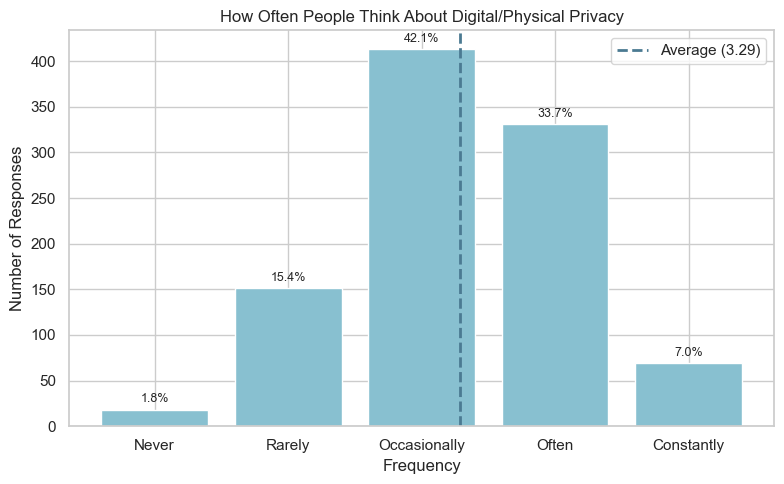

In [23]:
# Define labels for Q157
privacy_thinking_labels = {
    1: "Never",
    2: "Rarely",
    3: "Occasionally",
    4: "Often",
    5: "Constantly"
}

# Count and label the responses
counts = df_included["Q157"].value_counts().sort_index()
counts.index = [privacy_thinking_labels[val] for val in counts.index]

# Compute average and percentages
average_q157 = df_included["Q157"].mean()
avg_position = average_q157 - 1  # for axvline placement
total_responses = counts.sum()
percentages = (counts / total_responses) * 100

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values, color=colorneutral)

# Add percentage labels above bars
for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    plt.text(i, count + 5, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

# Add vertical average line
plt.axvline(x=avg_position, color=lineneutral, linestyle='--', linewidth=2, label=f'Average ({average_q157:.2f})')

plt.title("How Often People Think About Digital/Physical Privacy")
plt.xlabel("Frequency")
plt.ylabel("Number of Responses")
plt.legend()
plt.tight_layout()
plt.show()


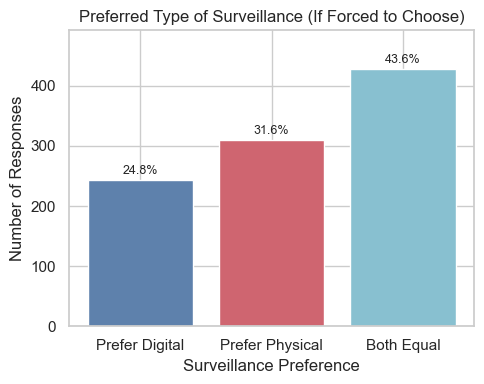

In [24]:
# Define labels for Q8
surveillance_preference_labels = {
    1: "Prefer Digital",
    2: "Prefer Physical",
    3: "Both Equal"
}

# Count and label the responses
counts = df_included["Q8"].value_counts().sort_index()
counts.index = [surveillance_preference_labels[val] for val in counts.index]

# Calculate percentages
total_responses = counts.sum()
percentages = (counts / total_responses) * 100

# Plot
plt.figure(figsize=(5, 4))
bars = plt.bar(counts.index, counts.values, color=[colordigital, colorphysical, colorneutral])

# Add percentage labels
for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    plt.text(i, count + 5, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

# Increase y-axis limit slightly
plt.ylim(0, max(counts.values) * 1.15)

plt.title("Preferred Type of Surveillance (If Forced to Choose)")
plt.ylabel("Number of Responses")
plt.xlabel("Surveillance Preference")
plt.tight_layout()
plt.show()



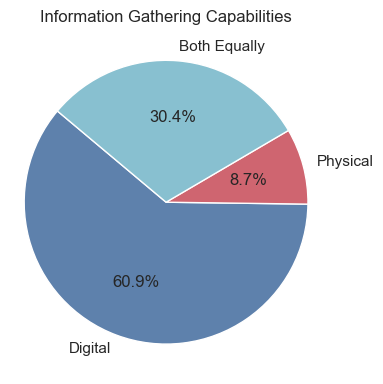

In [25]:
# Define labels for Q9
info_gathering_labels = {
    2: "Digital",
    1: "Physical",
    3: "Both Equally"
}

# Count and label the responses
counts = df_included["Q9"].value_counts().reindex([2, 1, 3])
counts.index = [info_gathering_labels[val] for val in counts.index]

# Plot as pie chart
plt.figure(figsize=(4, 4))
plt.pie(counts.values, labels=counts.index, colors=[colordigital, colorphysical, colorneutral],
        autopct='%1.1f%%', startangle=140)
plt.title("Information Gathering Capabilities")
plt.axis('equal')  # Keep the pie circular
plt.tight_layout()
plt.show()



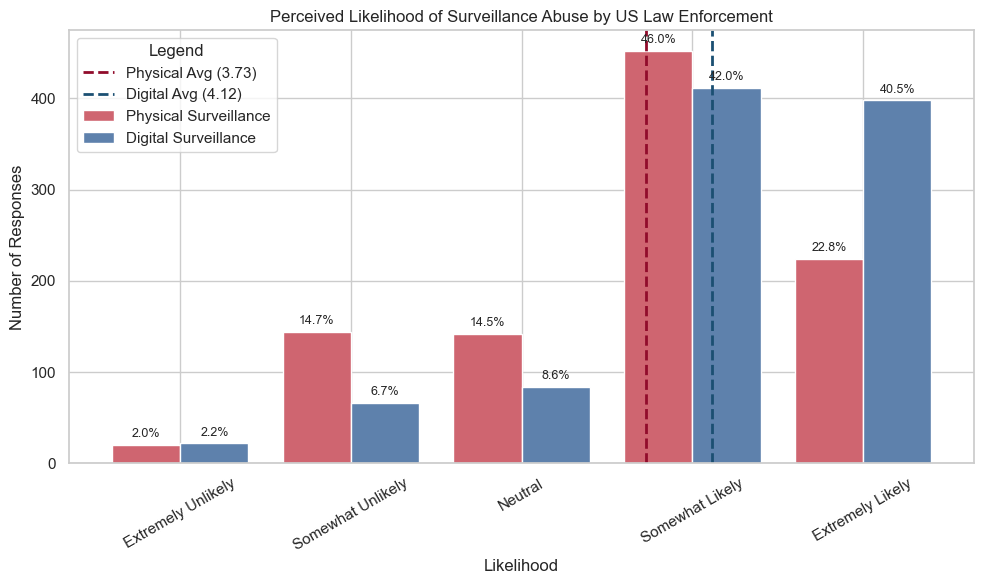

In [26]:
# Define response labels and corresponding order
abuse_likelihood_labels = {
    1: "Extremely Unlikely",
    2: "Somewhat Unlikely",
    3: "Neutral",
    4: "Somewhat Likely",
    5: "Extremely Likely"
}

response_order = [1, 2, 3, 4, 5]
x_labels = [abuse_likelihood_labels[i] for i in response_order]

# Count and reindex
q10_counts = df_included["Q10"].value_counts().sort_index().reindex(response_order, fill_value=0)
q11_counts = df_included["Q11"].value_counts().sort_index().reindex(response_order, fill_value=0)

# Create DataFrame for grouped bar chart
df_abuse = pd.DataFrame({
    "Physical Surveillance": q10_counts.values,
    "Digital Surveillance": q11_counts.values
}, index=x_labels)

# Calculate means
avg_q10 = df_included["Q10"].mean()
avg_q11 = df_included["Q11"].mean()

# Plot bar chart
colors = [colorphysical, colordigital]
colors2 = [linephysical, linedigital]
ax = df_abuse.plot(kind='bar', figsize=(10, 6), width=0.8, color=colors)
ax.set_title("Perceived Likelihood of Surveillance Abuse by US Law Enforcement")
ax.set_xlabel("Likelihood")
ax.set_ylabel("Number of Responses")
plt.xticks(rotation=30)

# Add percentage labels above bars
total_q10 = q10_counts.sum()
total_q11 = q11_counts.sum()
for i, (val1, val2) in enumerate(zip(q10_counts.values, q11_counts.values)):
    # X coordinates match bar center positions for grouped bars
    ax.text(i - 0.2, val1 + 5, f"{(val1/total_q10)*100:.1f}%", ha='center', va='bottom', fontsize=9)
    ax.text(i + 0.2, val2 + 5, f"{(val2/total_q11)*100:.1f}%", ha='center', va='bottom', fontsize=9)

# Add vertical mean lines
ax.axvline(x=avg_q10 - 1, color=colors2[0], linestyle='--', linewidth=2, label=f'Physical Avg ({avg_q10:.2f})')
ax.axvline(x=avg_q11 - 1, color=colors2[1], linestyle='--', linewidth=2, label=f'Digital Avg ({avg_q11:.2f})')

# Adjust y-axis limit for label space
#ax.set_ylim(0, max(df_abuse.max()) * 1.15)

# Clean up
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), title="Legend")

plt.tight_layout()
plt.show()


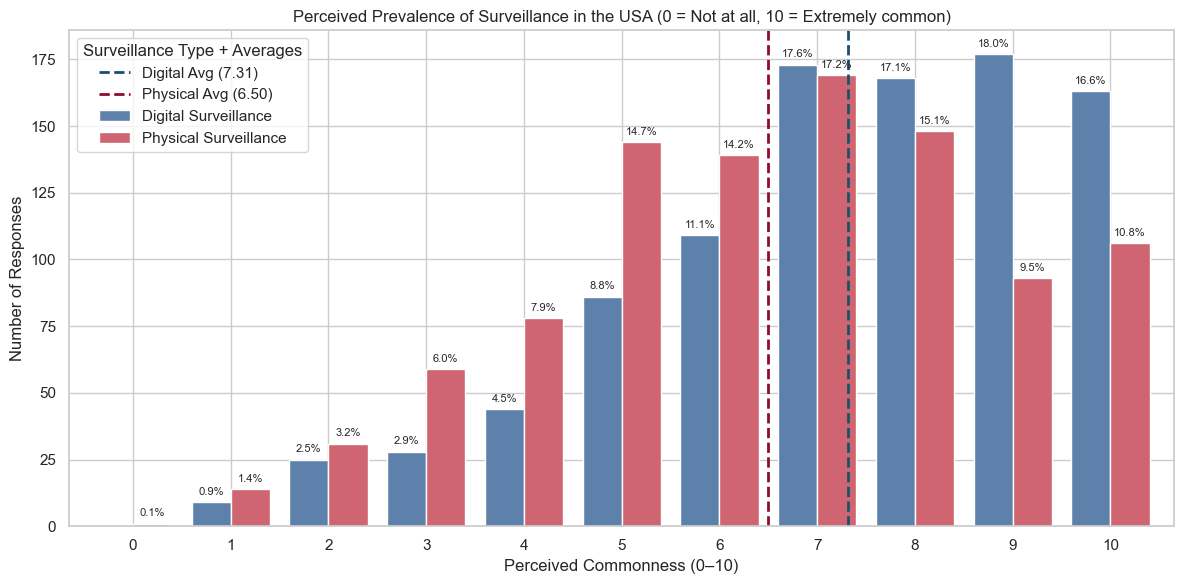

In [27]:
# Define 0–10 scale bins
bins = list(range(11))

# Count responses
digital_counts = df_included["Q153_1"].value_counts().sort_index().reindex(bins, fill_value=0)
physical_counts = df_included["Q153_2"].value_counts().sort_index().reindex(bins, fill_value=0)

# Combine into DataFrame
df_q153 = pd.DataFrame({
    "Digital Surveillance": digital_counts,
    "Physical Surveillance": physical_counts
}, index=bins)

# Calculate averages
avg_digital = df_included["Q153_1"].mean()
avg_physical = df_included["Q153_2"].mean()

# Plot bar chart
ax = df_q153.plot(kind='bar', figsize=(12, 6), width=0.8, color=[colordigital, colorphysical])
ax.set_title("Perceived Prevalence of Surveillance in the USA (0 = Not at all, 10 = Extremely common)")
ax.set_xlabel("Perceived Commonness (0–10)")
ax.set_ylabel("Number of Responses")
ax.legend(title="Surveillance Type")
plt.xticks(rotation=0)

# Add percentage labels above bars
total_digital = digital_counts.sum()
total_physical = physical_counts.sum()

for i, (d_val, p_val) in enumerate(zip(digital_counts.values, physical_counts.values)):
    if d_val > 0:
        ax.text(i - 0.2, d_val + 2, f"{(d_val / total_digital) * 100:.1f}%", ha='center', va='bottom', fontsize=8)
    if p_val > 0:
        ax.text(i + 0.2, p_val + 2, f"{(p_val / total_physical) * 100:.1f}%", ha='center', va='bottom', fontsize=8)

# Increase y-axis limit slightly
#ax.set_ylim(0, df_q153.max().max() * 1.15)

# Add vertical lines for averages
ax.axvline(avg_digital, color=colors2[1], linestyle='--', linewidth=2, label=f'Digital Avg ({avg_digital:.2f})')
ax.axvline(avg_physical, color=colors2[0], linestyle='--', linewidth=2, label=f'Physical Avg ({avg_physical:.2f})')

# Fix legend
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), title="Surveillance Type + Averages")

plt.tight_layout()
plt.show()


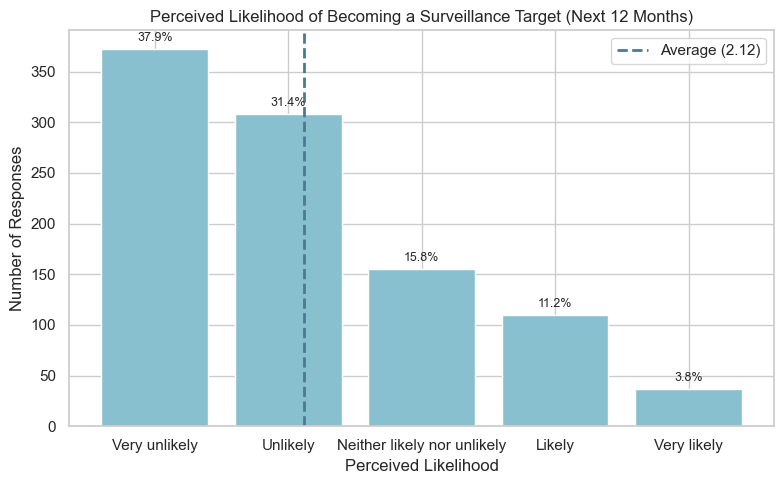

In [28]:
# Labels
q135_labels = {
    1: "Very unlikely",
    2: "Unlikely",
    3: "Neither likely nor unlikely",
    4: "Likely",
    5: "Very likely"
}

# Count and reindex
counts = df_included["Q135"].value_counts().sort_index()
counts.index = [q135_labels[val] for val in counts.index]

# Calculate average and convert to 0-based index for positioning
average_q135 = df_included["Q135"].mean()
avg_position = average_q135 - 1

# Calculate percentages
total_responses = counts.sum()
percentages = (counts / total_responses) * 100

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values, color=colorneutral)

# Add percentage labels above bars
for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    plt.text(i, count + 5, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

# Add average line
plt.axvline(x=avg_position, color=lineneutral, linestyle='--', linewidth=2, label=f'Average ({average_q135:.2f})')

# Formatting stuff
plt.title("Perceived Likelihood of Becoming a Surveillance Target (Next 12 Months)")
plt.xlabel("Perceived Likelihood")
plt.ylabel("Number of Responses")
plt.ylim(0, counts.max() * 1.05)
plt.legend()
plt.tight_layout()
plt.show()


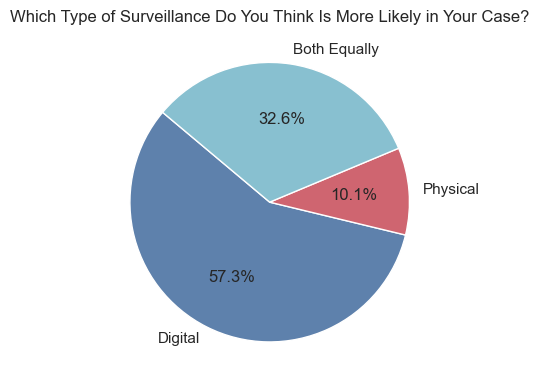

In [29]:
# Define response labels
q160_labels = {
    1: "Digital",
    2: "Physical",
    3: "Both Equally"
}

# Count and relabel
counts = df_included["Q160"].value_counts().reindex([1, 2, 3])
labels = [q160_labels[val] for val in counts.index]
colors = [colordigital, colorphysical, colorneutral]

# Plot pie chart
plt.figure(figsize=(4, 4))
plt.pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title("Which Type of Surveillance Do You Think Is More Likely in Your Case?")
plt.axis('equal')  # Keep pie chart circular woop woop
plt.tight_layout()
plt.show()


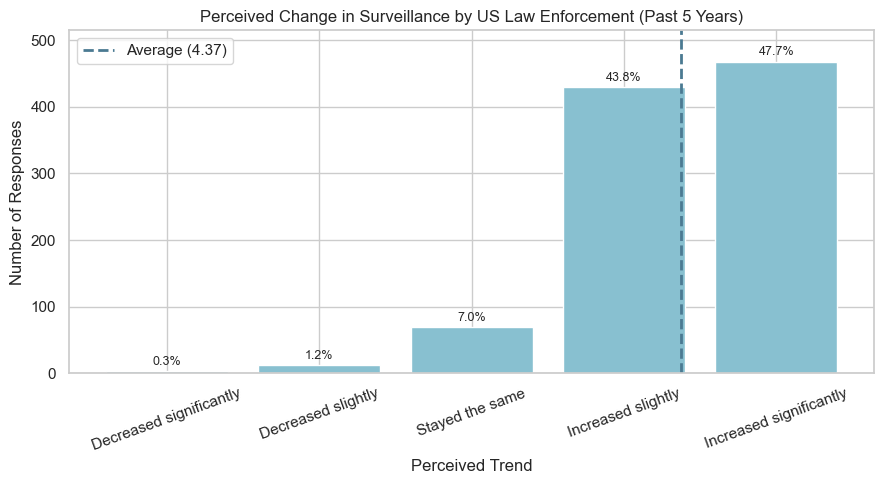

In [30]:
# Define labels for Q151
q151_labels = {
    1: "Decreased significantly",
    2: "Decreased slightly",
    3: "Stayed the same",
    4: "Increased slightly",
    5: "Increased significantly"
}

# Count responses and relabel
counts = df_included["Q151"].value_counts().sort_index()
counts.index = [q151_labels[val] for val in counts.index]

# Calculate average and align to bar positions
average_q151 = df_included["Q151"].mean()
avg_position = average_q151 - 1

# Calculate percentages
total_responses = counts.sum()
percentages = (counts / total_responses) * 100

# Plot
plt.figure(figsize=(9, 5))
bars = plt.bar(counts.index, counts.values, color=colorneutral)

# Add percentage labels above bars
for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    plt.text(i, count + 5, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

# Add average line
plt.axvline(x=avg_position, color=lineneutral, linestyle='--', linewidth=2, label=f'Average ({average_q151:.2f})')

# Formatting
plt.title("Perceived Change in Surveillance by US Law Enforcement (Past 5 Years)")
plt.xlabel("Perceived Trend")
plt.ylabel("Number of Responses")
plt.xticks(rotation=20)
plt.ylim(0, counts.max() * 1.1)
plt.legend()
plt.tight_layout()
plt.show()



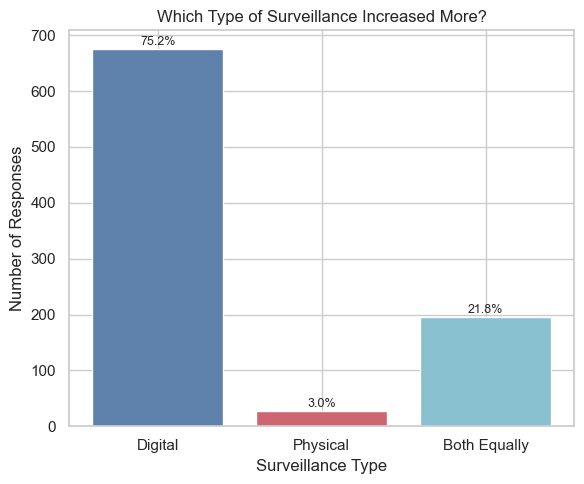

In [31]:
# Labels
q161_labels = {
    1: "Digital",
    2: "Physical",
    3: "Both Equally"
}

# Count and relabel
counts = df_included["Q161"].value_counts().reindex([1, 2, 3])
counts.index = [q161_labels[val] for val in counts.index]

# Calculate percentages
total = counts.sum()
percentages = (counts / total) * 100

# Plot
plt.figure(figsize=(6, 5))
bars = plt.bar(counts.index, counts.values, color=[colordigital, colorphysical, colorneutral])

# Add percentage labels above bars
for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    plt.text(i, count + 2, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

# Formatting
plt.title("Which Type of Surveillance Increased More?")
plt.xlabel("Surveillance Type")
plt.ylabel("Number of Responses")
#plt.ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()


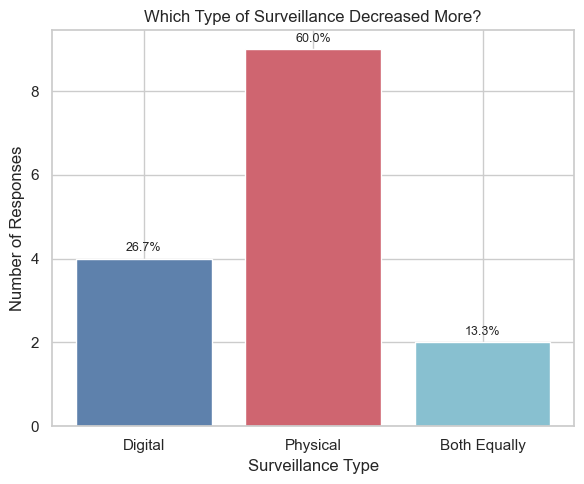

In [32]:
# Labels
q171_labels = {
    1: "Digital",
    2: "Physical",
    3: "Both Equally"
}

# Count and relabel
counts = df_included["Q171"].value_counts().reindex([1, 2, 3])
counts.index = [q171_labels[val] for val in counts.index]

# Calculate percentages
total = counts.sum()
percentages = (counts / total) * 100

# Plot
plt.figure(figsize=(6, 5))
bars = plt.bar(counts.index, counts.values, color=[colordigital, colorphysical, colorneutral])

# Add percentage labels closer to the bars
for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    plt.text(i, count + 0.1, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

# Formatting
plt.title("Which Type of Surveillance Decreased More?")
plt.xlabel("Surveillance Type")
plt.ylabel("Number of Responses")
#plt.ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()



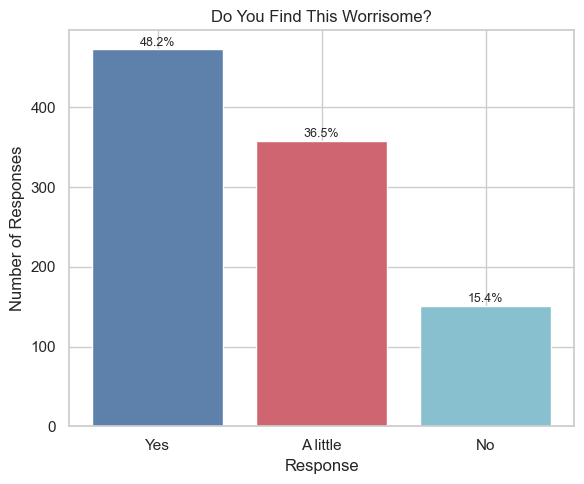

In [33]:
# Labels
q152_labels = {
    1: "Yes",
    2: "A little",
    3: "No"
}

# Count and relabel responses
counts = df_included["Q152"].value_counts().reindex([1, 2, 3])
counts.index = [q152_labels[val] for val in counts.index]

# Calculate percentages
total = counts.sum()
percentages = (counts / total) * 100

# Plot
plt.figure(figsize=(6, 5))
bars = plt.bar(counts.index, counts.values, color=bar_colors3)

# Add percentage labels just above each bar
for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    plt.text(i, count + 0.5, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

# Formatting
plt.title("Do You Find This Worrisome?")
plt.xlabel("Response")
plt.ylabel("Number of Responses")
#plt.ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()


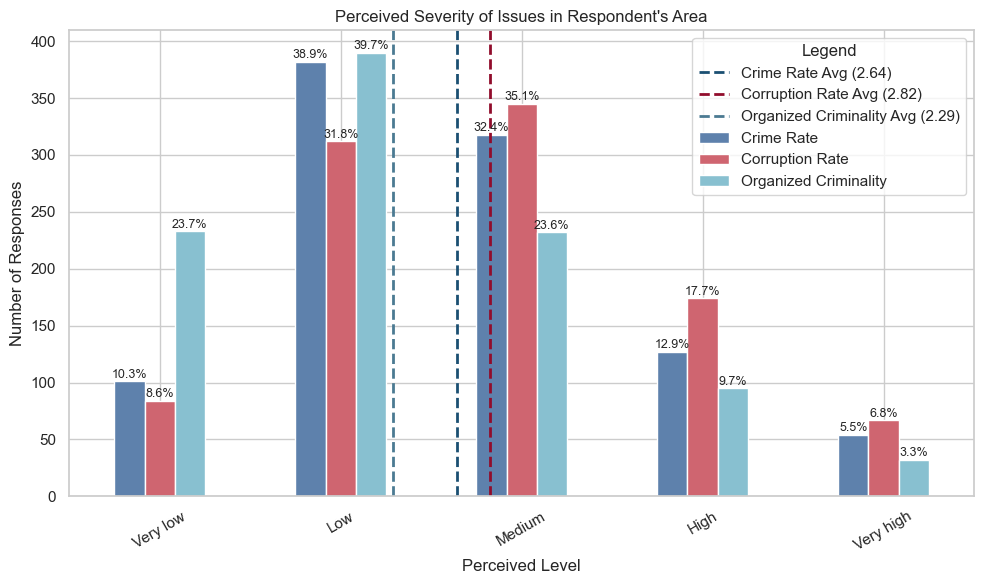

In [34]:
# Labels
response_labels = {
    1: "Very low",
    2: "Low",
    3: "Medium",
    4: "High",
    5: "Very high"
}

q14_columns = {
    "Q14_1": "Crime Rate",
    "Q14_2": "Corruption Rate",
    "Q14_3": "Organized Criminality"
}

# Prepare data
data = {}
averages = {}
percentages = {}

for col, label in q14_columns.items():
    counts = df_included[col].value_counts().sort_index().reindex(range(1, 6), fill_value=0)
    data[label] = counts.values
    percentages[label] = (counts / counts.sum() * 100).round(1).values
    averages[label] = df_included[col].mean()

# Convert to DataFrame
df_q14 = pd.DataFrame(data, index=[response_labels[i] for i in range(1, 6)])
df_pct = pd.DataFrame(percentages, index=[response_labels[i] for i in range(1, 6)])

# Define bar colors
colors = {
    "Crime Rate": colordigital,
    "Corruption Rate": colorphysical,
    "Organized Criminality": colorneutral
}

colors2 = {
    "Crime Rate": linedigital,
    "Corruption Rate": linephysical,
    "Organized Criminality": lineneutral
}

# Plot
ax = df_q14.plot(kind='bar', figsize=(10, 6), color=[colors[col] for col in df_q14.columns])
ax.set_title("Perceived Severity of Issues in Respondent's Area")
ax.set_xlabel("Perceived Level")
ax.set_ylabel("Number of Responses")
plt.xticks(rotation=30)

# Add percentage labels above each bar
for bars, col in zip(ax.containers, df_q14.columns):
    for bar, pct in zip(bars, df_pct[col].values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f"{pct:.1f}%", 
                ha='center', va='bottom', fontsize=9)

# Add average lines
for i, col in enumerate(df_q14.columns):
    avg_val = averages[col] - 1  # map to x-position
    ax.axvline(x=avg_val, color=colors2[col], linestyle='--', linewidth=2, label=f'{col} Avg ({averages[col]:.2f})')

# Clean up time.
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), title="Legend")

plt.tight_layout()
plt.show()


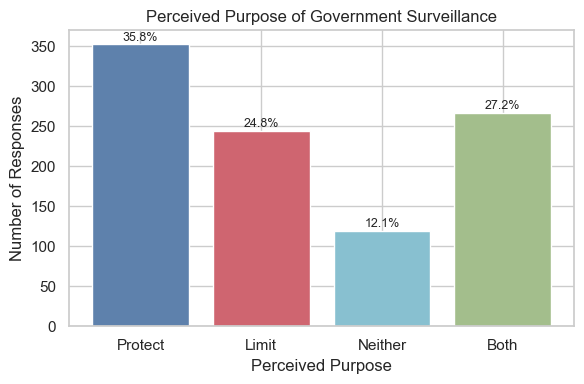

In [35]:
# Labels
label_map = {
    1: 'Protect',
    2: 'Limit',
    3: 'Neither',
    4: 'Both'
}
response_order = [1, 2, 3, 4]
response_labels = [label_map[i] for i in response_order]

# Count and reindex
counts = df_included['Q138'].value_counts().reindex(response_order, fill_value=0)
percentages = (counts / counts.sum() * 100).round(1)

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(response_labels, counts.values, color=bar_colors4)

# Title and axes
ax.set_title("Perceived Purpose of Government Surveillance")
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Perceived Purpose")

# Add percentage labels only
for i, pct in enumerate(percentages.values):
    ax.text(i, counts.values[i] + 1, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


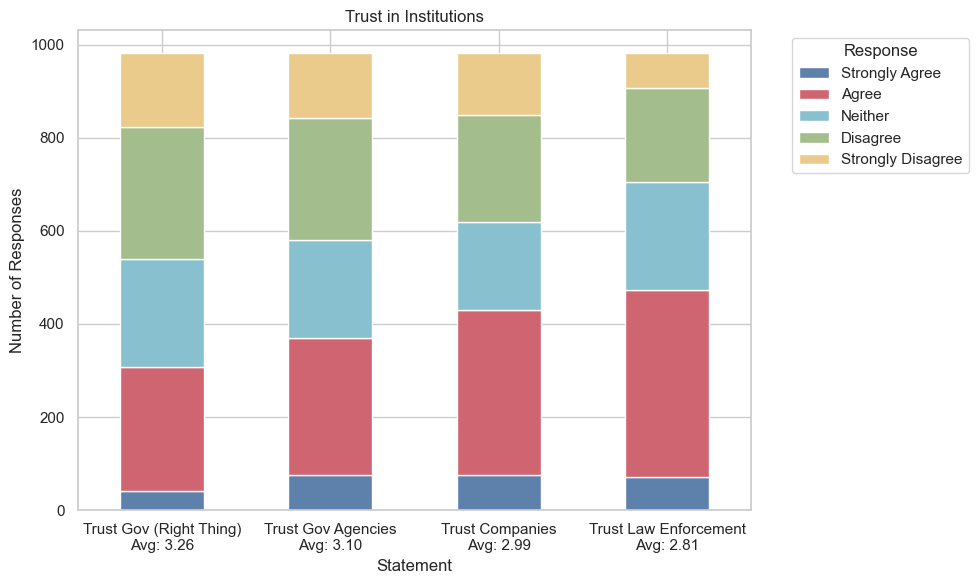

In [36]:
# Labels and mapping
questions = {
    'Q15': 'Trust Gov (Right Thing)',
    'Q16': 'Trust Gov Agencies',
    'Q17': 'Trust Companies',
    'Q18': 'Trust Law Enforcement'
}

response_values = [1, 2, 3, 4, 5]
response_labels = [
    'Strongly Agree', 'Agree',
    'Neither', 'Disagree', 'Strongly Disagree'
]

# Prepare data
data = {label: [] for label in response_labels}
averages = []

for q in questions:
    counts = df_included[q].value_counts().sort_index()
    counts = counts.reindex(response_values, fill_value=0)

    for i, label in enumerate(response_labels):
        data[label].append(counts[i + 1])
    
    total = counts.sum()
    avg = sum(counts[val] * val for val in response_values) / total if total > 0 else None
    averages.append(avg)

# Create DataFrame for plotting
df_plot = pd.DataFrame(data, index=questions.values())

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
df_plot.plot(kind='bar', stacked=True, ax=ax, color=bar_colors5)

# x labels include average underneath
xtick_labels = [
    f"{label}\nAvg: {avg:.2f}" if avg is not None else label
    for label, avg in zip(questions.values(), averages)
]
ax.set_xticks(range(len(xtick_labels)))
ax.set_xticklabels(xtick_labels, rotation=0)

# Formatting
ax.set_title("Trust in Institutions")
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Statement")
ax.legend(title="Response", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [37]:
# Calculate percentage of participants who agreed or strongly agreed (responses 1 or 2)
agreement_percentages = {}

for q, label in questions.items():
    counts = df_included[q].value_counts()
    total_responses = counts.sum()
    agree_count = counts.get(1, 0) + counts.get(2, 0)
    
    percentage = (agree_count / total_responses) * 100 if total_responses > 0 else 0
    agreement_percentages[label] = percentage

# Display the results
for label, pct in agreement_percentages.items():
    print(f"{label}: {pct:.1f}% agreed or strongly agreed")



Trust Gov (Right Thing): 31.4% agreed or strongly agreed
Trust Gov Agencies: 37.7% agreed or strongly agreed
Trust Companies: 43.8% agreed or strongly agreed
Trust Law Enforcement: 48.1% agreed or strongly agreed


In [38]:
#Comparison to Geierhaas 2025 CSS
# Sample sizes
n_maedler = len(df_included)
n_geierhaas = 977

# My agreement counts
counts_maedler = {
    "Gov (Right Thing)": round(0.314 * n_maedler),
    "Gov Agencies": round(0.377 * n_maedler),
    "Companies": round(0.438 * n_maedler),
    "Law Enforcement": round(0.481 * n_maedler),
}

# Geierhaas agreement counts (rounded from percentages)
counts_geierhaas = {
    "Gov (Right Thing)": round(0.418 * n_geierhaas),
    "Gov Agencies": round(0.487 * n_geierhaas),
    "Companies": round(0.508 * n_geierhaas),
    "Law Enforcement": round(0.585 * n_geierhaas),
}

# Run two-sample z-tests
for label in counts_maedler:
    count = np.array([counts_maedler[label], counts_geierhaas[label]])
    nobs = np.array([n_maedler, n_geierhaas])
    
    stat, pval = proportions_ztest(count, nobs, alternative='two-sided')
    
    print(f"{label}: z = {stat:.2f}, p = {pval:.4f}")



Gov (Right Thing): z = -4.78, p = 0.0000
Gov Agencies: z = -4.93, p = 0.0000
Companies: z = -3.09, p = 0.0020
Law Enforcement: z = -4.65, p = 0.0000


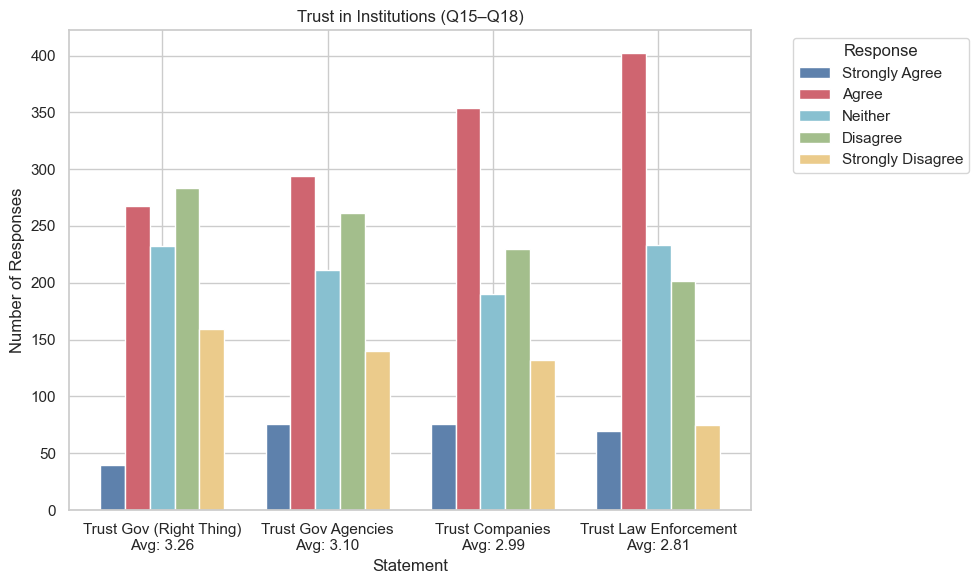

In [39]:
# Question mapping
questions = {
    'Q15': 'Trust Gov (Right Thing)',
    'Q16': 'Trust Gov Agencies',
    'Q17': 'Trust Companies',
    'Q18': 'Trust Law Enforcement'
}

response_values = [1, 2, 3, 4, 5]
response_labels = [
    'Strongly Agree', 'Agree',
    'Neither', 'Disagree', 'Strongly Disagree'
]

# Prepare data
data = {q: [] for q in questions}
averages = []

for q in questions:
    counts = df_included[q].value_counts().sort_index()
    counts = counts.reindex(response_values, fill_value=0)
    data[q] = list(counts.values)

    # Compute average
    total = counts.sum()
    avg = sum(counts[val] * val for val in response_values) / total if total > 0 else None
    averages.append(avg)

# Create DataFrame
df_plot = pd.DataFrame(data, index=response_labels)

# Bar positioning
x = np.arange(len(questions))  # one per question
bar_width = 0.15
offsets = np.linspace(-2, 2, 5) * bar_width

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for i, (label, color) in enumerate(zip(response_labels, bar_colors5)):
    positions = x + offsets[i]
    heights = df_plot.iloc[i].values
    ax.bar(positions, heights, width=bar_width, color=color, label=label)

# x label with aerages
xtick_labels = [
    f"{label}\nAvg: {avg:.2f}" if avg is not None else label
    for label, avg in zip(questions.values(), averages)
]
ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, rotation=0)

# Labels and layout
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Statement")
ax.set_title("Trust in Institutions (Q15–Q18)")
ax.legend(title="Response", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


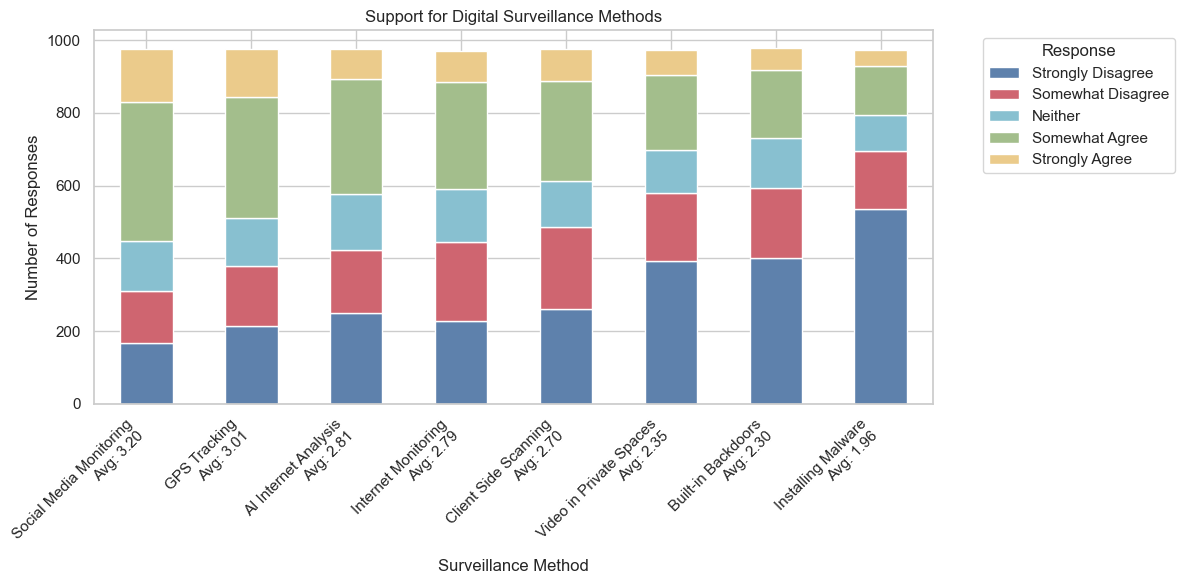

In [40]:
# Labels
digital_methods = {
    'Q169_1': 'Built-in Backdoors',
    'Q169_2': 'GPS Tracking',
    'Q169_3': 'Internet Monitoring',
    'Q169_4': 'Video in Private Spaces',
    'Q169_5': 'Installing Malware',
    'Q169_6': 'Social Media Monitoring',
    'Q169_7': 'AI Internet Analysis',
    'Q169_8': 'Client Side Scanning'
}

response_values = [1, 2, 3, 4, 5]
response_labels = [
    'Strongly Disagree', 'Somewhat Disagree', 'Neither', 'Somewhat Agree', 'Strongly Agree'
]

# Prepare data and compute averages
data = {label: [] for label in response_labels}
averages_methods1 = []

for q in digital_methods:
    counts = df_included[q].value_counts().sort_index()
    counts = counts.reindex(response_values, fill_value=0)

    for i, label in enumerate(response_labels):
        data[label].append(counts[i + 1])

    total = counts.sum()
    avg = sum(counts[val] * val for val in response_values) / total if total > 0 else None
    averages_methods1.append(avg)

# Sort by average values (descending)
methods = list(digital_methods.values())
sorted_data = sorted(zip(methods, averages_methods1, zip(*data.values())), key=lambda x: x[1], reverse=True)
sorted_methods, sorted_averages, sorted_counts = zip(*sorted_data)

# Update data dict with sorted counts
sorted_data_dict = {label: list(col) for label, col in zip(response_labels, zip(*sorted_counts))}

# Create DataFrame for stacked bar plot
df_plot = pd.DataFrame(sorted_data_dict, index=sorted_methods)

# Plot stacked bars
fig, ax = plt.subplots(figsize=(12, 6))
df_plot.plot(kind='bar', stacked=True, color=bar_colors5, ax=ax)

# X-labels with averages
xtick_labels = [
    f"{label}\nAvg: {avg:.2f}" if avg is not None else label
    for label, avg in zip(sorted_methods, sorted_averages)
]
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

# Formatting
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Surveillance Method")
ax.set_title("Support for Digital Surveillance Methods")
ax.legend(title="Response", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


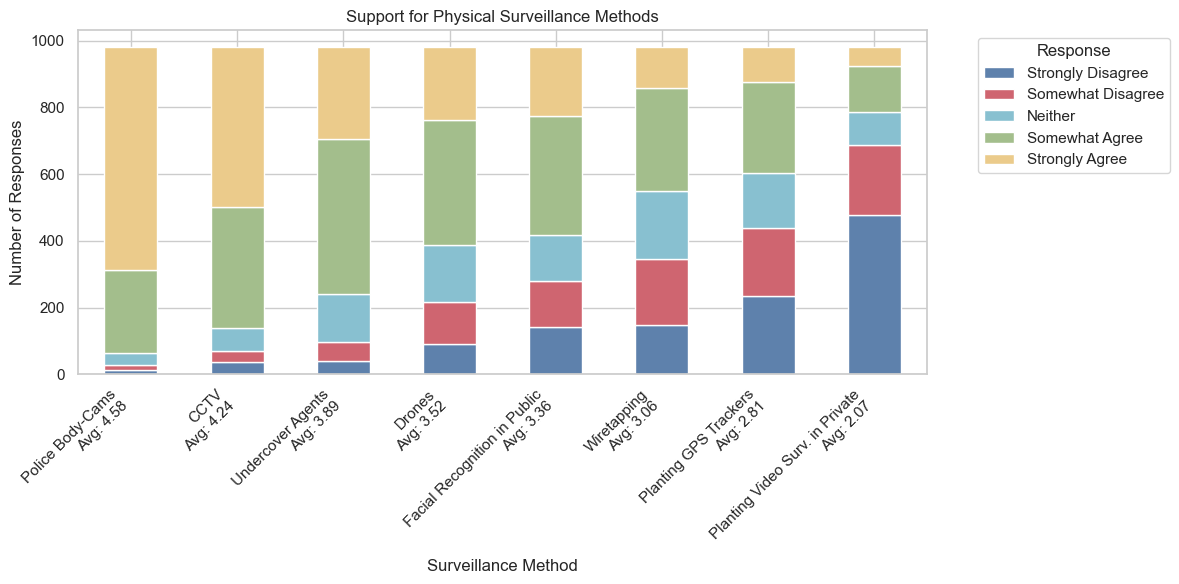

In [41]:
# Labels
physical_methods = {
    'Q164_1': 'Undercover Agents',
    'Q164_2': 'Wiretapping',
    'Q164_3': 'Planting Video Surv. in Private',
    'Q164_4': 'Planting GPS Trackers',
    'Q164_5': 'CCTV',
    'Q164_6': 'Facial Recognition in Public',
    'Q164_7': 'Police Body-Cams',
    'Q164_8': 'Drones'
}

response_values = [1, 2, 3, 4, 5]
response_labels = [
    'Strongly Disagree', 'Somewhat Disagree', 'Neither', 'Somewhat Agree', 'Strongly Agree'
]

# Prepare data and compute averages
data = {label: [] for label in response_labels}
averages_methods2 = []

for q in physical_methods:
    counts = df_included[q].value_counts().sort_index()
    counts = counts.reindex(response_values, fill_value=0)

    for i, label in enumerate(response_labels):
        data[label].append(counts[i + 1])

    total = counts.sum()
    avg = sum(counts[val] * val for val in response_values) / total if total > 0 else None
    averages_methods2.append(avg)

# Sort by average values (descending)
methods = list(physical_methods.values())
sorted_data = sorted(zip(methods, averages_methods2, zip(*data.values())), key=lambda x: x[1], reverse=True)
sorted_methods, sorted_averages, sorted_counts = zip(*sorted_data)

# Update data dict with sorted counts
sorted_data_dict = {label: list(col) for label, col in zip(response_labels, zip(*sorted_counts))}

# Create DataFrame for stacked bar plot
df_plot = pd.DataFrame(sorted_data_dict, index=sorted_methods)

# Plot stacked bars
fig, ax = plt.subplots(figsize=(12, 6))
df_plot.plot(kind='bar', stacked=True, color=bar_colors5, ax=ax)

# X-labels with averages
xtick_labels = [
    f"{label}\nAvg: {avg:.2f}" if avg is not None else label
    for label, avg in zip(sorted_methods, sorted_averages)
]
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

# Formatting
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Surveillance Method")
ax.set_title("Support for Physical Surveillance Methods")
ax.legend(title="Response", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


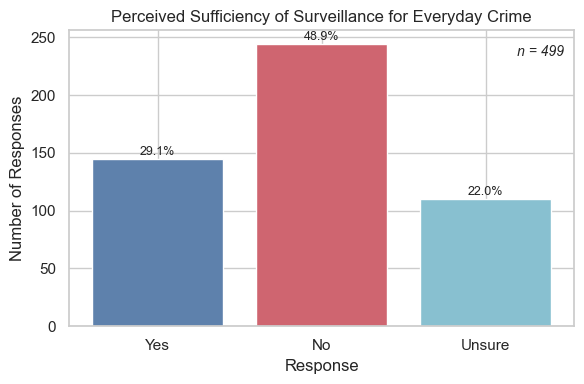

In [42]:
# Q145 mapping
response_map = {
    1: 'Yes',
    2: 'No',
    3: 'Unsure'
}
response_order = [1, 2, 3]
response_labels = [response_map[i] for i in response_order]

# Count responses
counts = df_included['Q145'].value_counts().reindex(response_order, fill_value=0)
percentages = (counts / counts.sum() * 100).round(1)
total_responses = counts.sum()

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(response_labels, counts.values, color=bar_colors3)

# Add percentage labels above bars
for i, pct in enumerate(percentages.values):
    ax.text(i, counts.values[i] + 1, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

# Add total response count in the top right corner
ax.text(0.98, 0.95, f"n = {total_responses}", transform=ax.transAxes,
        ha='right', va='top', fontsize=10, style='italic')

# Labels and formatting
ax.set_title("Perceived Sufficiency of Surveillance for Everyday Crime")
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Response")

plt.tight_layout()
plt.show()



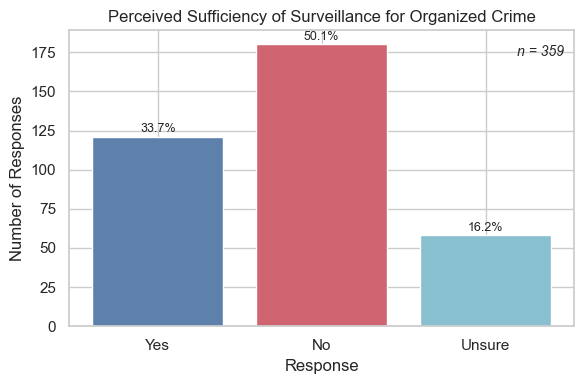

In [43]:
# Q147 mapping
response_map = {
    1: 'Yes',
    2: 'No',
    3: 'Unsure'
}
response_order = [1, 2, 3]
response_labels = [response_map[i] for i in response_order]

# Count responses
counts = df_included['Q147'].value_counts().reindex(response_order, fill_value=0)
percentages = (counts / counts.sum() * 100).round(1)
total_responses = counts.sum()

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(response_labels, counts.values, color=bar_colors3)

# Add percentage labels above bars
for i, pct in enumerate(percentages.values):
    ax.text(i, counts.values[i] + 1, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

# Add total response count in the top right corner
ax.text(0.98, 0.95, f"n = {total_responses}", transform=ax.transAxes,
        ha='right', va='top', fontsize=10, style='italic')

# Labels and formatting
ax.set_title("Perceived Sufficiency of Surveillance for Organized Crime")
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Response")

plt.tight_layout()
plt.show()


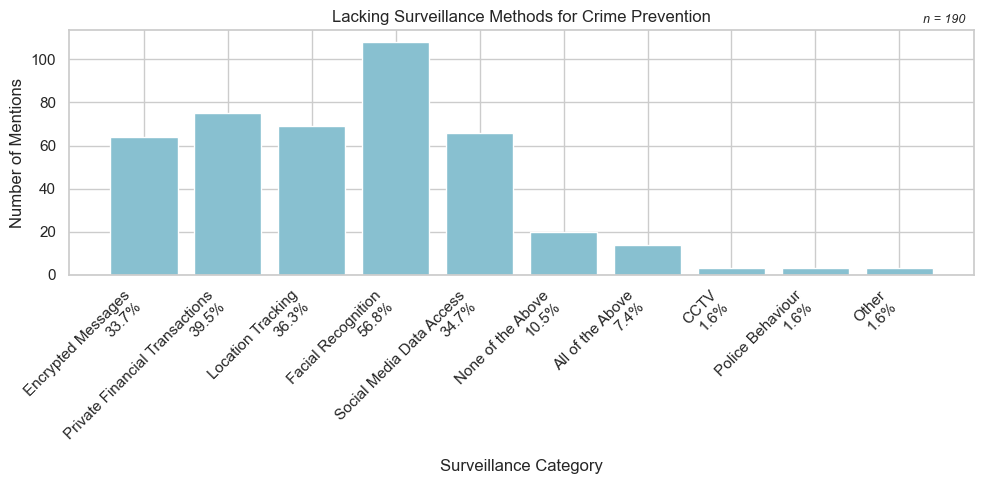

In [44]:
# Columns
q170_columns = [
    'Q170_1', 'Q170_2', 'Q170_3', 'Q170_4',
    'Q170_8', 'Q170_5', 'Q170_6', 'Q170_5_TEXT'
]

# Count participants with at least one non-null entry
n_participants_q170 = df_included[q170_columns].notna().any(axis=1).sum()

# Sort category keys
sorted_keys = sorted(category_counts.keys())
labels = [category_labels[k] for k in sorted_keys]
values = [category_counts[k] for k in sorted_keys]
percentages = [v / n_participants_q170 * 100 for v in values]

# Combine labels with percentages
xtick_labels = [f"{label}\n{pct:.1f}%" for label, pct in zip(labels, percentages)]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(xtick_labels, values, color=colorneutral)

# Labels and formatting
ax.set_title("Lacking Surveillance Methods for Crime Prevention")
ax.set_ylabel("Number of Mentions")
ax.set_xlabel("Surveillance Category")
ax.text(0.99, 1.02, f"n = {n_participants_q170}",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9, style='italic')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Asked to people who said yes to either of the two questions before

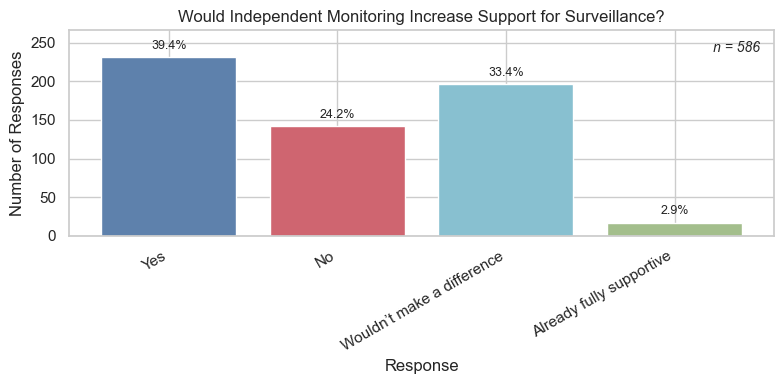

In [45]:
# Map numeric responses to labels
response_map = {
    1: 'Yes',
    2: 'No',
    3: 'Wouldn’t make a difference',
    6: 'Already fully supportive'
}
response_order = [1, 2, 3, 6]
response_labels = [response_map[i] for i in response_order]

# Count responses
counts = df_included['Q149'].value_counts().reindex(response_order, fill_value=0)
percentages = (counts / counts.sum() * 100).round(1)
total_responses = counts.sum()

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(response_labels, counts.values, color=bar_colors4)

# Add percentage labels above bars
for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    ax.text(i, count + max(counts.values) * 0.03, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

# Add total response count in top-right corner
ax.text(0.98, 0.95, f"n = {total_responses}", transform=ax.transAxes,
        ha='right', va='top', fontsize=10, style='italic')

# Formatting
ax.set_title("Would Independent Monitoring Increase Support for Surveillance?")
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Response")
plt.xticks(rotation=30, ha='right')

# Add extra space at the top
ax.set_ylim(top=max(counts.values) * 1.15)

plt.tight_layout()
plt.show()




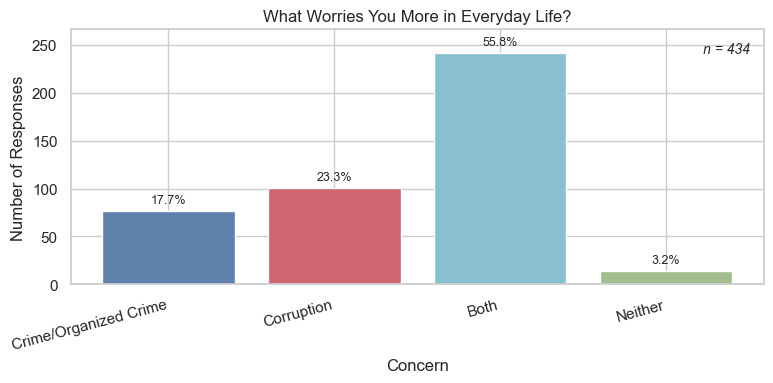

In [46]:
# Define mapping and response order
response_map = {
    1: 'Crime/Organized Crime',
    3: 'Corruption',
    6: 'Both',
    7: 'Neither'
}
response_order = [1, 3, 6, 7]
response_labels = [response_map[i] for i in response_order]

# Count responses and compute percentages
counts = df_included['Q150'].value_counts().reindex(response_order, fill_value=0)
percentages = (counts / counts.sum() * 100).round(1)
total_responses = counts.sum()

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(response_labels, counts.values, color=bar_colors4)

# Add percentage labels above bars
for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    ax.text(i, count + max(counts.values) * 0.02, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

# Show total response count in top-right corner
ax.text(0.98, 0.95, f"n = {total_responses}", transform=ax.transAxes,
        ha='right', va='top', fontsize=10, style='italic')

# Formatting
ax.set_title("What Worries You More in Everyday Life?")
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Concern")
plt.xticks(rotation=15, ha='right')
ax.set_ylim(top=max(counts.values) * 1.1)  # extra space at the top

plt.tight_layout()
plt.show()



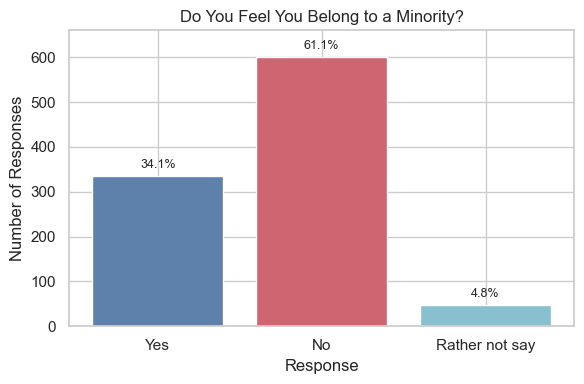

In [47]:
# Define response mapping and order
response_map = {
    1: 'Yes',
    2: 'No',
    3: 'Rather not say'
}
response_order = [1, 2, 3]
response_labels = [response_map[i] for i in response_order]

# Count responses and calculate percentages
counts = df_included['Q21.1'].value_counts().reindex(response_order, fill_value=0)
percentages = (counts / counts.sum() * 100).round(1)

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(response_labels, counts.values, color=bar_colors3)

# Add percentage labels above bars
for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    ax.text(i, count + max(counts.values) * 0.02, f"{pct}%", ha='center', va='bottom', fontsize=9)

# Formatting
ax.set_title("Do You Feel You Belong to a Minority?")
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Response")
ax.set_ylim(top=max(counts.values) * 1.1)  # add space for labels

plt.tight_layout()
plt.show()



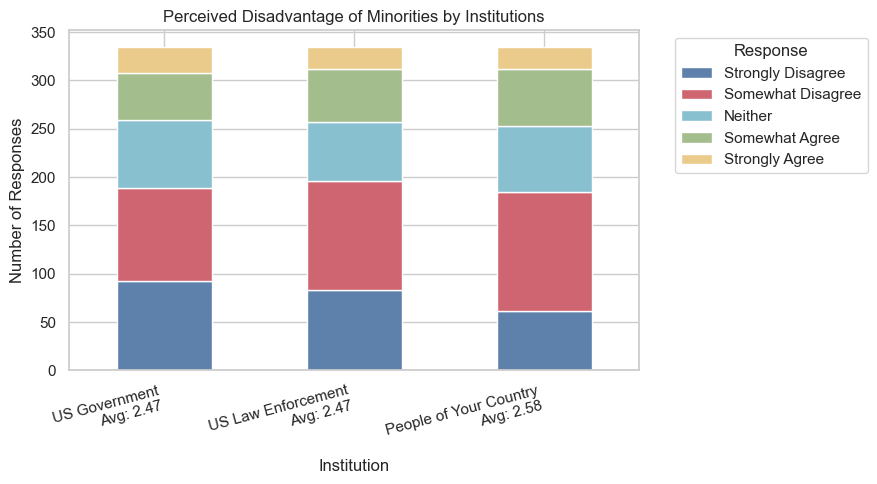

In [48]:
# mapping and labels 
disadvantage_questions = {
    'Q21.2_1': 'US Government',
    'Q21.2_2': 'US Law Enforcement',
    'Q21.2_3': 'People of Your Country'
}

response_values = [1, 2, 3, 4, 5]
response_labels = [
    'Strongly Disagree', 'Somewhat Disagree',
    'Neither', 'Somewhat Agree', 'Strongly Agree'
]

# Prepare data
data = {label: [] for label in response_labels}
averages = []

for q in disadvantage_questions:
    counts = df_included[q].value_counts().sort_index()
    counts = counts.reindex(response_values, fill_value=0)

    for i, label in enumerate(response_labels):
        data[label].append(counts[i + 1])

    total = counts.sum()
    avg = sum(counts[val] * val for val in response_values) / total if total > 0 else None
    averages.append(avg)

# DataFrame for plotting
df_plot = pd.DataFrame(data, index=disadvantage_questions.values())

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
df_plot.plot(kind='bar', stacked=True, color=bar_colors5, ax=ax)

# X-labels with average
xtick_labels = [
    f"{label}\nAvg: {avg:.2f}" if avg is not None else label
    for label, avg in zip(disadvantage_questions.values(), averages)
]
ax.set_xticks(range(len(xtick_labels)))
ax.set_xticklabels(xtick_labels, rotation=15, ha='right')

# Formatting
ax.set_title("Perceived Disadvantage of Minorities by Institutions")
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Institution")
ax.legend(title="Response", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


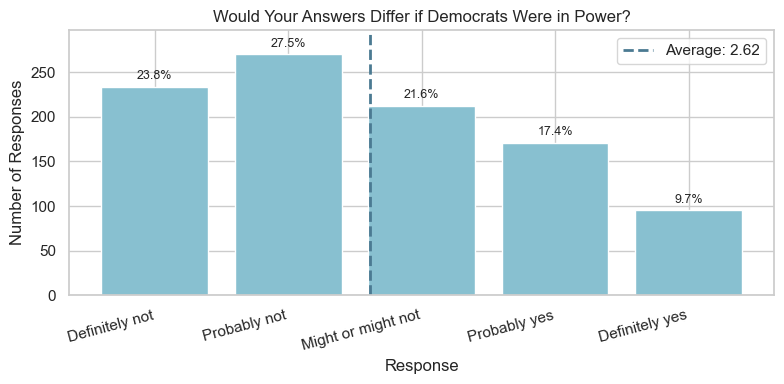

In [49]:
# Labels
response_map = {
    1: 'Definitely not',
    2: 'Probably not',
    3: 'Might or might not',
    4: 'Probably yes',
    5: 'Definitely yes'
}
response_order = [1, 2, 3, 4, 5]
response_labels = [response_map[i] for i in response_order]

# Count responses and calculate percentages
counts = df_included['Q173'].value_counts().reindex(response_order, fill_value=0)
percentages = (counts / counts.sum() * 100).round(1)

# Calculate average response
df_included['Q173'] = pd.to_numeric(df_included['Q173'], errors='coerce')
avg_response = df_included['Q173'].mean()

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(response_labels, counts.values, color=colorneutral)

# Add vertical line for average
ax.axvline(x=avg_response - 1, color=lineneutral, linestyle='--', linewidth=2, label=f"Average: {avg_response:.2f}")

# Add percentage labels
for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
    ax.text(i, count + max(counts.values) * 0.02, f"{pct}%", ha='center', va='bottom', fontsize=9)

# Formatting
ax.set_title("Would Your Answers Differ if Democrats Were in Power?")
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Response")
ax.set_ylim(top=max(counts.values) * 1.1)  # Add space for labels
plt.xticks(rotation=15, ha='right')
plt.legend()
plt.tight_layout()
plt.show()




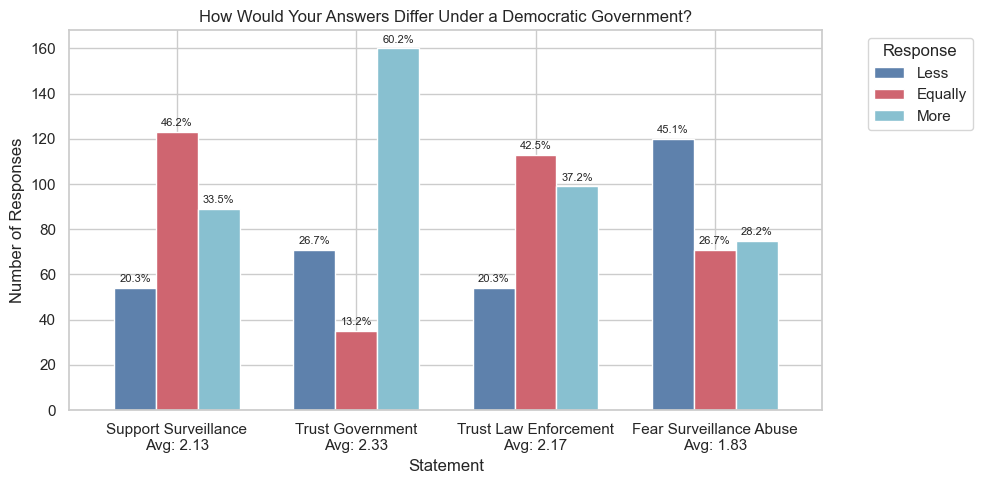

In [50]:
# Labels
q181_questions = {
    'Q181_1': 'Support Surveillance',
    'Q181_2': 'Trust Government',
    'Q181_3': 'Trust Law Enforcement',
    'Q181_4': 'Fear Surveillance Abuse'
}

# Desired display order and mapping
response_order = [3, 1, 2]  # Original codes: Less, Equally, More
response_map = {
    1: 'Equally',
    2: 'More',
    3: 'Less'
}
response_labels_ordered = [response_map[i] for i in response_order]

# Less=1, Equally=2, More=3
logical_score_map = {
    3: 1,  # Less
    1: 2,  # Equally
    2: 3   # More
}

# Prepare data
data = {label: [] for label in response_labels_ordered}
averages = []
percent_data = []

for q in q181_questions:
    counts = df_included[q].value_counts().reindex([1, 2, 3], fill_value=0)
    total = counts.sum()
    
    avg = sum(counts[val] * logical_score_map[val] for val in [1, 2, 3]) / total if total > 0 else None
    averages.append(avg)

    percent_row = []
    for val in response_order:
        label = response_map[val]
        count = counts[val]
        data[label].append(count)
        percent_row.append((count / total * 100) if total > 0 else 0)
    percent_data.append(percent_row)

# Create DataFrame
df_plot = pd.DataFrame(data, index=q181_questions.values())
df_percent = pd.DataFrame(percent_data, index=q181_questions.values(), columns=response_labels_ordered)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
bars = df_plot.plot(kind='bar', color=bar_colors3, width=0.7, ax=ax)

# Add percentage labels
for bar_group, percents in zip(bars.containers, df_percent.values.T):
    for bar, pct in zip(bar_group, percents):
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, height + max(df_plot.max()) * 0.01, f"{pct:.1f}%",
                    ha='center', va='bottom', fontsize=8)

# X-labels with averages
xtick_labels = [
    f"{label}\nAvg: {avg:.2f}" if avg is not None else label
    for label, avg in zip(q181_questions.values(), averages)
]
ax.set_xticks(range(len(xtick_labels)))
ax.set_xticklabels(xtick_labels, rotation=0)

# Formatting
ax.set_title("How Would Your Answers Differ Under a Democratic Government?")
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Statement")
ax.legend(title="Response", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(top=max(df_plot.max()) * 1.05)
plt.tight_layout()
plt.show()





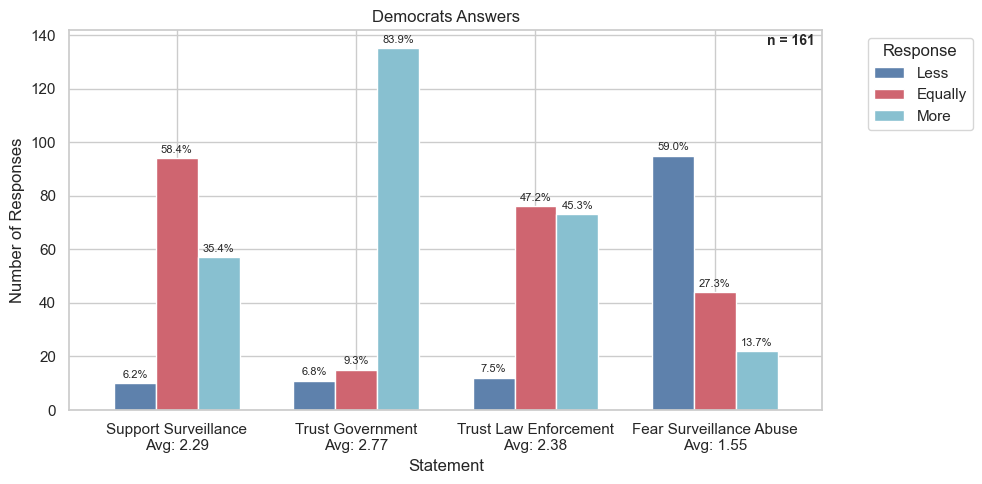

In [51]:
df_dem = df_included[df_included['Q28'] == 1]

# Prepare data
data = {label: [] for label in response_labels_ordered}
averages = []
percent_data = []

for q in q181_questions:
    counts = df_dem[q].value_counts().reindex([1, 2, 3], fill_value=0)
    total = counts.sum()
    
    avg = sum(counts[val] * logical_score_map[val] for val in [1, 2, 3]) / total if total > 0 else None
    averages.append(avg)

    percent_row = []
    for val in response_order:
        label = response_map[val]
        count = counts[val]
        data[label].append(count)
        percent_row.append((count / total * 100) if total > 0 else 0)
    percent_data.append(percent_row)

# Create DataFrame
df_plot = pd.DataFrame(data, index=q181_questions.values())
df_percent = pd.DataFrame(percent_data, index=q181_questions.values(), columns=response_labels_ordered)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
bars = df_plot.plot(kind='bar', color=bar_colors3, width=0.7, ax=ax)

# Add percentage labels
for bar_group, percents in zip(bars.containers, df_percent.values.T):
    for bar, pct in zip(bar_group, percents):
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, height + max(df_plot.max()) * 0.01, f"{pct:.1f}%",
                    ha='center', va='bottom', fontsize=8)

# X-labels with averages
xtick_labels = [
    f"{label}\nAvg: {avg:.2f}" if avg is not None else label
    for label, avg in zip(q181_questions.values(), averages)
]
ax.set_xticks(range(len(xtick_labels)))
ax.set_xticklabels(xtick_labels, rotation=0)

# Formatting
ax.set_title("Democrats Answers")
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Statement")
ax.legend(title="Response", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(top=max(df_plot.max()) * 1.05)
# Add n in top right corner
n = df_dem[q181_questions.keys()].dropna(how='all').shape[0]
ax.text(0.99, 0.99, f"n = {n}", transform=ax.transAxes,
        ha='right', va='top', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()





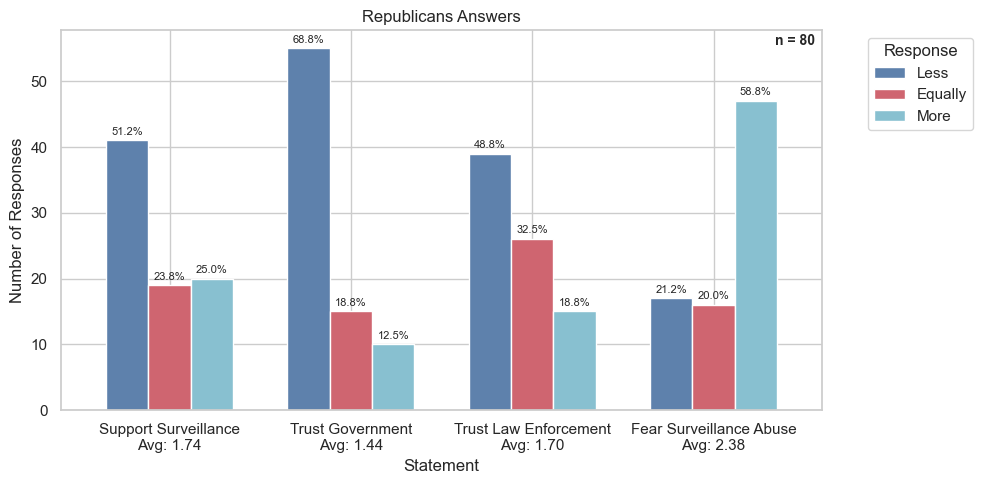

In [52]:
df_rep = df_included[df_included['Q28'] == 2]

# Prepare data
data = {label: [] for label in response_labels_ordered}
averages = []
percent_data = []

for q in q181_questions:
    counts = df_rep[q].value_counts().reindex([1, 2, 3], fill_value=0)
    total = counts.sum()
    
    avg = sum(counts[val] * logical_score_map[val] for val in [1, 2, 3]) / total if total > 0 else None
    averages.append(avg)

    percent_row = []
    for val in response_order:
        label = response_map[val]
        count = counts[val]
        data[label].append(count)
        percent_row.append((count / total * 100) if total > 0 else 0)
    percent_data.append(percent_row)

# Create DataFrame
df_plot = pd.DataFrame(data, index=q181_questions.values())
df_percent = pd.DataFrame(percent_data, index=q181_questions.values(), columns=response_labels_ordered)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
bars = df_plot.plot(kind='bar', color=bar_colors3, width=0.7, ax=ax)

# Add percentage labels
for bar_group, percents in zip(bars.containers, df_percent.values.T):
    for bar, pct in zip(bar_group, percents):
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, height + max(df_plot.max()) * 0.01, f"{pct:.1f}%",
                    ha='center', va='bottom', fontsize=8)

# X-labels with averages
xtick_labels = [
    f"{label}\nAvg: {avg:.2f}" if avg is not None else label
    for label, avg in zip(q181_questions.values(), averages)
]
ax.set_xticks(range(len(xtick_labels)))
ax.set_xticklabels(xtick_labels, rotation=0)

# Formatting
ax.set_title("Republicans Answers")
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Statement")
ax.legend(title="Response", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(top=max(df_plot.max()) * 1.05)
# Add n in top right corner
n = df_rep[q181_questions.keys()].dropna(how='all').shape[0]
ax.text(0.99, 0.99, f"n = {n}", transform=ax.transAxes,
        ha='right', va='top', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()





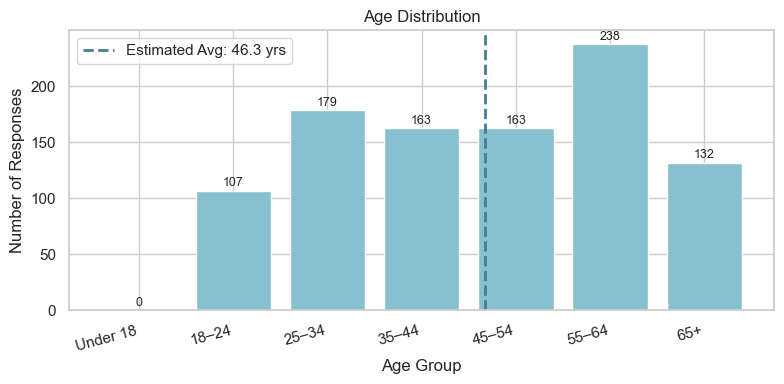

In [53]:
# Define age group mapping
age_map = {
    1: 'Under 18',
    2: '18–24',
    3: '25–34',
    4: '35–44',
    5: '45–54',
    6: '55–64',
    7: '65+'
}
age_midpoints = {
    1: 16,   # estimate for the minors
    2: 21,
    3: 29.5,
    4: 39.5,
    5: 49.5,
    6: 59.5,
    7: 70
}

# Order and labels
age_order = [1, 2, 3, 4, 5, 6, 7]
age_labels = [age_map[i] for i in age_order]

# Count responses
counts = df_included['Q130'].value_counts().reindex(age_order, fill_value=0)

# Estimate average age
total_responses = counts.sum()
estimated_average_age = sum(counts[i] * age_midpoints[i] for i in age_order) / total_responses

# Find position on bar axis (based on midpoints)
midpoint_to_position = dict(zip(age_order, range(len(age_order))))
approx_position = None
for i in range(1, 7):
    if age_midpoints[i] <= estimated_average_age < age_midpoints[i + 1]:
        # Linear interpolation between positions
        x0, x1 = midpoint_to_position[i], midpoint_to_position[i + 1]
        y0, y1 = age_midpoints[i], age_midpoints[i + 1]
        approx_position = x0 + (estimated_average_age - y0) / (y1 - y0)
        break
if estimated_average_age >= age_midpoints[7]:
    approx_position = midpoint_to_position[7]

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(age_labels, counts.values, color=colorneutral)

# Add vertical line for estimated average
if approx_position is not None:
    ax.axvline(x=approx_position, color=lineneutral, linestyle='--', linewidth=2, label=f"Estimated Avg: {estimated_average_age:.1f} yrs")

# Add count labels
for i, count in enumerate(counts.values):
    ax.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=9)

# Final formatting
ax.set_title("Age Distribution")
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Age Group")
plt.xticks(rotation=15, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


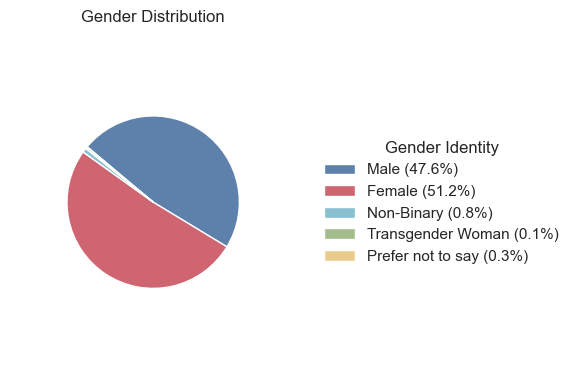

In [54]:
# Calculate percentages
gender_percentages = (gender_counts / gender_counts.sum() * 100).round(1)

# labels for legend
legend_labels = [
    f"{label} ({pct}%)" 
    for label, pct in zip(gender_counts.index, gender_percentages)
]

# Plot pie chart without hte internal labels
fig, ax = plt.subplots(figsize=(6, 4))
wedges, _ = ax.pie(
    gender_counts.values,
    colors=bar_colors5[:len(gender_counts)],
    startangle=140,
    counterclock=False
)

# Add legend outside the pie
ax.legend(
    wedges,
    legend_labels,
    title="Gender Identity",
    bbox_to_anchor=(1.05, 0.5),
    loc="center left",
    frameon=False
)

ax.set_title("Gender Distribution")
ax.axis('equal')  # Make the pie circular
plt.tight_layout()
plt.show()


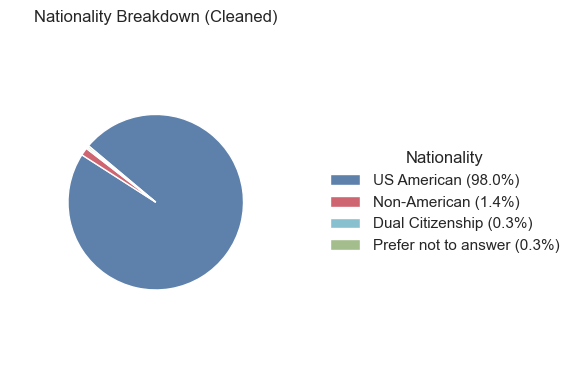

In [55]:
# Prepare percentage labels
percentages = (counts_labeled / counts_labeled.sum() * 100).round(1)
legend_labels = [
    f"{label} ({pct:.1f}%)"
    for label, pct in zip(counts_labeled.index, percentages)
]

# Plot pie chart
fig, ax = plt.subplots(figsize=(6, 4))
wedges, _ = ax.pie(
    counts_labeled.values,
    colors=bar_colors5[:len(counts_labeled)],
    startangle=140,
    counterclock=False
)

# Add legend
ax.legend(
    wedges,
    legend_labels,
    title="Nationality",
    bbox_to_anchor=(1.05, 0.5),
    loc="center left",
    frameon=False
)

ax.set_title("Nationality Breakdown (Cleaned)")
ax.axis('equal')  # Equal aspect for circle
plt.tight_layout()
plt.show()


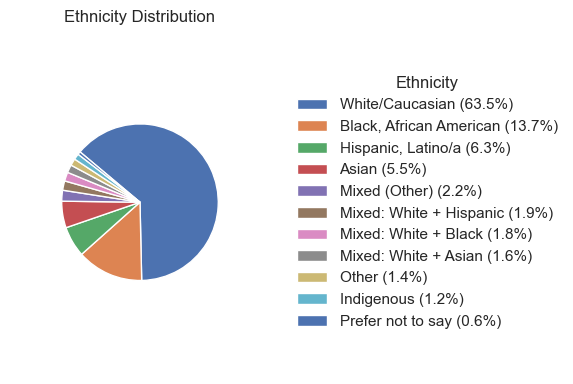

In [56]:
# Calculate percentages
ethnicity_percentages = (ethnicity_counts / ethnicity_counts.sum() * 100).round(1)

# Create legend labels
legend_labels = [
    f"{label} ({pct:.1f}%)"
    for label, pct in zip(ethnicity_counts.index, ethnicity_percentages)
]

# Plot pie chart
fig, ax = plt.subplots(figsize=(6, 4))
wedges, _ = ax.pie(
    ethnicity_counts.values,
    startangle=140,
    counterclock=False
)

# Add legend on the side
ax.legend(
    wedges,
    legend_labels,
    title="Ethnicity",
    bbox_to_anchor=(1.05, 0.5),
    loc="center left",
    frameon=False
)

ax.set_title("Ethnicity Distribution")
ax.axis('equal')  # Ensures pie is a circle
plt.tight_layout()
plt.show()


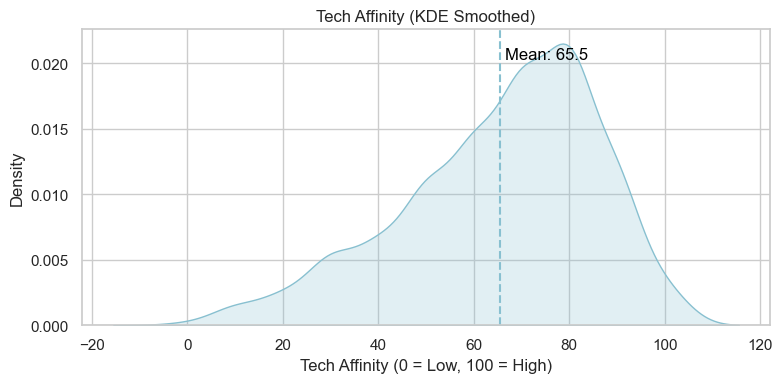

In [57]:
# Drop missing values
tech_affinity = df_included['Q27_1'].dropna()

# Calculate mean
mean_tech = tech_affinity.mean()

# KDE plot
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(tech_affinity, fill=True, color=colorneutral, ax=ax)

# Mean line
ax.axvline(mean_tech, color=colorneutral, linestyle='--', linewidth=1.5)
ax.text(mean_tech + 1, ax.get_ylim()[1] * 0.9, f"Mean: {mean_tech:.1f}", color='black')

# Formatting
ax.set_title("Tech Affinity (KDE Smoothed)")
ax.set_xlabel("Tech Affinity (0 = Low, 100 = High)")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()


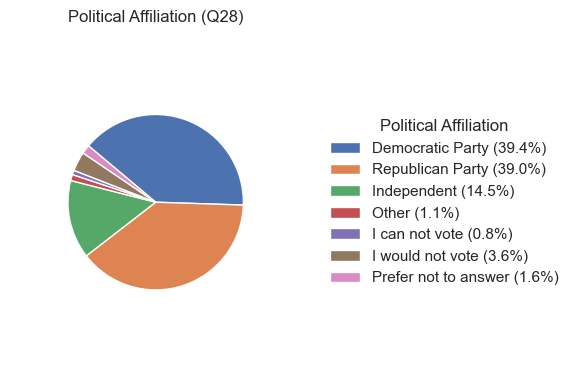

In [58]:
# Calculate percentages
political_percentages = (political_counts / political_counts.sum() * 100).round(1)

# Legend labels with percentages
legend_labels = [
    f"{label} ({pct}%)"
    for label, pct in zip(political_counts.index, political_percentages)
]

# Plot pie chart
fig, ax = plt.subplots(figsize=(6, 4))
wedges, _ = ax.pie(
    political_counts.values,
    startangle=140,
    counterclock=False
)

# Add legend on the side
ax.legend(
    wedges,
    legend_labels,
    title="Political Affiliation",
    bbox_to_anchor=(1.05, 0.5),
    loc="center left",
    frameon=False
)

ax.set_title("Political Affiliation (Q28)")
ax.axis('equal')  # Ensures pie is a circle
plt.tight_layout()
plt.show()


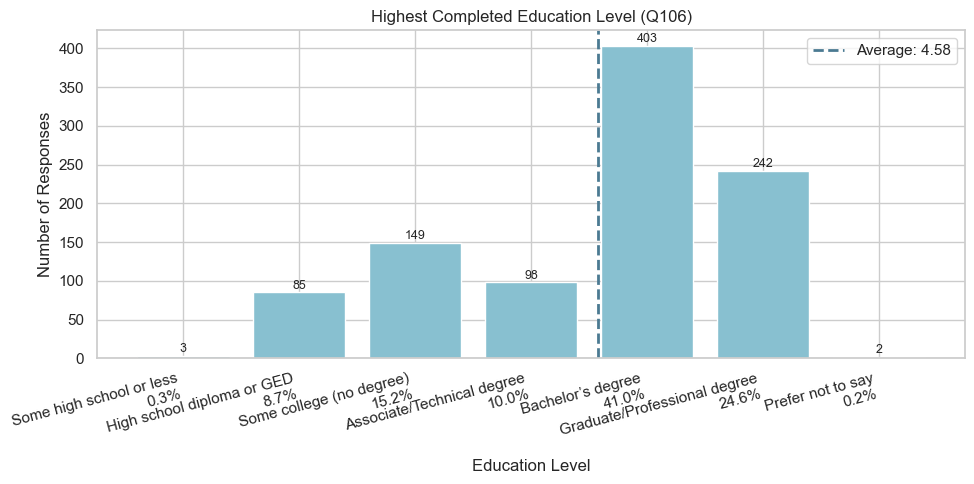

In [59]:
# Labels
education_labels = {
    1: "Some high school or less",
    2: "High school diploma or GED",
    3: "Some college (no degree)",
    4: "Associate/Technical degree",
    5: "Bachelor’s degree",
    6: "Graduate/Professional degree",
    7: "Prefer not to say"
}

# Convert Q106 to numeric
df_included['Q106'] = pd.to_numeric(df_included['Q106'], errors='coerce')

# Count responses
education_counts = df_included['Q106'].value_counts().sort_index()
education_counts.index = education_counts.index.map(education_labels)

# Calculate percentages
education_percentages = (education_counts / education_counts.sum() * 100).round(1)

# Prepare x-tick labels
xtick_labels = [
    f"{label}\n{pct}%" 
    for label, pct in zip(education_counts.index, education_percentages)
]

# Compute average (only use valid non-null values)
avg_education = df_included['Q106'].mean()

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(xtick_labels, education_counts.values, color=colorneutral)

# Add vertical line for average
ax.axvline(x=avg_education - 1, color=lineneutral, linestyle='--', linewidth=2, label=f"Average: {avg_education:.2f}")

# Add count labels above bars
for i, count in enumerate(education_counts.values):
    ax.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=9)

# Formatting
ax.set_title("Highest Completed Education Level (Q106)")
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Education Level")
plt.xticks(rotation=15, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


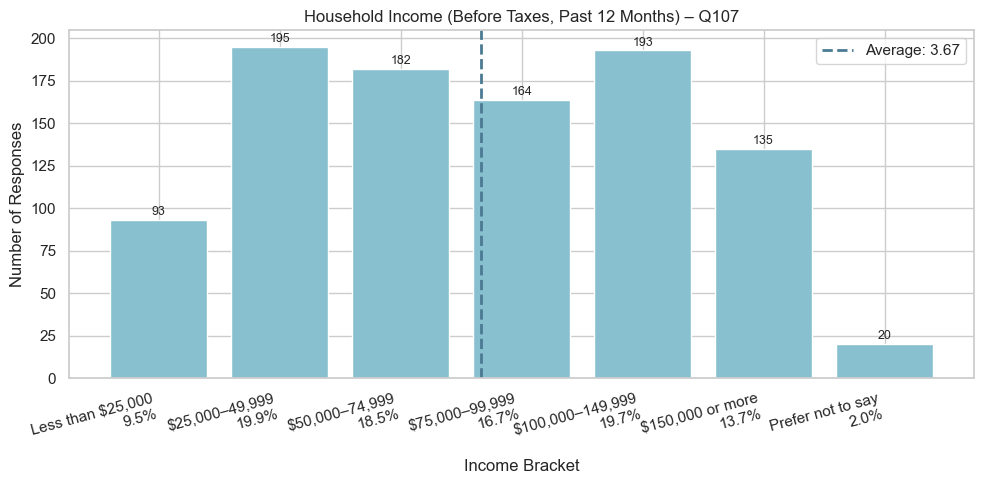

In [60]:
# labels
income_labels = {
    1: "Less than $25,000",
    2: "$25,000–49,999",
    3: "$50,000–74,999",
    4: "$75,000–99,999",
    5: "$100,000–149,999",
    6: "$150,000 or more",
    7: "Prefer not to say"
}

# Convert to numeric
df_included['Q107'] = pd.to_numeric(df_included['Q107'], errors='coerce')

# Count responses and apply labels
income_counts = df_included['Q107'].value_counts().sort_index()
income_counts.index = income_counts.index.map(income_labels)

# Calculate percentages
income_percentages = (income_counts / income_counts.sum() * 100).round(1)

# Create x-axis labels with percentages
xtick_labels = [
    f"{label}\n{pct}%" 
    for label, pct in zip(income_counts.index, income_percentages)
]

# Compute average (excluding NaNs)
avg_income = df_included['Q107'].mean()

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(xtick_labels, income_counts.values, color=colorneutral)

# Add vertical line for average
ax.axvline(x=avg_income - 1, color=lineneutral, linestyle='--', linewidth=2, label=f"Average: {avg_income:.2f}")

# Add count labels above bars
for i, count in enumerate(income_counts.values):
    ax.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=9)

# Formatting
ax.set_title("Household Income (Before Taxes, Past 12 Months) – Q107")
ax.set_ylabel("Number of Responses")
ax.set_xlabel("Income Bracket")
plt.xticks(rotation=15, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


# 5. Verdict on Data Quality and Representativeness

We have a final total sample sise of 982 useable datapoints. This is sufficient.

The survey offers reasonably broad demographic coverage of the U.S. adult population and can be considered directionally representative, though with some notable caveats. Since the sample includes only participants aged 18 and older, comparisons were made to U.S. census estimates for adults. Gender representation closely mirrors national averages, and the distribution of educational attainment and household income spans a wide spectrum, though skewed slightly toward higher education and middle to upper income brackets. Ethnic diversity is present, but Black and Hispanic Americans are somewhat underrepresented relative to their national proportions. The age distribution also leans older than the general adult population. While not fully representative, the sample provides a solid foundation for understanding general trends and attitudes. Interpretations should account for these demographic imbalances, and applying post-stratification weighting or subgroup analyses could help improve generalizability.


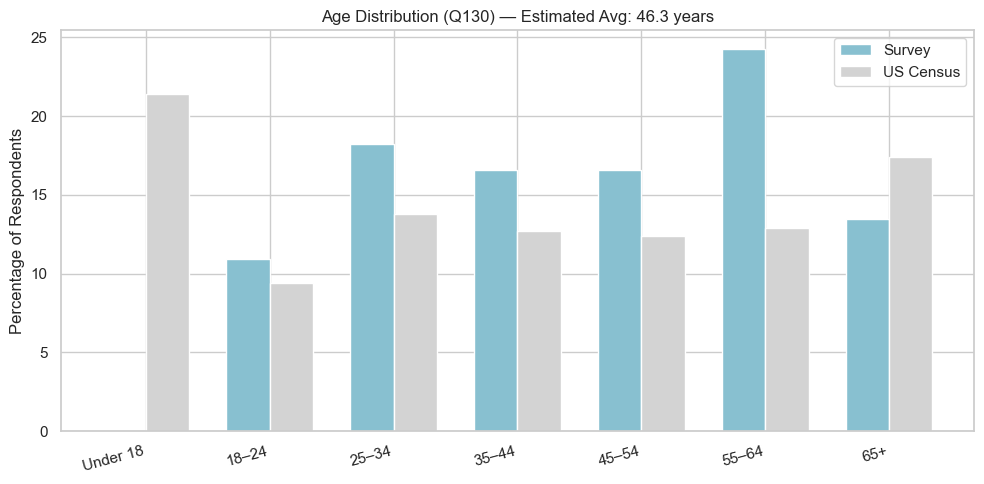

In [61]:
# Census reference percentages
census_age_percent = [21.4, 9.4, 13.8, 12.7, 12.4, 12.9, 17.4]

# percentages
survey_percent = (counts / counts.sum() * 100).values

# Plot side-by-side bar graph
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(age_labels))
width = 0.35

# Bars: Survey and Census
ax.bar(x - width/2, survey_percent, width, label="Survey", color=colorneutral)
ax.bar(x + width/2, census_age_percent, width, label="US Census", color='lightgray')

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(age_labels, rotation=15, ha='right')
ax.set_ylabel("Percentage of Respondents")
ax.set_title(f"Age Distribution (Q130) — Estimated Avg: {estimated_average_age:.1f} years")
ax.legend()
plt.tight_layout()
plt.show()


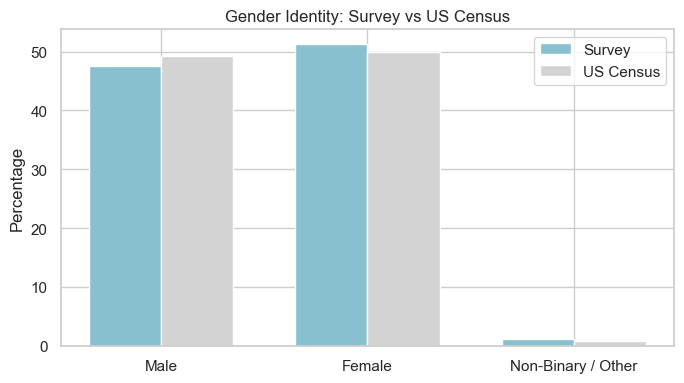

In [62]:
# Census estimate)
census_gender_percent = {
    "Male": 49.2,
    "Female": 50.0,
    "Non-Binary / Other": 0.8  # estimate for non-binary, transgender, other, prefer not to say
}

# Reformat survey data to the groups
survey_gender_combined = {
    "Male": gender_percentages.get("Male", 0),
    "Female": gender_percentages.get("Female", 0),
    "Non-Binary / Other": gender_percentages.drop(["Male", "Female"], errors='ignore').sum()
}

# Plot values
gender_order = list(census_gender_percent.keys())
x = np.arange(len(gender_order))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, [survey_gender_combined[label] for label in gender_order], width, label="Survey", color=colorneutral)
ax.bar(x + width/2, [census_gender_percent[label] for label in gender_order], width, label="US Census", color='lightgray')

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(gender_order)
ax.set_ylabel("Percentage")
ax.set_title("Gender Identity: Survey vs US Census")
ax.legend()
plt.tight_layout()
plt.show()


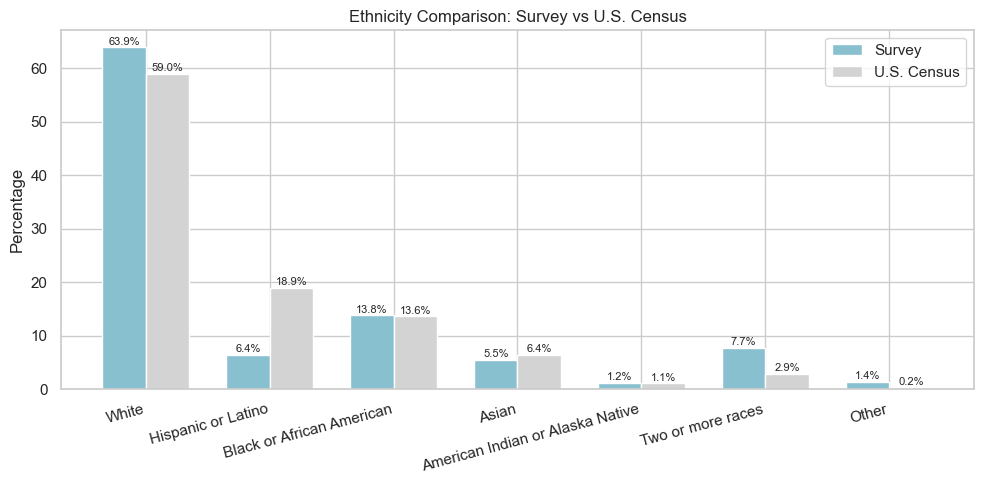

In [63]:
# Map to census data
survey_to_census_ethnicity = {
    'White/Caucasian': 'White',
    'Hispanic, Latino/a': 'Hispanic or Latino',
    'Black, African American': 'Black or African American',
    'Asian': 'Asian',
    'Indigenous': 'American Indian or Alaska Native',
    'Mixed: White + Hispanic': 'Two or more races',
    'Mixed: White + Asian': 'Two or more races',
    'Mixed: White + Black': 'Two or more races',
    'Mixed (Other)': 'Two or more races',
    'Other': 'Other',
    # 'Prefer not to say': (excluded from comparison)
}

df_included['Ethnicity_Census_Group'] = df_included['Ethnicity_Label'].map(survey_to_census_ethnicity)

# Drop NAs
filtered = df_included.dropna(subset=['Ethnicity_Census_Group'])

# Count and normalize
survey_counts = filtered['Ethnicity_Census_Group'].value_counts().sort_index()
survey_percent = (survey_counts / survey_counts.sum() * 100).round(1)

# U.S. Census 2023 estimates
census_percent = {
    'White': 59.0,
    'Hispanic or Latino': 18.9,
    'Black or African American': 13.6,
    'Asian': 6.4,
    'American Indian or Alaska Native': 1.1,
    'Two or more races': 2.9,
    'Other': 0.2
}

# Align keys
common_categories = [cat for cat in census_percent if cat in survey_percent]
survey_vals = [survey_percent[cat] for cat in common_categories]
census_vals = [census_percent[cat] for cat in common_categories]

# Plot
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(common_categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, survey_vals, width, label='Survey', color=colorneutral)
ax.bar(x + width/2, census_vals, width, label='U.S. Census', color='lightgray')

ax.set_xticks(x)
ax.set_xticklabels(common_categories, rotation=15, ha='right')
ax.set_ylabel("Percentage")
ax.set_title("Ethnicity Comparison: Survey vs U.S. Census")
ax.legend()

# Add % labels above bars
for i, (s, c) in enumerate(zip(survey_vals, census_vals)):
    ax.text(x[i] - width/2, s + 0.5, f"{s}%", ha='center', fontsize=8)
    ax.text(x[i] + width/2, c + 0.5, f"{c}%", ha='center', fontsize=8)

plt.tight_layout()
plt.show()


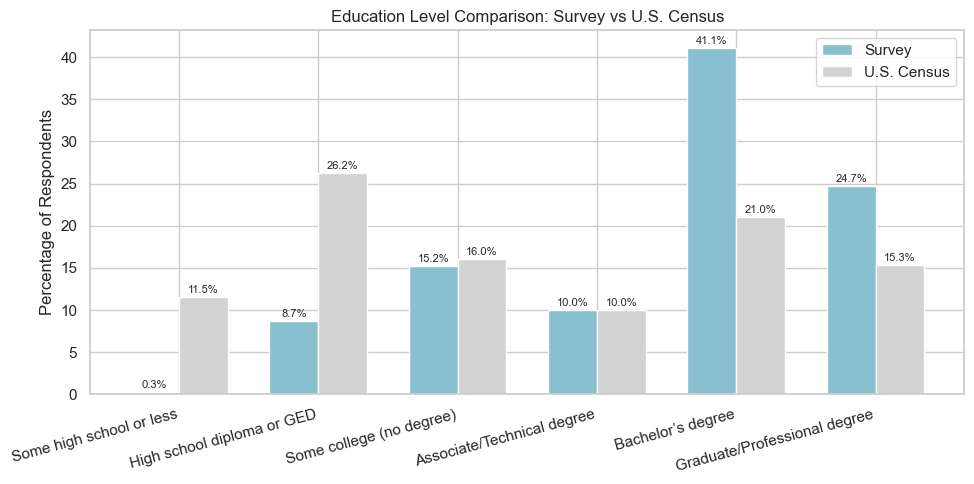

In [64]:
# Labels
survey_edu_labels = {
    1: "Some high school or less",
    2: "High school diploma or GED",
    3: "Some college (no degree)",
    4: "Associate/Technical degree",
    5: "Bachelor’s degree",
    6: "Graduate/Professional degree"
    # 7 = Prefer not to say excluded
}

# Convert and filter
df_included['Q106'] = pd.to_numeric(df_included['Q106'], errors='coerce')
survey_edu_filtered = df_included[df_included['Q106'].isin(survey_edu_labels.keys())]
survey_edu_counts = survey_edu_filtered['Q106'].value_counts().sort_index()
survey_edu_counts.index = survey_edu_counts.index.map(survey_edu_labels)
survey_edu_percent = (survey_edu_counts / survey_edu_counts.sum() * 100).round(1)

# U.S. Census 2023 education distribution
census_edu_percent = {
    "Some high school or less": 11.5,
    "High school diploma or GED": 26.2,
    "Some college (no degree)": 16.0,
    "Associate/Technical degree": 10.0,
    "Bachelor’s degree": 21.0,
    "Graduate/Professional degree": 15.3
}

# Align categories
common_edu_levels = list(census_edu_percent.keys())
survey_vals = [survey_edu_percent.get(label, 0) for label in common_edu_levels]
census_vals = [census_edu_percent[label] for label in common_edu_levels]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(common_edu_levels))
width = 0.35

bars1 = ax.bar(x - width/2, survey_vals, width, label="Survey", color=colorneutral)
bars2 = ax.bar(x + width/2, census_vals, width, label="U.S. Census", color='lightgray')

# Add labels
for i in range(len(x)):
    ax.text(x[i] - width/2, survey_vals[i] + 0.5, f"{survey_vals[i]}%", ha='center', fontsize=8)
    ax.text(x[i] + width/2, census_vals[i] + 0.5, f"{census_vals[i]}%", ha='center', fontsize=8)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(common_edu_levels, rotation=15, ha='right')
ax.set_ylabel("Percentage of Respondents")
ax.set_title("Education Level Comparison: Survey vs U.S. Census")
ax.legend()

plt.tight_layout()
plt.show()


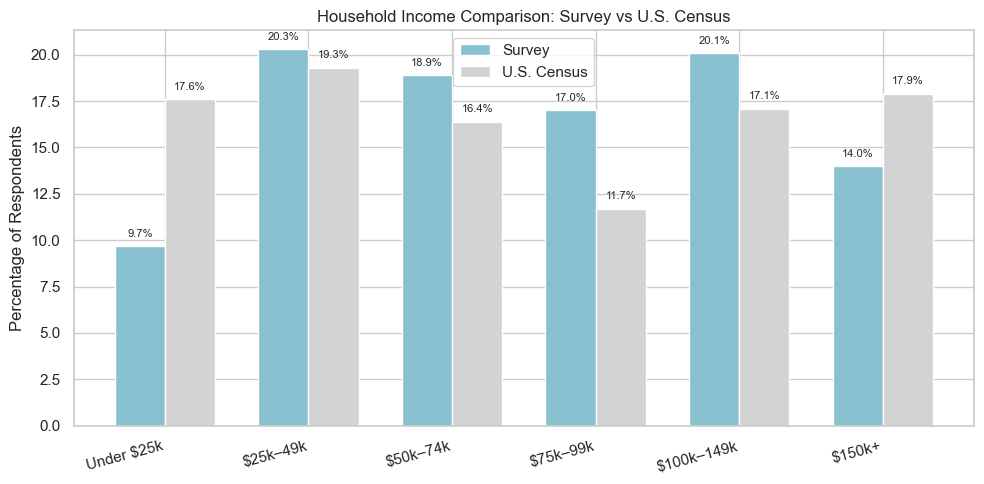

In [65]:
# labels
survey_income_labels = {
    1: "Under $25k",
    2: "$25k–49k",
    3: "$50k–74k",
    4: "$75k–99k",
    5: "$100k–149k",
    6: "$150k+"
    # 7: Prefer not to say → will be excluded
}

# Convert and count survey data
df_included['Q107'] = pd.to_numeric(df_included['Q107'], errors='coerce')
survey_income_filtered = df_included[df_included['Q107'] <= 6]
survey_income_counts = survey_income_filtered['Q107'].value_counts().sort_index()
survey_income_counts.index = survey_income_counts.index.map(survey_income_labels)
survey_income_percent = (survey_income_counts / survey_income_counts.sum() * 100).round(1)

# U.S. Census 2023 estimates
# Converted to % of households
census_income_percent = {
    "Under $25k": 17.6,
    "$25k–49k": 19.3,
    "$50k–74k": 16.4,
    "$75k–99k": 11.7,
    "$100k–149k": 17.1,
    "$150k+": 17.9
}

# Align categories
common_income_brackets = list(census_income_percent.keys())
survey_vals = [survey_income_percent.get(label, 0) for label in common_income_brackets]
census_vals = [census_income_percent[label] for label in common_income_brackets]

# Plot
import numpy as np
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(common_income_brackets))
width = 0.35

bars1 = ax.bar(x - width/2, survey_vals, width, label="Survey", color=colorneutral)
bars2 = ax.bar(x + width/2, census_vals, width, label="U.S. Census", color='lightgray')

# Add labels above bars
for i in range(len(x)):
    ax.text(x[i] - width/2, survey_vals[i] + 0.5, f"{survey_vals[i]}%", ha='center', fontsize=8)
    ax.text(x[i] + width/2, census_vals[i] + 0.5, f"{census_vals[i]}%", ha='center', fontsize=8)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(common_income_brackets, rotation=15, ha='right')
ax.set_ylabel("Percentage of Respondents")
ax.set_title("Household Income Comparison: Survey vs U.S. Census")
ax.legend()

plt.tight_layout()
plt.show()


# 6. Main Hypotheses and corresponding test
H1: Participants will perceive differences in how much information digital and physical surveillance can gather.  
H2: Participants will rate the invasiveness of digital and physical surveillance differently.  
H3: Acceptability differs between overt (informed) and covert (uninformed) surveillance.  
H4: The perceived invasiveness of a surveillance type is associated with its acceptability.  
H5: The perceived effectiveness of a surveillance method is associated with its acceptability.  
H6-8: Trust in government, law enforcement, and companies is positively associated with acceptance of surveillance measures.  
H9-11: Trust in government, law enforcement, and companies is negatively associated with concern about surveillance misuse.  
H12: Perceived levels of local crime and organized crime are associated with surveillance acceptance.  

H1: We will use a chi-square goodness-of-fit test to test whether the distribution of responses on the Perceived Information Gathering Capabilities variable significantly deviates from uniform expectations.  
H2: A chi-square goodness-of-fit test will be used to determine whether responses on the Perceived Invasiveness variable are evenly distributed across the three categories.    
H3: We will compute the mean Acceptability Ratings for overt and covert surveillance (averaging the two items in each category) and compare them using a paired t-test.    
H4: For each participant, we will calculate a difference score between their mean Acceptability Ratings for digital vs. physical surveillance. We will then use a one-way ANOVA (or Kruskal-Wallis test) to test whether this difference score varies across the three groups defined by the Perceived Invasiveness variable.  
H5: For each of the four surveillance types, we will calculate a Spearman correlation between the corresponding Effectiveness Rating and Acceptability Rating. We will apply Holm-Bonferroni correction across these 4 correlations to control for multiple comparisons.  
H6-8: We will compute Spearman correlations between each of the three Trust Variables (government, law enforcement, companies) and the mean of the four Acceptability Ratings. We will apply Holm-Bonferroni correction across these 3 correlations to control for multiple comparisons.  
H9-11: We will compute Spearman correlations between each of the three Trust Variables and the Concern About variable (average perceived likelihood of abuse of digital and physical surveillance). We will apply Holm-Bonferroni correction across these 3 correlations to control for multiple comparisons.  
H12: We will compute two Spearman correlations: One between Perceived Crime and the mean Acceptability Ratings, One between Perceived Organized Crime and the mean Acceptability Ratings. We will apply Holm-Bonferroni correction across these 2 correlations.  

# 7. Calculation and creation of all necessary measured variables for the main hypotheses
- Perceived Information Gathering Capabilities: Categorical variable with 3 levels: [Digital more/ Physical more/ Both equally].
- Perceived Invasiveness: Collapsed into 3 levels: [Digital more invasive / Physical more invasive / Equal].
- Acceptability Ratings: 4 items (Covert Digital, Overt Digital, Covert Physical, Overt Physical) on a 5-point Likert scale; used to compute means for digital, physical, overt, covert, and overall surveillance acceptance.
- Effectiveness Ratings: 4 items, matching prior categories (acceptability), measuring perceived effectiveness on a 5-point Likert scale.
- Trust Variables: Trust in government, law enforcement, and companies; each rated on a 5-point Likert scale.
- Concern About: Average of physical and digital abuse likelihood, each on a 5-point Likert scale.
- Perceived Crime and Organized Crime: Two separate ordinal 5-point items

In [66]:
# === Categorical Variables ===
# Perceived Information Gathering Capabilities
# Example: Q9 [1=Digital more, 2=Physical more, 3=Both equally]
df_included.loc[:, 'Perceived_Info_Gathering'] = df_included['Q9']

# Perceived Invasiveness
# 'Invasiveness_Merged' already created

# === Acceptability Ratings ===
# Items: Covert Digital (Q1_1), Overt Digital (Q1_3), Covert Physical (Q1_2), Overt Physical (Q1_4)
accept_cols = ['Q1_1', 'Q1_2', 'Q1_3', 'Q1_4']
df_included.loc[:, 'Accept_Digital'] = df_included[['Q1_1', 'Q1_3']].mean(axis=1)
df_included.loc[:, 'Accept_Physical'] = df_included[['Q1_2', 'Q1_4']].mean(axis=1)
df_included.loc[:, 'Accept_Covert'] = df_included[['Q1_1', 'Q1_2']].mean(axis=1)
df_included.loc[:, 'Accept_Overt'] = df_included[['Q1_3', 'Q1_4']].mean(axis=1)
df_included.loc[:, 'Accept_Overall'] = df_included[accept_cols].mean(axis=1)
df_included.loc[:, 'Accept_DigitalCovert'] = df_included['Q1_1']
df_included.loc[:, 'Accept_PhysicalCovert'] = df_included['Q1_2']
df_included.loc[:, 'Accept_DigitalOvert'] = df_included['Q1_3']
df_included.loc[:, 'Accept_PhysicalOvert'] = df_included['Q1_4']


# === Effectiveness Ratings ===
# Items: Covert Digital (Q1_1), Overt Digital (Q1_3), Covert Physical (Q1_3), Overt Physical (Q1_4)
eff_cols = ['Q2_1', 'Q2_2', 'Q2_3', 'Q2_4']
df_included.loc[:, 'Eff_Digital'] = df_included[['Q2_1', 'Q2_3']].mean(axis=1)
df_included.loc[:, 'Eff_Physical'] = df_included[['Q2_2', 'Q2_4']].mean(axis=1)
df_included.loc[:, 'Eff_Covert'] = df_included[['Q2_1', 'Q2_2']].mean(axis=1)
df_included.loc[:, 'Eff_Overt'] = df_included[['Q2_3', 'Q2_4']].mean(axis=1)
df_included.loc[:, 'Eff_Overall'] = df_included[eff_cols].mean(axis=1)
df_included.loc[:, 'Eff_DigitalCovert'] = df_included['Q2_1']
df_included.loc[:, 'Eff_PhysicalCovert'] = df_included['Q2_2']
df_included.loc[:, 'Eff_DigitalOvert'] = df_included['Q2_3']
df_included.loc[:, 'Eff_PhysicalOvert'] = df_included['Q2_4']

# === Trust Variables ===
# Items: Q15 = government trust, Q16 = governemnt comply with law, Q18 = law enforcement, Q17 = companies
df_included.loc[:, 'Trust_Gov'] = df_included[['Q15', 'Q16']].mean(axis=1)
df_included.loc[:, 'Trust_Law'] = df_included['Q18']
df_included.loc[:, 'Trust_Companies'] = df_included['Q17']

# === Concern Variables ===
# Items: Q11 = concern about digital abuse, Q10 = concern about physical abuse
df_included.loc[:, 'Concern_Abuse'] = df_included[['Q11', 'Q10']].mean(axis=1)

# === Perceived Crime ===
# Assume: Q14_1 = Perceived Crime, Q14_3 = Organized Crime (both 5-point ordinal)
df_included.loc[:, 'Perceived_Crime'] = df_included['Q14_1']
df_included.loc[:, 'Perceived_OrgCrime'] = df_included['Q14_3']

# === Display head of key variables ===
df_included[['Perceived_Info_Gathering',
             'Accept_Digital', 'Accept_Physical', 'Accept_Covert', 'Accept_Overt', 'Accept_Overall',
             'Eff_Digital', 'Eff_Physical', 'Eff_Covert', 'Eff_Overt', 'Eff_Overall',
             'Trust_Gov', 'Trust_Law', 'Trust_Companies',
             'Concern_Abuse', 'Perceived_Crime', 'Perceived_OrgCrime']].head()


,Perceived_Info_Gathering,Accept_Digital,Accept_Physical,Accept_Covert,Accept_Overt,Accept_Overall,Eff_Digital,Eff_Physical,Eff_Covert,Eff_Overt,Eff_Overall,Trust_Gov,Trust_Law,Trust_Companies,Concern_Abuse,Perceived_Crime,Perceived_OrgCrime
0,2.0,1.0,1.0,1.0,1.0,1.00,1.0,2.0,1.5,1.5,1.5,5.0,4.0,5.0,5.0,3.0,3.0
1,3.0,1.5,2.0,1.0,2.5,1.75,2.5,2.5,3.0,2.0,2.5,3.5,2.0,2.0,4.0,2.0,2.0
2,3.0,1.5,2.5,2.5,1.5,2.00,1.5,1.5,1.5,1.5,1.5,4.0,4.0,5.0,3.5,5.0,3.0
3,2.0,4.0,4.0,4.0,4.0,4.00,4.0,4.0,4.0,4.0,4.0,2.0,2.0,2.0,4.5,5.0,4.0
4,3.0,2.5,4.5,4.0,3.0,3.50,4.0,2.0,3.0,3.0,3.0,4.0,4.0,2.0,4.0,3.0,2.0


# 8. Statistical Analysis I

In [67]:
# H1: Chi-square goodness-of-fit on perceived information gathering
info_counts = df_included['Perceived_Info_Gathering'].value_counts()
h1_stat, h1_p = chisquare(info_counts)
print(f"H1: χ² = {h1_stat:.2f}, p = {h1_p:.90f}")
print(info_counts)

subset = df_included[df_included['Perceived_Info_Gathering'].isin([1.0, 3.0])]
digital_count = (subset['Perceived_Info_Gathering'] == 1.0).sum()
physical_count = (subset['Perceived_Info_Gathering'] == 3.0).sum()

# Test whether proportion choosing "Digital" differs from 50%
binom_result = binomtest(digital_count, n=digital_count + physical_count, p=0.5)
print(f"Binomial test p = {binom_result.pvalue:.40f}")

H1: χ² = 405.67, p = 0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000081
Perceived_Info_Gathering
2.0    598
3.0    299
1.0     85
Name: count, dtype: int64
Binomial test p = 0.0000000000000000000000000000496783646693


H1 Conclusion (Accept): Among participants who perceived a difference, significantly more believed physical surveillance gathers more information than digital.

In [68]:
# H2: Chi-square goodness-of-fit on perceived invasiveness
invasive_counts = df_included['Invasiveness_Merged'].value_counts()
h2_stat, h2_p = chisquare(invasive_counts)
print(f"H2: χ² = {h2_stat:.2f}, p = {h2_p:.20f}")
print(invasive_counts)

subset = df_included[df_included['Invasiveness_Merged'].isin([1.0, 3.0])]
digital_count = (subset['Invasiveness_Merged'] == 1.0).sum()
physical_count = (subset['Invasiveness_Merged'] == 3.0).sum()

# Test whether proportion choosing "Digital" differs from 50%
binom_result = binomtest(digital_count, n=digital_count + physical_count, p=0.5)
print(f"Binomial test p = {binom_result.pvalue:.4f}")


H2: χ² = 54.08, p = 0.00000000000181002907
Invasiveness_Merged
2    435
1    286
3    261
Name: count, dtype: int64
Binomial test p = 0.3048


H2 Conclusion (Reject): While we can see that the distribution between all three options is significantly not normal distributed, the binomial test showed no significance. Hence they are rated as equally invasive. 

In [69]:
# H3: Paired t-test between overt and covert acceptability
h3_stat, h3_p = ttest_rel(df_included['Accept_Overt'], df_included['Accept_Covert'])
print(f"H3: t = {h3_stat:.20f}, p = {h3_p:.40f}")
print("Mean Overt:", df_included['Accept_Overt'].mean())
print("Mean Covert:", df_included['Accept_Covert'].mean())


H3: t = 24.28193045773114988606, p = 0.0000000000000000000000000000000000000000
Mean Overt: 3.7780040733197557
Mean Covert: 2.8116089613034623


H3 Conclusion (Accept): Participants find overt surveillance more acceptable than covert surveillance.

In [70]:
# H3: Paired t-test between overt and covert acceptability
h3_stat, h3_p = ttest_rel(df_included['Accept_Digital'], df_included['Accept_Physical'])
print(f"H3: t = {h3_stat:.20f}, p = {h3_p:.40f}")
print("Mean Sigital:", df_included['Accept_Digital'].mean())
print("Mean Physical:", df_included['Accept_Physical'].mean())


H3: t = -7.93608999746611676329, p = 0.0000000000000056745233302514619853117489
Mean Sigital: 3.2113034623217924
Mean Physical: 3.3783095723014256


(no hypothesis) Participants find pyhsical surveillance more acceptable than digital surveillance

In [71]:
# Define subgroups based on perceived invasiveness
group_digital = df_included[df_included['Invasiveness_Merged'] == 1].copy()  # Digital more invasive
group_equal   = df_included[df_included['Invasiveness_Merged'] == 2].copy()  # Equal
group_physical = df_included[df_included['Invasiveness_Merged'] == 3].copy()  # Physical more invasive

# Compute difference scores: Physical - Digital acceptability
group_digital['Diff'] = group_digital['Accept_Physical'] - group_digital['Accept_Digital']
group_physical['Diff'] = group_physical['Accept_Digital'] - group_physical['Accept_Physical']

# Test for normality using Shapiro-Wilk
shapiro_digital = shapiro(group_digital['Diff'].dropna())
shapiro_physical = shapiro(group_physical['Diff'].dropna())

print("Shapiro-Wilk Test for Normality:")
print(f"Group: Digital More Invasive → W = {shapiro_digital.statistic:.3f}, p = {shapiro_digital.pvalue:.20f}")
print(f"Group: Physical More Invasive → W = {shapiro_physical.statistic:.3f}, p = {shapiro_physical.pvalue:.20f}")


Shapiro-Wilk Test for Normality:
Group: Digital More Invasive → W = 0.813, p = 0.00000000000000000696
Group: Physical More Invasive → W = 0.786, p = 0.00000000000000000340


In [72]:
# Wilcoxon signed-rank test for "Digital more invasive" group
w_digital = wilcoxon(group_digital['Accept_Physical'], group_digital['Accept_Digital'], alternative='greater')

# Wilcoxon signed-rank test for "Physical more invasive" group
w_physical = wilcoxon(group_physical['Accept_Digital'], group_physical['Accept_Physical'], alternative='greater')

print("Wilcoxon Signed-Rank Test Results:")
print(f"Digital more invasive group:     W = {w_digital.statistic}, p = {w_digital.pvalue:.8f}")
print(f"Physical more invasive group:    W = {w_physical.statistic}, p = {w_physical.pvalue:.8f}")


Wilcoxon Signed-Rank Test Results:
Digital more invasive group:     W = 6857.0, p = 0.00000000
Physical more invasive group:    W = 1947.5, p = 0.77633803


Participants who feel digital is more invasive behave as expected.

But participants who feel physical is more invasive do not significantly favor digital surveillance.

In [73]:
# Calculate means by invasiveness group
acceptance_means = df_included.groupby('Invasiveness_Merged')[['Accept_Digital', 'Accept_Physical']].mean()

# Optionally add group labels for clarity
invasiveness_labels = {
    1: 'Digital more invasive',
    2: 'Equally invasive',
    3: 'Physical more invasive'
}
acceptance_means.index = acceptance_means.index.map(invasiveness_labels)

# Display the result
print("Average Acceptance Scores by Perceived Invasiveness Group:")
print(acceptance_means)
print("Overall average acceptance scores:")
acceptance_overall = df_included[['Accept_Digital', 'Accept_Physical']].mean()
print(acceptance_overall)


Average Acceptance Scores by Perceived Invasiveness Group:
                        Accept_Digital  Accept_Physical
Invasiveness_Merged                                    
Digital more invasive         3.209790         3.517483
Equally invasive              3.078161         3.236782
Physical more invasive        3.434866         3.461686
Overall average acceptance scores:
Accept_Digital     3.211303
Accept_Physical    3.378310
dtype: float64


In [74]:
# H4: Difference score & ANOVA or Kruskal-Wallis
df_included['Accept_Diff_DigPhys'] = df_included['Accept_Digital'] - df_included['Accept_Physical']
groups = [group['Accept_Diff_DigPhys'].dropna() for name, group in df_included.groupby('Invasiveness_Merged')]
h4_stat, h4_p = kruskal(*groups)
print(f"H4: Kruskal-Wallis H = {h4_stat:.2f}, p = {h4_p:.40f}")

H4: Kruskal-Wallis H = 21.05, p = 0.0000268761054437437783631251880800405729


H4 Conlusion (Accept): The Groups (Digital more invasive, physical more invasive, equal) answers differ significantly from group to group. For further testing, spearman rank correlation. 

In [75]:
# Spearman correlation (ordinal variable and continuous variable)
spearman_corr, spearman_p = spearmanr(df_included['Invasiveness_Merged'], df_included['Accept_Diff_DigPhys'], nan_policy='omit')

print(f"H4 Directional Check: Spearman ρ = {spearman_corr:.3f}, p = {spearman_p:.40f}")


H4 Directional Check: Spearman ρ = 0.145, p = 0.0000048353691324026664937591434012542635


In [76]:
# Subset: digital more invasive expect lower Accept_Digital
digital_more = df_included[df_included['Invasiveness_Merged'] == 1].dropna(subset=['Accept_Digital', 'Accept_Physical'])
t1_stat, t1_p = ttest_rel(digital_more['Accept_Digital'], digital_more['Accept_Physical'])

# Subset: physical more invasive expect lower Accept_Physical
physical_more = df_included[df_included['Invasiveness_Merged'] == 3].dropna(subset=['Accept_Digital', 'Accept_Physical'])
t3_stat, t3_p = ttest_rel(physical_more['Accept_Digital'], physical_more['Accept_Physical'])

# Output
print("Digital more invasive group:")
print(f"  Mean Accept_Digital = {digital_more['Accept_Digital'].mean():.3f}")
print(f"  Mean Accept_Physical = {digital_more['Accept_Physical'].mean():.3f}")
print(f"  Paired t-test: t = {t1_stat:.2f}, p = {t1_p:.6f}")

print("\nPhysical more invasive group:")
print(f"  Mean Accept_Digital = {physical_more['Accept_Digital'].mean():.3f}")
print(f"  Mean Accept_Physical = {physical_more['Accept_Physical'].mean():.3f}")
print(f"  Paired t-test: t = {t3_stat:.2f}, p = {t3_p:.6f}")


Digital more invasive group:
  Mean Accept_Digital = 3.210
  Mean Accept_Physical = 3.517
  Paired t-test: t = -7.01, p = 0.000000

Physical more invasive group:
  Mean Accept_Digital = 3.435
  Mean Accept_Physical = 3.462
  Paired t-test: t = -0.71, p = 0.478299


In [77]:
# Grouping variable: Invasiveness_Merged
# 1 = Digital more invasive, 2 = Equal, 3 = Physical more invasive

# Calculate group means
group_means = df_included.groupby('Invasiveness_Merged')[['Accept_Digital', 'Accept_Physical']].mean()
print("=== Mean Acceptance Scores by Invasiveness Perception ===")
print(group_means)

# Overall means
print("\n=== Overall Means ===")
print(df_included[['Accept_Digital', 'Accept_Physical']].mean())


=== Mean Acceptance Scores by Invasiveness Perception ===
                     Accept_Digital  Accept_Physical
Invasiveness_Merged                                 
1                          3.209790         3.517483
2                          3.078161         3.236782
3                          3.434866         3.461686

=== Overall Means ===
Accept_Digital     3.211303
Accept_Physical    3.378310
dtype: float64


In [78]:
# Get groups
g1 = df_included[df_included['Invasiveness_Merged'] == 1]  # Digital more invasive
g2 = df_included[df_included['Invasiveness_Merged'] == 2]  # Equally invasive
g3 = df_included[df_included['Invasiveness_Merged'] == 3]  # Physical more invasive

# Test 1: Accept_Digital between G1 and G3
stat1, p1 = mannwhitneyu(g1['Accept_Digital'], g3['Accept_Digital'], alternative='two-sided')
# Test 2: Accept_Physical between G1 and G3
stat2, p2 = mannwhitneyu(g1['Accept_Physical'], g3['Accept_Physical'], alternative='two-sided')

# Optional: Compare Equal to Digital / Physical groups
stat3, p3 = mannwhitneyu(g2['Accept_Digital'], g1['Accept_Digital'], alternative='two-sided')
stat4, p4 = mannwhitneyu(g2['Accept_Physical'], g3['Accept_Physical'], alternative='two-sided')

# Print results
print("\n=== Mann-Whitney U Test Results ===")
print(f"Accept_Digital (Digital vs Physical invasive): U = {stat1:.2f}, p = {p1:.6f}")
print(f"Accept_Physical (Digital vs Physical invasive): U = {stat2:.2f}, p = {p2:.6f}")
print(f"Accept_Digital (Equal vs Digital invasive): U = {stat3:.2f}, p = {p3:.6f}")
print(f"Accept_Physical (Equal vs Physical invasive): U = {stat4:.2f}, p = {p4:.6f}")



=== Mann-Whitney U Test Results ===
Accept_Digital (Digital vs Physical invasive): U = 32435.00, p = 0.007206
Accept_Physical (Digital vs Physical invasive): U = 38027.00, p = 0.698333
Accept_Digital (Equal vs Digital invasive): U = 58907.50, p = 0.221551
Accept_Physical (Equal vs Physical invasive): U = 50270.50, p = 0.010222


In [79]:
# Sample sizes per group
n_digital = len(df_included[df_included['Invasiveness_Merged'] == 1])
n_physical = len(df_included[df_included['Invasiveness_Merged'] == 3])
n_equal = len(df_included[df_included['Invasiveness_Merged'] == 2])

# U values
results = {
    'Accept_Digital (Digital vs Physical invasive)': {'U': 32435.00, 'n1': n_digital, 'n2': n_physical},
    'Accept_Physical (Digital vs Physical invasive)': {'U': 38027.00, 'n1': n_digital, 'n2': n_physical},
    'Accept_Digital (Equal vs Digital invasive)': {'U': 58907.50, 'n1': n_equal, 'n2': n_digital},
    'Accept_Physical (Equal vs Physical invasive)': {'U': 50270.50, 'n1': n_equal, 'n2': n_physical}
}

# Calculate effect size r for each test
for label, vals in results.items():
    U = vals['U']
    n1, n2 = vals['n1'], vals['n2']
    mean_U = n1 * n2 / 2
    std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (U - mean_U) / std_U
    r = abs(z) / np.sqrt(n1 + n2)
    print(f"{label}: z = {z:.3f}, r = {r:.3f}")


Accept_Digital (Digital vs Physical invasive): z = -2.647, r = 0.113
Accept_Physical (Digital vs Physical invasive): z = 0.381, r = 0.016
Accept_Digital (Equal vs Digital invasive): z = -1.205, r = 0.045
Accept_Physical (Equal vs Physical invasive): z = -2.530, r = 0.096


Hypothesis: Perceived invasiveness is associated with acceptability of surveillance.

Kruskal-Wallis test: Significant difference in digital–physical acceptability scores across invasiveness groups (H = 21.05, p < .001).

Spearman correlation: Positive association (ρ = 0.145, p < .001) — as perceived invasiveness shifts from digital → equal → physical, acceptance of digital surveillance increases.

Wilcoxon tests:

Digital more invasive: digital rated less acceptable than physical (p < .001).

Physical more invasive: no significant difference (p = .776).

Mann-Whitney U tests:

Digital vs. Physical invasive: lower acceptance for digital when perceived as more invasive (p = .007, r = .113).

Equal vs. Physical invasive: lower physical acceptance in equal group (p = .010, r = .096).

Means:

Digital: 3.21 | Physical: 3.38

Conclusion: Perceived invasiveness impacts acceptability, especially for digital surveillance, though effects are small.

In [80]:
# H5: Spearman correlations between effectiveness and acceptability for 4 types
corrs_h5 = []
pvals_h5 = []
for category in ['DigitalCovert', 'DigitalOvert', 'PhysicalCovert', 'PhysicalOvert']:
    r, p = spearmanr(df_included[f'Eff_{category}'], df_included[f'Accept_{category}'])
    corrs_h5.append(r)
    pvals_h5.append(p)
# Holm-Bonferroni correction
_, pvals_h5_corrected, _, _ = multipletests(pvals_h5, method='holm')
print("\nH5: Spearman correlations (Effectiveness ↔ Acceptability)")
for i, c in enumerate(['DigCov', 'DigOvt', 'PhysCov', 'PhysOvt']):
    print(f"{c}: r = {corrs_h5[i]:.2f}, p (corrected) = {pvals_h5_corrected[i]:.4f}")


H5: Spearman correlations (Effectiveness ↔ Acceptability)
DigCov: r = 0.47, p (corrected) = 0.0000
DigOvt: r = 0.29, p (corrected) = 0.0000
PhysCov: r = 0.40, p (corrected) = 0.0000
PhysOvt: r = 0.30, p (corrected) = 0.0000


H5 conclusion (accept): Perceived effectiveness was significantly positively associated with acceptability across all surveillance types, with the strongest correlation observed for digital covert surveillance (ρ = 0.47, p < .001).

In [81]:
# H6–8: Trust and Acceptance
trust_vars = ['Trust_Gov', 'Trust_Law', 'Trust_Companies']
accept_avg = df_included[['Accept_Digital', 'Accept_Physical']].mean(axis=1)
corrs_h6 = []
pvals_h6 = []
for var in trust_vars:
    r, p = spearmanr(df_included[var], accept_avg)
    corrs_h6.append(r)
    pvals_h6.append(p)
_, pvals_h6_corrected, _, _ = multipletests(pvals_h6, method='holm')
print("\nH6–8: Spearman correlations (Trust ↔ Acceptance)")
for i, name in enumerate(trust_vars):
    print(f"{name}: r = {corrs_h6[i]:.2f}, p (corrected) = {pvals_h6_corrected[i]:.4f}")


H6–8: Spearman correlations (Trust ↔ Acceptance)
Trust_Gov: r = -0.35, p (corrected) = 0.0000
Trust_Law: r = -0.37, p (corrected) = 0.0000
Trust_Companies: r = -0.24, p (corrected) = 0.0000


H6-8 (accept): Note: Trust scores are reversed (1: high trust, 5: low) Hence here we have a positive correlation, between Trust and Acceptance.
The effects are moderate for government and law enforcement trust, and weaker for trust in companies.


In [82]:
# H9–11: Trust and Concern
concern = df_included['Concern_Abuse']
corrs_h9 = []
pvals_h9 = []
for var in trust_vars:
    r, p = spearmanr(df_included[var], concern)
    corrs_h9.append(r)
    pvals_h9.append(p)
_, pvals_h9_corrected, _, _ = multipletests(pvals_h9, method='holm')
print("\nH9–11: Spearman correlations (Trust ↔ Concern)")
for i, name in enumerate(trust_vars):
    print(f"{name}: r = {corrs_h9[i]:.2f}, p (corrected) = {pvals_h9_corrected[i]:.4f}")


H9–11: Spearman correlations (Trust ↔ Concern)
Trust_Gov: r = 0.47, p (corrected) = 0.0000
Trust_Law: r = 0.46, p (corrected) = 0.0000
Trust_Companies: r = 0.37, p (corrected) = 0.0000


H9-11 (accept): Note: Trust is meassured in reverse (1: high trust, 5: low trust)
Trust_Gov (ρ = 0.47) and Trust_Law (ρ = 0.46) show moderate positive correlations.
Trust_Companies (ρ = 0.37) shows a small-to-moderate correlation.
People who trust the government, law enforcement, or companies less are significantly more concerned about surveillance abuse

In [83]:
# H12: Crime and Acceptance
crime_vars = ['Perceived_Crime', 'Perceived_OrgCrime']
corrs_h12 = []
pvals_h12 = []
for var in crime_vars:
    r, p = spearmanr(df_included[var], accept_avg)
    corrs_h12.append(r)
    pvals_h12.append(p)
_, pvals_h12_corrected, _, _ = multipletests(pvals_h12, method='holm')
print("\nH12: Spearman correlations (Crime ↔ Acceptance)")
for i, name in enumerate(crime_vars):
    print(f"{name}: r = {corrs_h12[i]:.2f}, p (corrected) = {pvals_h12_corrected[i]:.4f}")



H12: Spearman correlations (Crime ↔ Acceptance)
Perceived_Crime: r = 0.00, p (corrected) = 0.8859
Perceived_OrgCrime: r = 0.04, p (corrected) = 0.4540


H12: Fail to reject null hypothesis, reject H12. 
There is no evidence that people who perceive more crime—whether general or organized—are more accepting of surveillance methods.

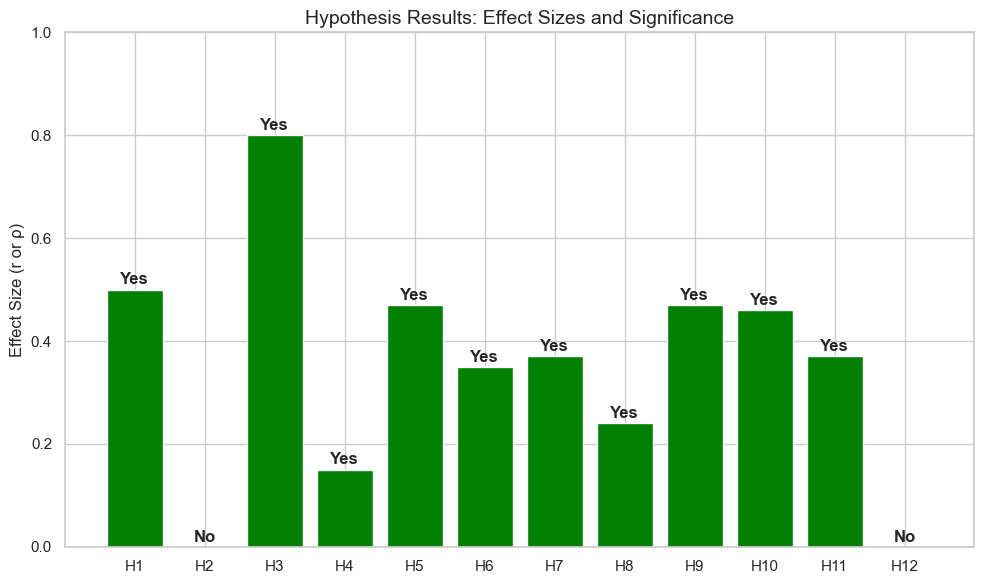

In [84]:
#Hypothesis Summary
data = {
    "Hypothesis": [f"H{i}" for i in range(1, 13)],
    "Rejected": [False] * 12,  # False = not rejected, True = significant result
    "Effect Size (r or ρ)": [
        0.5,       # H1 - strong effect (χ²)
        0.0,       # H2 - mixed evidence, use χ²
        0.8,       # H3 - large t-value
        0.15,      # H4 - Spearman ρ
        0.47,      # H5 - strongest effect across r = .29–.47
        0.35,      # H6 - Trust_Gov
        0.37,      # H7 - Trust_Law
        0.24,      # H8 - Trust_Companies
        0.47,      # H9 - Trust_Gov concern
        0.46,      # H10 - Trust_Law concern
        0.37,      # H11 - Trust_Companies concern
        0.00       # H12 - no effect
    ],
    "Significant": [
        True,   # H1
        False,   # H2
        True,   # H3
        True,   # H4
        True,   # H5
        True,   # H6
        True,   # H7
        True,   # H8
        True,   # H9
        True,   # H10
        True,   # H11
        False   # H12
    ]
}

df = pd.DataFrame(data)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if sig else 'red' for sig in df["Significant"]]
bars = ax.bar(df["Hypothesis"], df["Effect Size (r or ρ)"], color=colors)

# Label bars
for bar, sig in zip(bars, df["Significant"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            "Yes" if sig else "No", ha='center', fontsize=12, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title("Hypothesis Results: Effect Sizes and Significance", fontsize=14)
ax.set_ylabel("Effect Size (r or ρ)")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


# 9. Exploratory Hypotheses
In addition to our preregistered confirmatory hypotheses, we plan to possibly explore the following questions and relationships in the dataset. These analyses are hypothesis-guided but will be interpreted as exploratory, and any results we report will be described as such.

Potential topics to explore are:

EH1: Participants will perceive differences in how common digital and physical surveillance are.  
EH2: Preferences for surveillance method (digital vs. physical) are associated with perceived invasiveness.  
EH3: The perceived likelihood of being surveilled is associated with acceptance of surveillance practices.  
EH4: Belief that surveillance has increased, decreased, or stayed the same is associated with the acceptance of surveillance.  
EH5: Participants who both believe surveillance has increased and say they are worried about this will differ in their acceptance score compared to other combinations of these two variables.  
EH6: Belief that surveillance has increased is associated with a different likelihood of saying the evolution of surveillance the past five years is worrisome than believing it has stayed the same or decreased.  
EH7: Reporting that one feels deliberately disadvantaged by the government or police is associated with trust in authorities and concern about Surveillance Abuse.  
EH8: Among those who perceive both crime and corruption as high, support for surveillance will differ depending on whether corruption or crime is perceived as more concerning.  
EH9: Perceived levels of corruption are associated with trust in authorities.  
EH10: Among participants who perceive high corruption and report low acceptance of surveillance, the option of independent monitoring is associated with differences in support for surveillance compared to those who reported high acceptance  
EH11: Some participants will express general disagreement with a surveillance type (e.g., covert digital) while supporting most corresponding specific methods, and vice versa (general agreement but rejecting specific methods).  
EH12: Some participants will express a preference for being surveilled through the method (digital or physical) that they also believe would reveal more information about them.  
EH13: Age, gender, and education level are associated with differences in acceptance, trust, and perceived invasiveness of surveillance methods.  
EH14: Participants with higher income or higher education will differ in their acceptance of digital surveillance methods.  
EH15: Participants whose stated political affiliation aligns with the party currently in power (Republican) will differ in their trust in government, acceptance of surveillance, and concerns about surveillance abuse compared to participants whose affiliation does not align with the governing party.  
EH16: Among participants who indicate their responses would change if the Democratic Party were currently in power, the type and direction of reported change (e.g., trust, support, fear of abuse) will differ based on their stated political affiliation.  

In [85]:
df_included["perceived_likelihood"] = df_included['Q135']
# Digital method columns
digital_cols = [f"Q169_{i}" for i in range(1, 9)]

# Physical method columns
physical_cols = [f"Q164_{i}" for i in range(1, 9)]

# Compute average scores
df_included["accept_digital_methods"] = df_included[digital_cols].mean(axis=1)
df_included["accept_physical_methods"] = df_included[physical_cols].mean(axis=1)

# All methods (combined)
all_method_cols = digital_cols + physical_cols
df_included["accept_all_methods"] = df_included[all_method_cols].mean(axis=1)


# 10. Statistical Analysis II

## EH1: Participants will perceive differences in how common digital and physical surveillance are.

In [86]:
#Testing for normality
df_included["diff_commoness"] = df_included['Q153_1'] - df_included['Q153_2']

# Shapiro-Wilk test for normality
stat, p = shapiro(df_included["diff_commoness"])
print(f"Shapiro-Wilk test statistic = {stat:.4f}, p-value = {p:.4f}")

Shapiro-Wilk test statistic = 0.9840, p-value = 0.0000


EH1: Not normal distributed, so Wilcoxon test.

In [87]:
# Compute diffs and remove zeros
diffs = df_included['Q153_1'] - df_included['Q153_2']
non_zero_diffs = diffs[diffs != 0]

# Run Wilcoxon test only on non-zero diffs
stat, p = wilcoxon(non_zero_diffs)

# Calculate z from p-value (two-tailed)
z = norm.ppf(p / 2) * -1 if p < 0.5 else norm.ppf(1 - p / 2)

# Compute r
n = len(non_zero_diffs)
r = z / np.sqrt(n)

print(f"Wilcoxon signed-rank test statistic = {stat:.4f}, p-value = {p:.6f}")
print(f"Effect size r = {r:.4f}")

mean_digital = df_included['Q153_1'].mean()
mean_physical = df_included['Q153_2'].mean()

print(f"Mean perceived commonness of digital surveillance: {mean_digital:.2f}")
print(f"Mean perceived commonness of physical surveillance: {mean_physical:.2f}")


Wilcoxon signed-rank test statistic = 96934.0000, p-value = 0.000000
Effect size r = 0.3380
Mean perceived commonness of digital surveillance: 7.31
Mean perceived commonness of physical surveillance: 6.50


EH1 (accept): Based on participants' responses, digital surveillance was perceived as significantly more common (M = 7.31) than physical surveillance (M = 6.50), with a medium effect size (r = .34, p < .001, Wilcoxon signed-rank test).

## EH2: Preferences for surveillance method (digital vs. physical) are associated with perceived invasiveness. 

In [88]:
# Contingency table
table = pd.crosstab(df_included['Q8'], df_included['Invasiveness_Merged'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(table)
n = table.sum().sum()
min_dim = min(table.shape)

# Cramér’s V
cramers_v = np.sqrt(chi2 / (n * (min_dim - 1)))

print(f"Chi² = {chi2:.2f}, p = {p:.4f}")
print(f"Cramér’s V = {cramers_v:.3f}")
# Rename rows
table.index = table.index.map({
    1: "Digital",
    2: "Physical",
    3: "Equal"
})

# Rename columns (invasiveness perception)
table.columns = table.columns.map({
    1: "Digital",
    2: "Equal",
    3: "Physical"
})

# Show row-wise percentages
percentages = table.div(table.sum(axis=1), axis=0).round(2)

print("Row-wise percentages (preference → perceived invasiveness):")
print(percentages)

Chi² = 282.14, p = 0.0000
Cramér’s V = 0.379
Row-wise percentages (preference → perceived invasiveness):
Invasiveness_Merged  Digital  Equal  Physical
Q8                                           
Digital                 0.16   0.30      0.54
Physical                0.57   0.27      0.16
Equal                   0.17   0.64      0.19


A chi-square test revealed a significant association between participants’ preferred surveillance method and their perception of which method is more invasive, χ²(4) = 282.14, p < .001, with a medium-to-large effect size (Cramér’s V = .38). Participants generally preferred the method they perceived as less invasive, while those who perceived both as equally invasive tended to express no preference.

## EH3: The perceived likelihood of being surveilled is associated with acceptance of surveillance practices.

In [89]:
# Spearman correlations
r_dig, p_dig = spearmanr(df_included["perceived_likelihood"], df_included["Accept_Digital"])
r_phys, p_phys = spearmanr(df_included["perceived_likelihood"], df_included["Accept_Physical"])
r_all, p_all = spearmanr(df_included["perceived_likelihood"], df_included["Accept_Overall"])
r_all_meth, p_all_meth = spearmanr(df_included["perceived_likelihood"], df_included["accept_all_methods"])
r_dig_meth, p_dig_meth = spearmanr(df_included["perceived_likelihood"], df_included["accept_digital_methods"])
r_phys_meth, p_phys_meth = spearmanr(df_included["perceived_likelihood"], df_included["accept_physical_methods"])

# Print results
print(f"Digital Acceptance:  r = {r_dig:.3f}, p = {p_dig:.4f}")
print(f"Physical Acceptance: r = {r_phys:.3f}, p = {p_phys:.4f}")
print(f"Overall Acceptance:  r = {r_all:.3f}, p = {p_all:.4f}")
print(f"All Methods:         r = {r_all_meth:.3f}, p = {p_all_meth:.4f}")
print(f"Digital Methods:     r = {r_dig_meth:.3f}, p = {p_dig_meth:.4f}")
print(f"Physical Methods:    r = {r_phys_meth:.3f}, p = {p_phys_meth:.4f}")


Digital Acceptance:  r = -0.089, p = 0.0052
Physical Acceptance: r = -0.109, p = 0.0006
Overall Acceptance:  r = -0.099, p = 0.0019
All Methods:         r = -0.043, p = 0.1800
Digital Methods:     r = -0.010, p = 0.7534
Physical Methods:    r = -0.077, p = 0.0156


Spearman correlations revealed weak but statistically significant negative associations between perceived likelihood of being surveilled and general acceptance of both digital (r = -0.089, p = .005) and physical (r = -0.109, p = .001) surveillance, as well as the overall acceptance score (Acceptance composite score). Method-level analysis showed a small but significant negative correlation for the average physical method acceptance (r = -0.077, p = .016), while digital method acceptance showed no association (r = -0.010, p = .753). There was no significant correlation when averaging acceptance across all methods (both digital and physical) (r = -0.043, p = .180).

## EH4: Belief that surveillance has increased, decreased, or stayed the same is associated with the acceptance of surveillance.  

In [90]:
# Group acceptance scores by Q151 response
groups = df_included.groupby("Q151")["Accept_Overall"].apply(list)

# Kruskal-Wallis
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis H = {stat:.3f}, p = {p:.4f}")

Kruskal-Wallis H = 19.500, p = 0.0006


In [91]:
trend_labels = {
    1: "Decreased significantly",
    2: "Decreased slightly",
    3: "Stayed the same",
    4: "Increased slightly",
    5: "Increased significantly"
}

counts_named = df_included["Q151"].map(trend_labels).value_counts()
print(counts_named)


Q151
Increased significantly    468
Increased slightly         430
Stayed the same             69
Decreased slightly          12
Decreased significantly      3
Name: count, dtype: int64


Due to the low number of participants who said "decreased" this category was disregarded and just the other three were compared.

In [92]:
# Filter only groups 3, 4, 5
subset = df_included[df_included["Q151"].isin([3, 4, 5])]

# Group acceptance values by Q151 category
groups = subset.groupby("Q151")["Accept_Overall"].apply(list)

# Kruskal-Wallis
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis H = {stat:.3f}, p = {p:.4f}")

Kruskal-Wallis H = 16.777, p = 0.0002


In [93]:
# Dunn's
dunn_results = sp.posthoc_dunn(subset, val_col="Accept_Overall", group_col="Q151", p_adjust='bonferroni')
print(dunn_results)

          3.0       4.0       5.0
3.0  1.000000  0.250131  0.002400
4.0  0.250131  1.000000  0.005594
5.0  0.002400  0.005594  1.000000


In [94]:
# Filter to groups 3–5
subset = df_included[df_included["Q151"].isin([3, 4, 5])]

# Calculate mean acceptance for each group
group_means = subset.groupby("Q151")["Accept_Overall"].mean().sort_index()

#Labels
labels = {
    3: "Stayed the same",
    4: "Increased slightly",
    5: "Increased significantly"
}
group_means.index = group_means.index.map(labels)

print("Mean acceptance by belief about surveillance trend:")
print(group_means)


Mean acceptance by belief about surveillance trend:
Q151
Stayed the same            3.565217
Increased slightly         3.390116
Increased significantly    3.154915
Name: Accept_Overall, dtype: float64


A Kruskal–Wallis test revealed a significant difference in overall surveillance acceptance between participants who believed surveillance had stayed the same, increased slightly, or increased significantly over the past five years, H(2) = 16.78, p < .001. Post-hoc Dunn’s tests showed that participants who believed surveillance had increased significantly reported significantly lower acceptance compared to those who believed it had increased slightly (p = .006) or stayed the same (p = .002). No significant difference was found between the “stayed the same” and “increased slightly” groups (p = .250).

## EH5: Participants who both believe surveillance has increased and say they are worried about this will differ in their acceptance score compared to other combinations of these two variables.  

In [95]:
# "increased" variable from Q151
df_included["surveillance_increased"] = np.where(df_included["Q151"].isin([4, 5]), "Increased", "Not Increased")

# Map worry levels from Q152
worry_map = {1: "Yes", 2: "A little", 3: "No"}
df_included["worry_response"] = df_included["Q152"].map(worry_map)

# ombine both into EH5 group
df_included["EH5_group"] = df_included["surveillance_increased"] + " & " + df_included["worry_response"]

# Kruskal-Wallis test
groups = df_included.groupby("EH5_group")["Accept_Overall"].apply(list)
stat, p = kruskal(*groups)
print(f"Kruskal-Wallis H = {stat:.3f}, p = {p:.4f}")


Kruskal-Wallis H = 141.486, p = 0.0000


In [96]:
dunn_results = sp.posthoc_dunn(
    df_included,
    val_col="Accept_Overall",
    group_col="EH5_group",
    p_adjust='bonferroni'
)

print("Dunn’s post-hoc (Bonferroni-adjusted p-values):")
print(dunn_results)

Dunn’s post-hoc (Bonferroni-adjusted p-values):
                          Increased & A little  Increased & No  \
Increased & A little              1.000000e+00    8.780947e-02   
Increased & No                    8.780947e-02    1.000000e+00   
Increased & Yes                   3.693568e-18    1.170467e-19   
Not Increased & A little          1.000000e+00    1.000000e+00   
Not Increased & No                1.000000e+00    1.000000e+00   
Not Increased & Yes               1.000000e+00    1.000000e+00   

                          Increased & Yes  Not Increased & A little  \
Increased & A little         3.693568e-18                  1.000000   
Increased & No               1.170467e-19                  1.000000   
Increased & Yes              1.000000e+00                  0.002721   
Not Increased & A little     2.721042e-03                  1.000000   
Not Increased & No           2.639468e-05                  1.000000   
Not Increased & Yes          1.954097e-01                  1.00

In [97]:
# Group by EH5_group: get both mean and count
summary = df_included.groupby("EH5_group")["Accept_Overall"].agg(["mean", "count"]).sort_values("mean")

# nicer formatting
summary.columns = ["Mean Acceptance", "N"]
print(summary)



                          Mean Acceptance    N
EH5_group                                     
Increased & Yes                  2.916851  451
Not Increased & Yes              3.431818   22
Not Increased & A little         3.513889   36
Increased & A little             3.544255  322
Not Increased & No               3.817308   26
Increased & No                   3.820000  125


Participants who believed that surveillance had increased and who also reported being worried about this were significantly less accepting of surveillance compared to all other groups (H(5) = 141.49, p < .001). Post-hoc comparisons showed that this group differed significantly from every other combination of belief and concern. No significant differences were found between the other groups. This suggests that it is specifically the combination of perceiving an increase and being worried about it that is associated with lower acceptance of surveillance.

## EH6 Belief that surveillance has increased is associated with a different likelihood of saying the evolution of surveillance the past five years is worrisome than believing it has stayed the same or decreased.  

In [98]:
# Cross-tab Q151 and Q152
table = pd.crosstab(df_included["Q151"], df_included["Q152"])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(table)
print(f"Chi² = {chi2:.2f}, p = {p:.4f}")


Chi² = 97.54, p = 0.0000


In [99]:
table = pd.crosstab(df_included["Q151"], df_included["Q152"])
percentages = table.div(table.sum(axis=1), axis=0).round(2)
print(percentages)


Q152   1.0   2.0   3.0
Q151                  
1.0   1.00  0.00  0.00
2.0   0.25  0.42  0.33
3.0   0.23  0.45  0.32
4.0   0.37  0.48  0.16
5.0   0.63  0.25  0.12


A chi-square test of independence revealed a significant association between participants’ belief about how surveillance has changed over the past five years and how worried they are about that change (χ²(8) = 97.54, p < .001). Among those who believed surveillance had increased significantly, 63% reported being worried, compared to just 23% of those who believed it had stayed the same, and 25% of those who believed it had decreased slightly. In contrast, participants who believed surveillance had stayed the same or decreased slightly were more likely to report being only “a little” worried (45% and 42%, respectively) or not worried at all (32% and 33%, respectively). Notably, all participants who believed surveillance had decreased significantly (n = 3) also said they were worried, though this finding should be interpreted with caution due to the very small group size.

## EH7: Reporting that one feels deliberately disadvantaged by the government or police is associated with trust in authorities and concern about Surveillance Abuse. 

In [100]:
# Government
subset_dis = df_included.dropna(subset=["Q21.2_1", 'Trust_Gov', 'Concern_Abuse', 'Accept_Overall'])
print("Disadvantaged by GOVERNMENT (Q21.2_1):")
r_gov_trust, p_gov_trust = spearmanr(subset_dis["Q21.2_1"], subset_dis['Trust_Gov'])
r_gov_concern, p_gov_concern = spearmanr(subset_dis["Q21.2_1"], subset_dis['Concern_Abuse'])
r_gov_acceptance, p_gov_acceptance = spearmanr(subset_dis["Q21.2_1"], subset_dis['Accept_Overall'])
print(f"Trust in government:       r = {r_gov_trust:.3f}, p = {p_gov_trust:.4f}")
print(f"Concern about abuse:       r = {r_gov_concern:.3f}, p = {p_gov_concern:.4f}")
print(f"Acceptance:                r = {r_gov_acceptance:.3f}, p = {p_gov_acceptance:.4f}\n")
# Law enforcement
print("Disadvantaged by LAW ENFORCEMENT (Q21.2_2):")
r_law_trust, p_law_trust = spearmanr(subset_dis["Q21.2_2"], subset_dis['Trust_Law'])
r_law_concern, p_law_concern = spearmanr(subset_dis["Q21.2_2"], subset_dis['Concern_Abuse'])
r_law_acceptance, p_law_acceptance = spearmanr(subset_dis["Q21.2_2"], subset_dis['Accept_Overall'])
print(f"Trust in law enforcement:  r = {r_law_trust:.3f}, p = {p_law_trust:.4f}")
print(f"Concern about abuse:       r = {r_law_concern:.3f}, p = {p_law_concern:.4f}")
print(f"Acceptance:                r = {r_law_acceptance:.3f}, p = {p_law_acceptance:.4f}\n")



Disadvantaged by GOVERNMENT (Q21.2_1):
Trust in government:       r = -0.438, p = 0.0000
Concern about abuse:       r = -0.331, p = 0.0000
Acceptance:                r = 0.127, p = 0.0200

Disadvantaged by LAW ENFORCEMENT (Q21.2_2):
Trust in law enforcement:  r = -0.389, p = 0.0000
Concern about abuse:       r = -0.282, p = 0.0000
Acceptance:                r = 0.096, p = 0.0786



Participants who reported stronger feelings of being deliberately disadvantaged by the U.S. government or law enforcement were significantly more likely to report lower levels of trust and greater concern about surveillance abuse.

But barely/no correlationt acceptance. For disadvantaged by government very weak, for law none.

## EH8: Among those who perceive both crime and corruption as high, support for surveillance will differ depending on whether corruption or crime is perceived as more concerning.  


In [101]:
# Filter: only participants who answered Q150
subset = df_included.dropna(subset=["Q150", "Accept_Overall"])

# Kruskal-Wallis test
h_stat, p_val = stats.kruskal(
    *[group["Accept_Overall"].values for name, group in subset.groupby("Q150")]
)
print(f"Kruskal-Wallis H = {h_stat:.3f}, p = {p_val:.4f}")

# Group sizes and means
group_summary = subset.groupby("Q150")["Accept_Overall"].agg(["count", "mean"]).sort_index()
group_summary.index = group_summary.index.map({
    1: "Crime/Organized Crime",
    3: "Corruption",
    6: "Both",
    7: "Neither"
})
print("\nGroup sizes and means:")
print(group_summary)


Kruskal-Wallis H = 16.640, p = 0.0008

Group sizes and means:
                       count      mean
Q150                                  
Crime/Organized Crime     77  3.516234
Corruption               101  3.022277
Both                     242  3.399793
Neither                   14  2.714286


In [102]:
# Post hoc test with Bonferroni correction
dunn = sp.posthoc_dunn(subset, val_col="Accept_Overall", group_col="Q150", p_adjust="bonferroni")
dunn.index = dunn.columns = ["Crime", "Corruption", "Both", "Neither"]
print("\nDunn’s post-hoc (Bonferroni-adjusted p-values):")
print(dunn.round(5))


Dunn’s post-hoc (Bonferroni-adjusted p-values):
              Crime  Corruption     Both  Neither
Crime       1.00000     0.00927  1.00000  0.09394
Corruption  0.00927     1.00000  0.00951  1.00000
Both        1.00000     0.00951  1.00000  0.17859
Neither     0.09394     1.00000  0.17859  1.00000


Concern about crime tends to align with greater support for surveillance, while concern about corruption aligns with lower acceptance

## EH9: Perceived levels of corruption are associated with trust in authorities. 

In [103]:
# Correlations between perceived corruption and trust
r_gov, p_gov = spearmanr(df_included["Q14_2"], df_included["Trust_Gov"])
r_law, p_law = spearmanr(df_included["Q14_2"], df_included["Trust_Law"])
r_accept, p_accept = spearmanr(df_included["Q14_2"], df_included["Accept_Overall"])

# Print results
print("Spearman Correlations with Perceived Corruption:")
print(f"Trust in Government:       r = {r_gov:.3f}, p = {p_gov:.4f}")
print(f"Trust in Law Enforcement:  r = {r_law:.3f}, p = {p_law:.4f}")
print(f"Acceptance:                r = {r_accept:.3f}, p = {p_accept:.4f}")

Spearman Correlations with Perceived Corruption:
Trust in Government:       r = 0.193, p = 0.0000
Trust in Law Enforcement:  r = 0.204, p = 0.0000
Acceptance:                r = -0.040, p = 0.2154


Higher perceived levels of corruption were significantly associated with lower trust in authorities, with a small effect.

## EH10: Among participants who perceive high corruption and report low acceptance of surveillance, the option of independent monitoring is associated with differences in support for surveillance compared to those who reported high acceptance  

In [104]:
# Filter to high perceived corruption
subset = df_included[df_included["Q14_2"].isin([4, 5])].copy()

# Create group: low vs. high acceptance
subset["Acceptance_Group"] = subset["Accept_Overall"].apply(lambda x: "Low" if x < 3 else "High")

# Crosstab: Acceptance group vs Q149
ct = pd.crosstab(subset["Acceptance_Group"], subset["Q149"])

#Chi-square test
chi2, p, dof, expected = chi2_contingency(ct)

# Print results
print(f"Chi² = {chi2:.3f}, p = {p:.4f}")

Chi² = 5.607, p = 0.1324


Among participants who perceived high corruption (ratings of 4 or 5), their support for independent monitoring did not differ significantly between those who were initially supportive of surveillance and those who were not

## EH11: Some participants will express general disagreement with a surveillance type (e.g., covert digital) while supporting most corresponding specific methods, and vice versa (general agreement but rejecting specific methods).  

In [105]:
# Count non-NaN responses to Q128 and Q129
n_total = len(df_included)
n_q128 = df_included["Q128"].notna().sum()
n_q129 = df_included["Q129"].notna().sum()

# Print summary
print(f"Inconsistency pattern 1 (general disagreement, specific support):")
print(f"  Q128: {n_q128} participants ({(n_q128 / n_total)*100:.2f}%)")

print(f"Inconsistency pattern 2 (general agreement, specific disagreement):")
print(f"  Q129: {n_q129} participants ({(n_q129 / n_total)*100:.2f}%)")


Inconsistency pattern 1 (general disagreement, specific support):
  Q128: 91 participants (9.27%)
Inconsistency pattern 2 (general agreement, specific disagreement):
  Q129: 160 participants (16.29%)


todo: check who had which order here

In [106]:
print(df_included['Q128'].dropna().unique())

["I think the should be allowed to use them under certain circumstances, with warrants, etc. I also don't view bodycams or security cameras as covert. I notice them frequently so they feel more overt. In general I assume I am being recorded in all public spaces"
 'As the study went on, and I began to really think about all of the different types of covert surveillance, I realized that I actually do think that US Law enforcement should be allowed to use these things within reason.'
 'These methods help reduce crime rate and corruption' 'it is inevitable'
 'I believe cameras and undercover officers is a safety measure that is needed.'
 'I think this is fine because its not extremly invasive ofprivacy and sometimes necessary'
 'Those I said are ok are not that invasive.'
 'I cant see digitial surveillance.  It is a violation of privacy'
 'invasive' 'I just feel that the right to privacy is very important.'
 'Good point.  In thinking about the details, I suppose two of the three are not so

In [107]:
print(df_included['Q129'].dropna().unique())

['We should not be "monitored" in absence of a crime. I disagree that society should be monitored when they have not done anything wrong. That is dystopian.'
 'overt surveillance is informed by users of those services.'
 'I think overt digital surveillance should only apply to people where there is suspicion/evidence that they have committed a crime or will commit a crime. I do not believe that regular people should be subjected to overt digital surveillance.'
 'They are allowed to use them for investigative purposes when required not on innocent unsuspecting civilians whenever they feel like.'
 'People deserve to have privacy' 'It could become invasive very quickly.'
 'In sounds okay in broad terms but breaking it down to actual processes is very invasive.'
 "I believe that tapping into people's digital habits and personal information is invasive and neglects the citizens' rights to privacy."
 'I seriously felt like an idiot when I walked into the room and realized everyone had been w

## EH12: Some participants will express a preference for being surveilled through the method (digital or physical) that they also believe would reveal more information about them.  

In [108]:
filter_q131 = df_included["Q131"].notna()
n_q131 = filter_q131.sum()
print(f"  Q131: {n_q131} participants ({(n_q131 / n_total)*100:.2f}%)")


  Q131: 163 participants (16.60%)


In [109]:
# Filter: participants who answered Q131
filter_q131 = df_included["Q131"].notna()
n_q131 = filter_q131.sum()
print(f"Q131: {n_q131} participants ({(n_q131 / len(df_included)) * 100:.2f}%)")

# Count perceived info gathering among those who answered Q131
info_gathering_counts = df_included.loc[filter_q131, "Perceived_Info_Gathering"].value_counts().sort_index()

# Map to readable labels
info_labels = {
    1: "Physical gathers more",
    2: "Digital gathers more",
    3: "Equal"
}
info_gathering_counts.index = info_gathering_counts.index.map(info_labels)

print("\nPerceived info-gathering method among those who answered Q131:")
print(info_gathering_counts)

# Count perceived invasiveness among those who answered Q131
contra_invasive_counts = df_included.loc[filter_q131, 'Invasiveness_Merged'].value_counts().sort_index()

# Map to readable labels
inva_labels = {
    1: "Digital more invasive",
    2: "Equal",
    3: "Physical more invasive"
}
contra_invasive_counts.index = contra_invasive_counts.index.map(inva_labels)

print("\nPerceived info-gathering method among those who answered Q131:")
print(contra_invasive_counts)


Q131: 163 participants (16.60%)

Perceived info-gathering method among those who answered Q131:
Perceived_Info_Gathering
Physical gathers more     25
Digital gathers more     138
Name: count, dtype: int64

Perceived info-gathering method among those who answered Q131:
Invasiveness_Merged
Digital more invasive     39
Equal                     48
Physical more invasive    76
Name: count, dtype: int64


A total of 163 participants (16.6% of the sample) chose the surveillance method as their preference of which they also believe it is capable of gethering more information about them.

Among these:

138 participants (≈85%) believed digital surveillance gathers more information  
25 participants (≈15%) believed physical surveillance gathers more information


In [110]:
# Filter rows where both values are available
mask = df_included["Perceived_Info_Gathering"].notna() & df_included["Invasiveness_Merged"].notna()
subset = df_included.loc[mask]

# Total with both values
total = len(subset)

# Match where both attributes point to the same method
matching = subset[
    ((subset["Perceived_Info_Gathering"] == 3) & (subset["Invasiveness_Merged"] == 1)) |  # Digital both
    ((subset["Perceived_Info_Gathering"] == 1) & (subset["Invasiveness_Merged"] == 3))     # Physical both
]

n_matching = len(matching)

# break it down 
n_digital_both = ((subset["Perceived_Info_Gathering"] == 3) & (subset["Invasiveness_Merged"] == 1)).sum()
n_physical_both = ((subset["Perceived_Info_Gathering"] == 1) & (subset["Invasiveness_Merged"] == 3)).sum()

# Print results
print(f"Total participants with both values: {total}")
print(f"Participants who believe the same method gathers more info AND is more invasive: {n_matching} ({(n_matching/total)*100:.2f}%)")
print(f"  - Digital for both: {n_digital_both}")
print(f"  - Physical for both: {n_physical_both}")


Total participants with both values: 982
Participants who believe the same method gathers more info AND is more invasive: 99 (10.08%)
  - Digital for both: 62
  - Physical for both: 37


In [111]:
# Filter rows where both values are available
mask = df_included["Perceived_Info_Gathering"].notna() & df_included["Invasiveness_Merged"].notna()
subset = df_included.loc[mask]

# Digital gathers more, but physical is more invasive
n_digital_info_physical_invasive = (
    (subset["Perceived_Info_Gathering"] == 3) & (subset["Invasiveness_Merged"] == 3)
).sum()

# Physical gathers more, but digital is more invasive
n_physical_info_digital_invasive = (
    (subset["Perceived_Info_Gathering"] == 1) & (subset["Invasiveness_Merged"] == 1)
).sum()

# Total mismatches
n_mismatch = n_digital_info_physical_invasive + n_physical_info_digital_invasive
total = len(subset)

# Print results
print(f"Participants with mismatched perception:")
print(f"  - Digital gathers more, Physical is more invasive: {n_digital_info_physical_invasive}")
print(f"  - Physical gathers more, Digital is more invasive: {n_physical_info_digital_invasive}")
print(f"  - Total mismatch cases: {n_mismatch} ({(n_mismatch / total) * 100:.2f}% of {total})")


Participants with mismatched perception:
  - Digital gathers more, Physical is more invasive: 75
  - Physical gathers more, Digital is more invasive: 18
  - Total mismatch cases: 93 (9.47% of 982)


In [112]:
# Filter rows where both values are available
mask = df_included["Q8"].notna() & df_included["Invasiveness_Merged"].notna()
subset = df_included.loc[mask]

# Match: preferred the more invasive method
prefer_digital_and_find_digital_more_invasive = (
    (subset["Q8"] == 1) & (subset["Invasiveness_Merged"] == 1)
).sum()

prefer_physical_and_find_physical_more_invasive = (
    (subset["Q8"] == 2) & (subset["Invasiveness_Merged"] == 3)
).sum()

total_pref_invasive = (
    prefer_digital_and_find_digital_more_invasive +
    prefer_physical_and_find_physical_more_invasive
)
total = len(subset)

# Output
print(f"Preferred the method they found more invasive: {total_pref_invasive} participants")
print(f"  - Preferred Digital & found Digital more invasive: {prefer_digital_and_find_digital_more_invasive}")
print(f"  - Preferred Physical & found Physical more invasive: {prefer_physical_and_find_physical_more_invasive}")
print(f"  - That’s {(total_pref_invasive / total) * 100:.2f}% of {total} participants with valid responses")


Preferred the method they found more invasive: 87 participants
  - Preferred Digital & found Digital more invasive: 38
  - Preferred Physical & found Physical more invasive: 49
  - That’s 8.86% of 982 participants with valid responses


In [113]:
# Filter rows where all three variables are present
mask = (
    df_included["Q8"].notna() &
    df_included["Invasiveness_Merged"].notna() &
    df_included["Q131"].notna()
)
subset = df_included.loc[mask]

# Match: preferred the more invasive method AND answered Q131
prefer_digital_invasive_q131 = (
    (subset["Q8"] == 1) & (subset["Invasiveness_Merged"] == 1)
).sum()

prefer_physical_invasive_q131 = (
    (subset["Q8"] == 2) & (subset["Invasiveness_Merged"] == 3)
).sum()

total_pref_invasive_q131 = prefer_digital_invasive_q131 + prefer_physical_invasive_q131
total_answered_q131 = subset.shape[0]

# Output
print(f"Of those who answered Q131, {total_pref_invasive_q131} participants preferred the method they found more invasive:")
print(f"  - Digital: {prefer_digital_invasive_q131}")
print(f"  - Physical: {prefer_physical_invasive_q131}")
print(f"  - That’s {(total_pref_invasive_q131 / total_answered_q131) * 100:.2f}% of {total_answered_q131} participants who answered Q131")


Of those who answered Q131, 39 participants preferred the method they found more invasive:
  - Digital: 30
  - Physical: 9
  - That’s 23.93% of 163 participants who answered Q131


In [114]:
print(df_included['Q131'].dropna().unique())

['The most significant reason is the physical intrusion. The idea of someone physically present in my home or secretly watching me and my family in our private physical spaces, feels far more violating and threatening to my personal safety. I feel it is a direct breach of my immediate environment. For digital surveillance while it feels pervasive it still feels somewhat abstract. '
 'because it has increased sense of safety and security'
 'I would rather have my information gathered via open source intelligence than be followed around and harassed. '
 "I think that there are certain digital surveillance techniques that are less invasive than others.  If we're talking about using A.I. to collect information on someone's public social media profiles, then there isn't an issue.  However, if the government agency is tapping someone's phone to hear their phone calls, you start to walk a fine line.  I still prefer the digital surveillance because it helps stop criminal activity at a larger r

## EH15: Participants whose stated political affiliation aligns with the party currently in power (Republican) will differ in their trust in government, acceptance of surveillance, and concerns about surveillance abuse compared to participants whose affiliation does not align with the governing party.

In [115]:
# Create political alignment variable
df_included["Political_Alignment"] = df_included["Q28"].apply(
    lambda x: "Aligned" if x == 2 else ("Non-Aligned" if x in [1, 3, 4] else np.nan)
)

In [116]:
# Variables to test
dvs = {
    "Trust_Gov": "Trust in Government",
    "Accept_Overall": "Overall Acceptance",
    "Concern_Abuse": "Concern About Surveillance Abuse"
}

# Loop through each DV
for var, label in dvs.items():
    aligned = df_included[df_included["Political_Alignment"] == "Aligned"][var].dropna()
    non_aligned = df_included[df_included["Political_Alignment"] == "Non-Aligned"][var].dropna()
    
    stat, p = mannwhitneyu(aligned, non_aligned, alternative='two-sided')
    
    print(f"{label}: Mann-Whitney U = {stat:.3f}, p = {p:.4f}")
    print(f"  Means: Aligned = {aligned.mean():.3f}, Non-Aligned = {non_aligned.mean():.3f}\n")


Trust in Government: Mann-Whitney U = 70735.000, p = 0.0000
  Means: Aligned = 2.803, Non-Aligned = 3.412

Overall Acceptance: Mann-Whitney U = 124697.500, p = 0.0000
  Means: Aligned = 3.512, Non-Aligned = 3.166

Concern About Surveillance Abuse: Mann-Whitney U = 72898.500, p = 0.0000
  Means: Aligned = 3.645, Non-Aligned = 4.098



## EH16

In [117]:
# filter for participants who said their answers would change
df_change = df_included[df_included["Q173"] >= 4]

# direction-of-change variables and labels
q181_vars = {
    "Q181_1": "Support Surveillance",
    "Q181_2": "Trust Government",
    "Q181_3": "Trust Law Enforcement",
    "Q181_4": "Fear Surveillance Abuse"
}

#  Analyze each Q181 variable by polit affi
results = []

for var, label in q181_vars.items():
    contingency = pd.crosstab(df_change["Q28"], df_change[var])
    chi2, p, dof, expected = chi2_contingency(contingency)
    results.append((label, chi2, p))
    print(f"\n=== {label} ===")
    print("Contingency Table:\n", contingency)
    print(f"Chi² = {chi2:.3f}, p = {p:.4f}")


df_results = pd.DataFrame(results, columns=["Question", "Chi2", "p_value"])



=== Support Surveillance ===
Contingency Table:
 Q181_1  1.0  2.0  3.0
Q28                  
1.0      94   57   10
2.0      19   20   41
3.0       8    9    2
4.0       1    1    1
6.0       0    2    0
7.0       1    0    0
Chi² = 76.832, p = 0.0000

=== Trust Government ===
Contingency Table:
 Q181_2  1.0  2.0  3.0
Q28                  
1.0      15  135   11
2.0      15   10   55
3.0       4   11    4
4.0       0    2    1
6.0       0    2    0
7.0       1    0    0
Chi² = 135.280, p = 0.0000

=== Trust Law Enforcement ===
Contingency Table:
 Q181_3  1.0  2.0  3.0
Q28                  
1.0      76   73   12
2.0      26   15   39
3.0       9    8    2
4.0       1    1    1
6.0       0    2    0
7.0       1    0    0
Chi² = 64.065, p = 0.0000

=== Fear Surveillance Abuse ===
Contingency Table:
 Q181_4  1.0  2.0  3.0
Q28                  
1.0      44   22   95
2.0      16   47   17
3.0       9    5    5
4.0       0    1    2
6.0       1    0    1
7.0       1    0    0
Chi² = 66.320, p 

1: Democrats
2: Republican

1: Equally
2: More
3: Less

In [118]:
# Filter: Only those who answered Q181
df_q181 = df_included[df_included["Q181_1"].notna()]

# Focus on just Democrats and Republicans
df_subset = df_q181[df_q181["Q28"].isin([1, 2, 3])]  # 1 = Democrat, 2 = Republican, 3 = Independant (other groups were so small, did nto make sense)

# Label mappings
row_labels = {1.0: "Democrat", 2.0: "Republican", 3.0: "Independent"}
col_labels = {1.0: "Equally", 2.0: "More", 3.0: "Less"}

# labels
q181_vars = {
    "Q181_1": "Support Surveillance",
    "Q181_2": "Trust Government",
    "Q181_3": "Trust Law Enforcement",
    "Q181_4": "Fear Surveillance Abuse"
}

#chi-square tests for each
for var, label in q181_vars.items():
    contingency = pd.crosstab(df_subset["Q28"], df_subset[var])
    # Rename the rows and columns using label maps
    contingency = contingency.rename(index=row_labels, columns=col_labels)
    
    chi2, p, _, _ = chi2_contingency(contingency)
    
    print(f"\n=== {label} ===")
    print("Contingency Table:\n", contingency)
    print(f"Chi² = {chi2:.3f}, p = {p:.4f}")



=== Support Surveillance ===


Contingency Table:
 Q181_1       Equally  More  Less
Q28                             
Democrat          94    57    10
Republican        19    20    41
Independent        8     9     2
Chi² = 71.037, p = 0.0000

=== Trust Government ===
Contingency Table:
 Q181_2       Equally  More  Less
Q28                             
Democrat          15   135    11
Republican        15    10    55
Independent        4    11     4
Chi² = 126.362, p = 0.0000

=== Trust Law Enforcement ===
Contingency Table:
 Q181_3       Equally  More  Less
Q28                             
Democrat          76    73    12
Republican        26    15    39
Independent        9     8     2
Chi² = 58.885, p = 0.0000

=== Fear Surveillance Abuse ===
Contingency Table:
 Q181_4       Equally  More  Less
Q28                             
Democrat          44    22    95
Republican        16    47    17
Independent        9     5     5
Chi² = 61.156, p = 0.0000


People's attitudes toward surveillance and trust in authority change significantly depending on their political affiliation. Democrats tend to show more support and trust—and less fear—when their own party is in power, while Republicans tend to show less support and trust—and more fear—under a Democratic government. Independents are more mixed but generally follow similar patterns. Overall, perceptions of surveillance are strongly shaped by partisan alignment.

In [119]:
# Create a new column with labeled political affiliation
df_included["party_label"] = df_included["Q28"].map({
    1: "Democrat",
    2: "Republican",
    3: "Independent"
}).fillna("Other")  # all other values become "Other"

# Crosstab of political affiliation vs Q173 response
q173_counts = pd.crosstab(df_included["party_label"], df_included["Q173"])

# Rename Q173 columns
q173_counts = q173_counts.rename(columns={
    1: "Def Not",
    2: "Prob Not",
    3: "Might or Might Not",
    4: "Prob Yes",
    5: "Def Yes"
})
# Reorder rows
desired_order = ["Democrat", "Republican", "Independent", "Other"]
q173_counts = q173_counts.reindex(desired_order)

#Calculate row-wise percentages
q173_percentages = q173_counts.div(q173_counts.sum(axis=1), axis=0) * 100
q173_percentages = q173_percentages.round(1)  # round to 1 decimal

# Display the table
print("Q173 Response Counts by Political Affiliation:\n")
print(q173_counts)

print("\nQ173 Response Percentages by Political Affiliation (row %):\n")
print(q173_percentages)

Q173 Response Counts by Political Affiliation:

Q173         Def Not  Prob Not  Might or Might Not  Prob Yes  Def Yes
party_label                                                          
Democrat          51        95                  80        99       62
Republican       106       117                  80        57       23
Independent       47        41                  35        11        8
Other             30        17                  17         4        2

Q173 Response Percentages by Political Affiliation (row %):

Q173         Def Not  Prob Not  Might or Might Not  Prob Yes  Def Yes
party_label                                                          
Democrat        13.2      24.5                20.7      25.6     16.0
Republican      27.7      30.5                20.9      14.9      6.0
Independent     33.1      28.9                24.6       7.7      5.6
Other           42.9      24.3                24.3       5.7      2.9


In [120]:
print(df_included['Q182'].dropna().unique())


['-99'
 'I believe there will be less corruption in the government overall.'
 "I don't think that law enforcement would be as brazenly used as a force for attacking people who disagree with the current administration, nor would it be used to target people racially or to violate or remove their freedoms."
 'I would believe surveillance use is not as extensively used by law enforcement as it is now were a Democrat-led government in control.'
 'I am very frightened at arrests made on people who have made comments '
 'The democrats spend the majority of their time conducting hearings and gathering evidence of phantom crimes, so there is no doubt they would abuse both covert and overt surveillance.'
 'I guess after answering these questions that I wouldn’t feel more comfortable with a democrat in office. '
 "I would be confident that people are being surveilled for good reason, that they are seriously under suspicion for major crimes and that they have court approval. Now? I'm worried about

# 11. Demographic Analysis

In [121]:

# List of all DVs to test
dv_vars = [
    "Trust_Gov", "Trust_Law", "Trust_Companies", "Accept_Overall", 
    "Concern_Abuse", "accept_digital_methods", "accept_physical_methods", 
    "Q135", "Eff_Overall", "Q157", "Q138"
]
dv_labels = [
    "Trust in Government", "Trust in Law Enforcement", "Trust in Companies",
    "Overall Acceptance", "Concern About Surveillance Abuse",
    "Acceptance of Digital Methods", "Acceptance of Physical Methods",
    "Perceived Likelihood of Being Surveilled",
    "Perceived Overall Effectiveness", 
    "Frequency of Privacy-Related Thoughts", 
    "Perceived Purpose of Surveillance"
]

# Demographic variables for Kruskal-Wallis
demographics_kruskal = {
    "Q130": "Age",
    "Q23": "Gender",
    "Nationality_Cleaned": "Nationality",
    "Ethnicity_Code": "Ethnicity",
    "Q28": "Political",
    "Q107": "Income",
    "Q106": "Education"
}

# Tech affinity variable
tech_var = "Q27_1"

# Run tests
for dv_var, dv_label in zip(dv_vars, dv_labels):
    print(f"\n=== {dv_label} ===")

    # Kruskal-Wallis for categorical demographics
    for var, label in demographics_kruskal.items():
        try:
            groups = [group[dv_var].dropna() for _, group in df_included.groupby(var)]
            if all(len(g) > 1 for g in groups):
                h_stat, p_val = kruskal(*groups)
                print(f"{label}: Kruskal-Wallis H = {h_stat:.3f}, p = {p_val:.4f}")
        except Exception as e:
            print(f"{label}: Error – {e}")

    # Tech Affinity:
    if dv_var == "Q138":  # Only for Perceived Purpose
        try:
            groups = [group[tech_var].dropna() for _, group in df_included.groupby(dv_var)]
            if all(len(g) > 1 for g in groups):
                h_stat, p_val = kruskal(*groups)
                print(f"Tech Affinity: Kruskal-Wallis H = {h_stat:.3f}, p = {p_val:.4f}")
        except Exception as e:
            print(f"Tech Affinity: Error – {e}")
    else:
        r_val, p_val = spearmanr(df_included[tech_var], df_included[dv_var])
        print(f"Tech Affinity: Spearman r = {r_val:.3f}, p = {p_val:.4f}")



=== Trust in Government ===
Age: Kruskal-Wallis H = 20.599, p = 0.0010
Nationality: Kruskal-Wallis H = 1.756, p = 0.6247
Ethnicity: Kruskal-Wallis H = 35.401, p = 0.0001
Political: Kruskal-Wallis H = 78.330, p = 0.0000
Income: Kruskal-Wallis H = 38.246, p = 0.0000
Education: Kruskal-Wallis H = 38.480, p = 0.0000
Tech Affinity: Spearman r = -0.028, p = 0.3737

=== Trust in Law Enforcement ===
Age: Kruskal-Wallis H = 5.116, p = 0.4019
Nationality: Kruskal-Wallis H = 0.538, p = 0.9104
Ethnicity: Kruskal-Wallis H = 25.671, p = 0.0042
Political: Kruskal-Wallis H = 70.397, p = 0.0000
Income: Kruskal-Wallis H = 34.347, p = 0.0000
Education: Kruskal-Wallis H = 22.898, p = 0.0008
Tech Affinity: Spearman r = -0.048, p = 0.1347

=== Trust in Companies ===
Age: Kruskal-Wallis H = 9.126, p = 0.1042
Nationality: Kruskal-Wallis H = 3.144, p = 0.3699
Ethnicity: Kruskal-Wallis H = 45.369, p = 0.0000
Political: Kruskal-Wallis H = 42.396, p = 0.0000
Income: Kruskal-Wallis H = 30.046, p = 0.0000
Educatio

In [122]:
# Demographics to calculate direction for
directional_vars = {
    "Q130": "Age",
    "Q107": "Income",
    "Q106": "Education"
}

# Store directions: {(DV, Demographic): direction}
direction_directions = {}

for dv_var, dv_label in zip(dv_vars, dv_labels):
    print(f"\n=== {dv_label} ===")
    for var, label in directional_vars.items():
        try:
            grouped = df_included[[dv_var, var]].dropna().groupby(var)
            medians = grouped[dv_var].median()

            # Sort group medians by demographic category order
            if medians.index.dtype.kind in {'i', 'u', 'f'}:
                medians = medians.sort_index()
            else:
                medians = medians.sort_values()  # fallback for categorical strings

            direction = int(np.sign(medians.iloc[-1] - medians.iloc[0]))
            direction_directions[(dv_label, label)] = direction
            print(f"{label}: {direction}")

        except Exception as e:
            direction_directions[(dv_label, label)] = np.nan
            print(f"{label}: Error – {e}")



=== Trust in Government ===
Age: 1
Income: -1
Education: -1

=== Trust in Law Enforcement ===
Age: 1
Income: 0
Education: -1

=== Trust in Companies ===
Age: 0
Income: 0
Education: -1

=== Overall Acceptance ===
Age: -1
Income: 0
Education: -1

=== Concern About Surveillance Abuse ===
Age: 0
Income: -1
Education: -1

=== Acceptance of Digital Methods ===
Age: -1
Income: 0
Education: -1

=== Acceptance of Physical Methods ===
Age: 0
Income: 0
Education: -1

=== Perceived Likelihood of Being Surveilled ===
Age: 0
Income: 0
Education: 1

=== Perceived Overall Effectiveness ===
Age: -1
Income: 1
Education: -1

=== Frequency of Privacy-Related Thoughts ===
Age: 0
Income: 0
Education: 0

=== Perceived Purpose of Surveillance ===
Age: 0
Income: 1
Education: 1


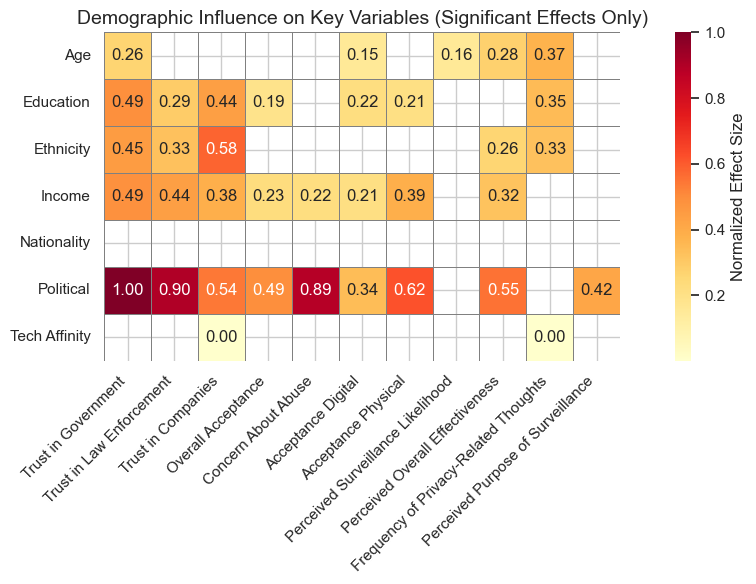

In [123]:

# Dictionary of values: (effect size, p-value)
data = {
    "Trust in Government": {
        "Age": (20.599, 0.0010),
        "Nationality": (1.756, 0.6247),
        "Ethnicity": (35.401, 0.0001),
        "Political": (78.330, 0.0000),
        "Income": (38.246, 0.0000),
        "Education": (38.480, 0.0000),
        "Tech Affinity": (abs(-0.028), 0.3737)
    },
    "Trust in Law Enforcement": {
        "Age": (5.116, 0.4019),
        "Nationality": (0.538, 0.9104),
        "Ethnicity": (25.671, 0.0042),
        "Political": (70.397, 0.0000),
        "Income": (34.347, 0.0000),
        "Education": (22.898, 0.0008),
        "Tech Affinity": (abs(-0.048), 0.1347)
    },
    "Trust in Companies": {
        "Age": (9.126, 0.1042),
        "Nationality": (3.144, 0.3699),
        "Ethnicity": (45.369, 0.0000),
        "Political": (42.396, 0.0000),
        "Income": (30.046, 0.0000),
        "Education": (34.582, 0.0000),
        "Tech Affinity": (abs(-0.074), 0.0197)
    },
    "Overall Acceptance": {
        "Age": (9.705, 0.0840),
        "Nationality": (1.056, 0.7878),
        "Ethnicity": (17.677, 0.0607),
        "Political": (38.767, 0.0000),
        "Income": (17.958, 0.0063),
        "Education": (14.940, 0.0207),
        "Tech Affinity": (abs(0.016), 0.6240)
    },
    "Concern About Abuse": {
        "Age": (6.908, 0.2276),
        "Nationality": (4.966, 0.1743),
        "Ethnicity": (13.602, 0.1919),
        "Political": (69.542, 0.0000),
        "Income": (17.342, 0.0081),
        "Education": (10.129, 0.1193),
        "Tech Affinity": (abs(0.016), 0.6111)
    },
    "Acceptance Digital": {
        "Age": (12.080, 0.0337),
        "Nationality": (0.163, 0.9833),
        "Ethnicity": (17.033, 0.0736),
        "Political": (26.868, 0.0002),
        "Income": (16.751, 0.0102),
        "Education": (17.337, 0.0081),
        "Tech Affinity": (abs(-0.029), 0.3720)
    },
    "Acceptance Physical": {
        "Age": (2.484, 0.7789),
        "Nationality": (1.931, 0.5869),
        "Ethnicity": (13.454, 0.1994),
        "Political": (48.591, 0.0000),
        "Income": (30.226, 0.0000),
        "Education": (16.331, 0.0121),
        "Tech Affinity": (abs(0.032), 0.3107)
    },
    "Perceived Surveillance Likelihood": {
        "Age": (12.295, 0.0310),
        "Nationality": (5.692, 0.1276),
        "Ethnicity": (17.285, 0.0683),
        "Political": (11.276, 0.0802),
        "Income": (5.641, 0.4645),
        "Education": (8.293, 0.2174),
        "Tech Affinity": (abs(-0.017), 0.5910)
    },
    "Perceived Overall Effectiveness": {
        "Age": (21.768, 0.0006),
        "Nationality": (4.601, 0.2034),
        "Ethnicity": (20.439, 0.0254),
        "Political": (43.360, 0.0000),
        "Income": (25.412, 0.0003),
        "Education": (6.335, 0.3867),
        "Tech Affinity": (0.040, 0.2149)
    },
    "Frequency of Privacy-Related Thoughts": {
        "Age": (29.145, 0.0000),
        "Nationality": (3.726, 0.2926),
        "Ethnicity": (25.491, 0.0045),
        "Political": (8.013, 0.2371),
        "Income": (12.072, 0.0604),
        "Education": (27.259, 0.0001),
        "Tech Affinity": (0.147, 0.0000)
    },
    "Perceived Purpose of Surveillance": {
        "Age": (5.859, 0.3202),
        "Nationality": (5.702, 0.1271),
        "Ethnicity": (14.383, 0.1562),
        "Political": (32.603, 0.0000),
        "Income": (11.584, 0.0719),
        "Education": (8.013, 0.2371),
        "Tech Affinity": (5.376, 0.1463)
    }
}

# Normalize effect sizes
all_effects = [val[0] for dv in data.values() for val in dv.values()]
max_effect = max(all_effects)
min_effect = min(all_effects)
range_effect = max_effect - min_effect if max_effect > min_effect else 1

# dataa frame
rows = sorted(set(k for dv in data.values() for k in dv.keys()))
cols = list(data.keys())
matrix = pd.DataFrame(index=rows, columns=cols)

for col in cols:
    for row in rows:
        eff, p = data[col].get(row, (np.nan, np.nan))
        if p > 0.05:
            matrix.loc[row, col] = np.nan
        else:
            matrix.loc[row, col] = (eff - min_effect) / range_effect

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(
    matrix.astype(float),
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor='gray',
    annot=True,
    fmt=".2f",
    cbar_kws={'label': 'Normalized Effect Size'},
    mask=matrix.isna(),
    square=True
)

plt.title("Demographic Influence on Key Variables (Significant Effects Only)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Non corrected. Perhaps do Benjamini-Hochberg correction (four would become insignificant)

In [124]:
# List of all p-values from your results
p_values = [
    0.0010, 0.6247, 0.0001, 0.0000, 0.0000, 0.0000, 0.3737,
    0.4019, 0.9104, 0.0042, 0.0000, 0.0000, 0.0008, 0.1347,
    0.1042, 0.3699, 0.0000, 0.0000, 0.0000, 0.0000, 0.0197,
    0.0840, 0.7878, 0.0607, 0.0000, 0.0063, 0.0207, 0.6240,
    0.2276, 0.1743, 0.1919, 0.0000, 0.0081, 0.1193, 0.6111,
    0.0337, 0.9833, 0.0736, 0.0002, 0.0102, 0.0081, 0.3720,
    0.7789, 0.5869, 0.1994, 0.0000, 0.0000, 0.0121, 0.3107,
    0.0310, 0.1276, 0.0683, 0.0802, 0.4645, 0.2174, 0.5910,
    0.0006, 0.2034, 0.0254, 0.0000, 0.0003, 0.3867, 0.2149,
    0.0000, 0.2926, 0.0045, 0.2371, 0.0604, 0.0001, 0.0000,
    0.3202, 0.1271, 0.1562, 0.0000, 0.0719, 0.2371, 0.1463
]

# Holm-Bonferroni correction (FWER control)
_, pvals_holm, _, _ = multipletests(p_values, method='holm')
significant_holm = sum(p < 0.05 for p in pvals_holm)

# Benjamini-Hochberg correction (FDR control)
_, pvals_bh, _, _ = multipletests(p_values, method='fdr_bh')
significant_bh = sum(p < 0.05 for p in pvals_bh)

print(f"Uncorrected significant: {sum(p < 0.05 for p in p_values)}")
print(f"Significant after Holm-Bonferroni: {significant_holm}")
print(f"Significant after Benjamini-Hochberg: {significant_bh}")


Uncorrected significant: 36
Significant after Holm-Bonferroni: 23
Significant after Benjamini-Hochberg: 33


In [125]:
# DV and IV
dvs = [
    "Trust in Government", "Trust in Law Enforcement", "Trust in Companies", "Overall Acceptance",
    "Concern About Surveillance Abuse", "Acceptance of Digital Methods", "Acceptance of Physical Methods",
    "Perceived Likelihood of Being Surveilled", "Perceived Overall Effectiveness",
    "Frequency of Privacy-Related Thoughts", "Perceived Purpose of Surveillance"
]

ivs = ["Age", "Nationality", "Ethnicity", "Political", "Income", "Education", "Tech Affinity"]

# List of p values
p_values = [
    0.0010, 0.6247, 0.0001, 0.0000, 0.0000, 0.0000, 0.3737,
    0.4019, 0.9104, 0.0042, 0.0000, 0.0000, 0.0008, 0.1347,
    0.1042, 0.3699, 0.0000, 0.0000, 0.0000, 0.0000, 0.0197,
    0.0840, 0.7878, 0.0607, 0.0000, 0.0063, 0.0207, 0.6240,
    0.2276, 0.1743, 0.1919, 0.0000, 0.0081, 0.1193, 0.6111,
    0.0337, 0.9833, 0.0736, 0.0002, 0.0102, 0.0081, 0.3720,
    0.7789, 0.5869, 0.1994, 0.0000, 0.0000, 0.0121, 0.3107,
    0.0310, 0.1276, 0.0683, 0.0802, 0.4645, 0.2174, 0.5910,
    0.0006, 0.2034, 0.0254, 0.0000, 0.0003, 0.3867, 0.2149,
    0.0000, 0.2926, 0.0045, 0.2371, 0.0604, 0.0001, 0.0000,
    0.3202, 0.1271, 0.1562, 0.0000, 0.0719, 0.2371, 0.1463
]

# Apply corrections
_, pvals_holm, _, _ = multipletests(p_values, method='holm')
_, pvals_bh, _, _ = multipletests(p_values, method='fdr_bh')

# dat frame
results = pd.DataFrame({
    "Dependent Variable": [dvs[i // 7] for i in range(77)],
    "Independent Variable": [ivs[i % 7] for i in range(77)],
    "Uncorrected p": p_values,
    "Significant (Uncorrected)": [p < 0.05 for p in p_values],
    "Significant (Holm-Bonferroni)": [p < 0.05 for p in pvals_holm],
    "Significant (Benjamini-Hochberg)": [p < 0.05 for p in pvals_bh]
})

# Filter only rows that are significant in at least one method
significant_any = results[
    results[["Significant (Uncorrected)", "Significant (Holm-Bonferroni)", "Significant (Benjamini-Hochberg)"]].any(axis=1)
]

# print
print(significant_any[[
    "Dependent Variable", "Independent Variable",
    "Significant (Uncorrected)", "Significant (Holm-Bonferroni)", "Significant (Benjamini-Hochberg)"
]])


                          Dependent Variable Independent Variable  \
0                        Trust in Government                  Age   
2                        Trust in Government            Ethnicity   
3                        Trust in Government            Political   
4                        Trust in Government               Income   
5                        Trust in Government            Education   
9                   Trust in Law Enforcement            Ethnicity   
10                  Trust in Law Enforcement            Political   
11                  Trust in Law Enforcement               Income   
12                  Trust in Law Enforcement            Education   
16                        Trust in Companies            Ethnicity   
17                        Trust in Companies            Political   
18                        Trust in Companies               Income   
19                        Trust in Companies            Education   
20                        Trust in

In [126]:

# DVs and labels
dv_vars = [
    "Trust_Gov", "Trust_Law", "Trust_Companies", "Accept_Overall", 
    "Concern_Abuse", "accept_digital_methods", "accept_physical_methods", 
    "Q135", "Eff_Overall", "Q157", "Q138"
]
dv_labels = [
    "Trust in Government", "Trust in Law Enforcement", "Trust in Companies",
    "Overall Acceptance", "Concern About Surveillance Abuse",
    "Acceptance of Digital Methods", "Acceptance of Physical Methods",
    "Perceived Likelihood of Being Surveilled",
    "Perceived Overall Effectiveness", 
    "Frequency of Privacy-Related Thoughts", 
    "Perceived Purpose of Surveillance"
]

# Reverse trust variables
for trust_var in ["Trust_Gov", "Trust_Law", "Trust_Companies"]:
    df_included[trust_var] = 6 - df_included[trust_var]

# Demographics and labels
demographics = {
    "Q130": "Age",
    "Q23": "Gender",
    "Ethnicity_Code": "Ethnicity",
    "Q106": "Education",
    "Q107": "Income",
    "Q28": "Political",
    "Q27_1": "Tech Affinity"
}

ordinal_demo_vars = ["Q130", "Q106", "Q107"]
binary_demo_vars = ["Q23"]
categorical_demo_vars = ["Ethnicity_Code", "Q28"]
continuous_demo_vars = ["Q27_1"]

ordinal_dvs = dv_vars[:-1]  # All but Q138
categorical_dvs = ["Q138"]

# Print results formatted
for dv_var, dv_label in zip(dv_vars, dv_labels):
    print(f"\n=== {dv_label} ===")
    for demo_var, demo_label in demographics.items():
        try:
            temp = df_included[[dv_var, demo_var]].dropna()

            # Clean
            if demo_var == "Q23":
                temp = temp[temp[demo_var].isin([1, 2])]
            if demo_var == "Q106":
                temp = temp[temp[demo_var] != 7]
            if demo_var == "Q107":
                temp = temp[temp[demo_var] != 7]
            if demo_var == "Q130":
                temp = temp[temp[demo_var] != 1]

            # Ordinal DVs
            if dv_var in ordinal_dvs:
                if demo_var in ordinal_demo_vars or demo_var in continuous_demo_vars:
                    r, p = spearmanr(temp[demo_var], temp[dv_var])
                    print(f"{demo_label}: Spearman r = {r:.3f}, p = {p:.4f}")
                elif demo_var in binary_demo_vars:
                    g1 = temp[temp[demo_var] == 1][dv_var]
                    g2 = temp[temp[demo_var] == 2][dv_var]
                    stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
                    print(f"{demo_label}: Mann-Whitney U = {stat:.3f}, p = {p:.4f}")
                else:
                    groups = [g[dv_var] for _, g in temp.groupby(demo_var)]
                    if all(len(g) > 1 for g in groups):
                        stat, p = kruskal(*groups)
                        print(f"{demo_label}: Kruskal-Wallis H = {stat:.3f}, p = {p:.4f}")

            # Categorical DV (Q138)
            elif dv_var in categorical_dvs:
                if demo_var in binary_demo_vars or demo_var in categorical_demo_vars:
                    contingency = pd.crosstab(temp[dv_var], temp[demo_var])
                    chi2, p, _, _ = chi2_contingency(contingency)
                    print(f"{demo_label}: Chi² = {chi2:.3f}, p = {p:.4f}")
                else:
                    groups = [g[demo_var] for _, g in temp.groupby(dv_var)]
                    if all(len(g) > 1 for g in groups):
                        stat, p = kruskal(*groups)
                        print(f"{demo_label}: Kruskal-Wallis H = {stat:.3f}, p = {p:.4f}")
        except Exception as e:
            print(f"{demo_label}: Error – {e}")



=== Trust in Government ===
Age: Spearman r = -0.139, p = 0.0000
Gender: Mann-Whitney U = 115844.000, p = 0.7090
Ethnicity: Kruskal-Wallis H = 35.401, p = 0.0001
Education: Spearman r = 0.183, p = 0.0000
Income: Spearman r = 0.188, p = 0.0000
Political: Kruskal-Wallis H = 78.330, p = 0.0000
Tech Affinity: Spearman r = 0.028, p = 0.3737

=== Trust in Law Enforcement ===
Age: Spearman r = -0.039, p = 0.2240
Gender: Mann-Whitney U = 112529.500, p = 0.2361
Ethnicity: Kruskal-Wallis H = 25.671, p = 0.0042
Education: Spearman r = 0.140, p = 0.0000
Income: Spearman r = 0.181, p = 0.0000
Political: Kruskal-Wallis H = 70.397, p = 0.0000
Tech Affinity: Spearman r = 0.048, p = 0.1347

=== Trust in Companies ===
Age: Spearman r = -0.064, p = 0.0442
Gender: Mann-Whitney U = 113292.500, p = 0.3225
Ethnicity: Kruskal-Wallis H = 45.369, p = 0.0000
Education: Spearman r = 0.153, p = 0.0000
Income: Spearman r = 0.164, p = 0.0000
Political: Kruskal-Wallis H = 42.396, p = 0.0000
Tech Affinity: Spearman r

In [127]:
# Store raw results
results = []

# DVs and labels
dv_vars = [
    "Trust_Gov", "Trust_Law", "Trust_Companies", "Accept_Overall", 
    "Concern_Abuse", "accept_digital_methods", "accept_physical_methods", 
    "Q135", "Eff_Overall", "Q157", "Q138"
]
dv_labels = [
    "Trust in Government", "Trust in Law Enforcement", "Trust in Companies",
    "Overall Acceptance", "Concern About Surveillance Abuse",
    "Acceptance of Digital Methods", "Acceptance of Physical Methods",
    "Perceived Likelihood of Being Surveilled",
    "Perceived Overall Effectiveness", 
    "Frequency of Privacy-Related Thoughts", 
    "Perceived Purpose of Surveillance"
]

# Reverse trust variables
for trust_var in ["Trust_Gov", "Trust_Law", "Trust_Companies"]:
    df_included[trust_var] = 6 - df_included[trust_var]

# Demographics and labels
demographics = {
    "Q130": "Age",
    "Q23": "Gender",
    "Ethnicity_Code": "Ethnicity",
    "Q106": "Education",
    "Q107": "Income",
    "Q28": "Political",
    "Q27_1": "Tech Affinity"
}

ordinal_demo_vars = ["Q130", "Q106", "Q107"]
binary_demo_vars = ["Q23"]
categorical_demo_vars = ["Ethnicity_Code", "Q28"]
continuous_demo_vars = ["Q27_1"]

ordinal_dvs = dv_vars[:-1]
categorical_dvs = ["Q138"]

# Collect results
for dv_var, dv_label in zip(dv_vars, dv_labels):
    for demo_var, demo_label in demographics.items():
        try:
            temp = df_included[[dv_var, demo_var]].dropna()

            if demo_var == "Q23":
                temp = temp[temp[demo_var].isin([1, 2])]
            if demo_var == "Q106":
                temp = temp[temp[demo_var] != 7]
            if demo_var == "Q107":
                temp = temp[temp[demo_var] != 7]
            if demo_var == "Q130":
                temp = temp[temp[demo_var] != 1]

            test_type = None
            stat = None
            p = None

            if dv_var in ordinal_dvs:
                if demo_var in ordinal_demo_vars or demo_var in continuous_demo_vars:
                    r, p = spearmanr(temp[demo_var], temp[dv_var])
                    test_type = "Spearman"
                    stat = r
                elif demo_var in binary_demo_vars:
                    g1 = temp[temp[demo_var] == 1][dv_var]
                    g2 = temp[temp[demo_var] == 2][dv_var]
                    stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
                    test_type = "Mann-Whitney"
                else:
                    groups = [g[dv_var] for _, g in temp.groupby(demo_var)]
                    if all(len(g) > 1 for g in groups):
                        stat, p = kruskal(*groups)
                        test_type = "Kruskal-Wallis"

            elif dv_var in categorical_dvs:
                if demo_var in binary_demo_vars or demo_var in categorical_demo_vars:
                    contingency = pd.crosstab(temp[dv_var], temp[demo_var])
                    chi2, p, _, _ = chi2_contingency(contingency)
                    stat = chi2
                    p = p
                    test_type = "Chi²"
                else:
                    groups = [g[demo_var] for _, g in temp.groupby(dv_var)]
                    if all(len(g) > 1 for g in groups):
                        stat, p = kruskal(*groups)
                        test_type = "Kruskal-Wallis"

            if stat is not None:
                results.append({
                    "DV": dv_label,
                    "Demographic": demo_label,
                    "Test": test_type,
                    "Stat": stat,
                    "p": p
                })

        except Exception as e:
            results.append({
                "DV": dv_label,
                "Demographic": demo_label,
                "Test": "Error",
                "Stat": None,
                "p": None,
                "Error": str(e)
            })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Normalize stats (except Spearman)
for test_type in ["Mann-Whitney", "Kruskal-Wallis", "Chi²"]:
    mask = results_df["Test"] == test_type
    if not results_df[mask].empty:
        min_val = results_df[mask]["Stat"].min()
        max_val = results_df[mask]["Stat"].max()
        results_df.loc[mask, "Normalized_Stat"] = (
            (results_df.loc[mask, "Stat"] - min_val) / (max_val - min_val)
        )

# Group results by DV for pretty printing
grouped = results_df.groupby("DV")

for dv_label, group in grouped:
    print(f"\n=== {dv_label} ===")
    for _, row in group.iterrows():
        test = row["Test"]
        demo = row["Demographic"]

        if test == "Spearman":
            print(f"{demo}: Spearman r = {row['Stat']:.3f}, p = {row['p']:.4f}")
        elif test in ["Mann-Whitney", "Kruskal-Wallis", "Chi²"]:
            norm = row.get("Normalized_Stat", None)
            if pd.notnull(norm):
                print(f"{demo}: {test} = {row['Stat']:.3f} (norm. {norm:.3f}), p = {row['p']:.4f}")
            else:
                print(f"{demo}: {test} = {row['Stat']:.3f}, p = {row['p']:.4f}")
        elif test == "Error":
            print(f"{demo}: Error – {row['Error']}")



=== Acceptance of Digital Methods ===
Age: Spearman r = -0.101, p = 0.0015
Gender: Mann-Whitney = 111691.000 (norm. 0.098), p = 0.1862
Ethnicity: Kruskal-Wallis = 17.033 (norm. 0.160), p = 0.0736
Education: Spearman r = 0.112, p = 0.0005
Income: Spearman r = 0.107, p = 0.0008
Political: Kruskal-Wallis = 26.868 (norm. 0.295), p = 0.0002
Tech Affinity: Spearman r = -0.029, p = 0.3720

=== Acceptance of Physical Methods ===
Age: Spearman r = -0.041, p = 0.2034
Gender: Mann-Whitney = 113551.000 (norm. 0.255), p = 0.3704
Ethnicity: Kruskal-Wallis = 13.454 (norm. 0.111), p = 0.1994
Education: Spearman r = 0.105, p = 0.0010
Income: Spearman r = 0.152, p = 0.0000
Political: Kruskal-Wallis = 48.591 (norm. 0.592), p = 0.0000
Tech Affinity: Spearman r = 0.032, p = 0.3107

=== Concern About Surveillance Abuse ===
Age: Spearman r = -0.004, p = 0.8893
Gender: Mann-Whitney = 118112.000 (norm. 0.640), p = 0.8769
Ethnicity: Kruskal-Wallis = 13.602 (norm. 0.113), p = 0.1919
Education: Spearman r = -0.0

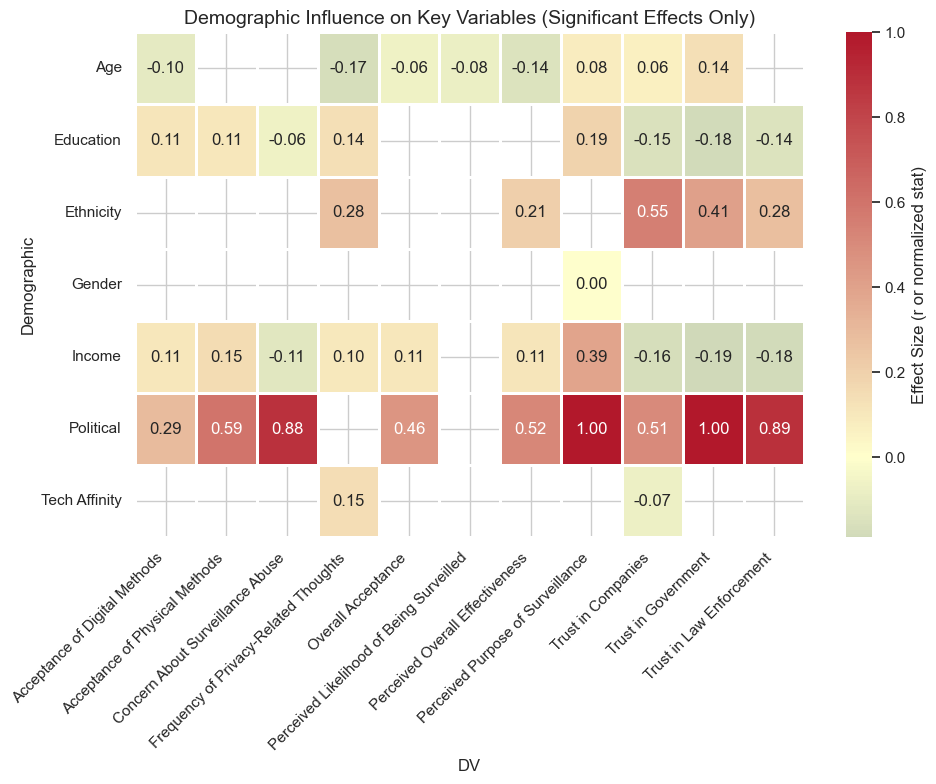

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Prepare the data again (significant only)
sig_df = results_df[(results_df["p"] < 0.05) & (results_df["Test"] != "Error")].copy()

def get_effect(row):
    if row["Test"] == "Spearman":
        return row["Stat"]  # -1 to 1
    else:
        return row["Normalized_Stat"]  # 0 to 1

sig_df["Effect"] = sig_df.apply(get_effect, axis=1)

# Pivot table
heatmap_data = sig_df.pivot(index="Demographic", columns="DV", values="Effect")
heatmap_data = heatmap_data.loc[sorted(heatmap_data.index), sorted(heatmap_data.columns)]

# Custom colormap: blue for negative, yellow center (0), red for positive
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_diverging",
    ["#0c3b6a", "#ffffcc", "#b2182b"],  # deep blue → yellow → deep red
    N=256
)

# Draw heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    center=0,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Effect Size (r or normalized stat)"}
)

plt.title("Demographic Influence on Key Variables (Significant Effects Only)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [129]:


ethnicity_effects = [
    "Q157", "Eff_Overall", "Trust_Companies", "Trust_Gov", "Trust_Law"
]

# Define mapping for Ethnicity_Code
ethnicity_map = {
    1: "White",
    2: "Black",
    3: "Asian",
    4: "Hispanic/Latino",
    5: "Native American",
    6: "Other",
    7: "Multiracial",
    8: "Prefer not to say"
}

# Map to readable labels
df_included["Ethnicity_Label"] = df_included["Ethnicity_Code"].map(ethnicity_map)

# Loop over each significant DV
for dv in ethnicity_effects:
    if dv not in df_included.columns:
        print(f"Skipping {dv} — not found.")
        continue

    temp = df_included[[dv, "Ethnicity_Label"]].dropna()

    # Exclude "Prefer not to say"
    temp = temp[temp["Ethnicity_Label"] != "Prefer not to say"]

    if temp["Ethnicity_Label"].nunique() < 2:
        print(f"Skipping {dv} — only one group left.")
        continue

    # Print group means
    print(f"\n=== {dv} by Ethnicity ===")
    means = temp.groupby("Ethnicity_Label")[dv].mean().sort_values()
    print(means.round(3))



=== Q157 by Ethnicity ===
Ethnicity_Label
Native American    2.833
Multiracial        3.062
Hispanic/Latino    3.093
Black              3.194
White              3.258
Other              3.421
Asian              3.578
Name: Q157, dtype: float64

=== Eff_Overall by Ethnicity ===
Ethnicity_Label
Multiracial        3.109
Other              3.145
Hispanic/Latino    3.273
White              3.311
Native American    3.375
Black              3.411
Asian              3.569
Name: Eff_Overall, dtype: float64

=== Trust_Companies by Ethnicity ===
Ethnicity_Label
Asian              2.563
White              2.946
Hispanic/Latino    3.130
Native American    3.250
Other              3.316
Multiracial        3.438
Black              3.597
Name: Trust_Companies, dtype: float64

=== Trust_Gov by Ethnicity ===
Ethnicity_Label
Asian              2.837
White              3.156
Hispanic/Latino    3.185
Other              3.395
Multiracial        3.531
Black              3.581
Native American    3.792
Name: 

In [130]:
# Map Ethnicity_Code to readable labels
ethnicity_map = {
    1: "White", 2: "Black", 3: "Asian", 4: "Hispanic/Latino",
    5: "Native American", 6: "Other", 7: "Multiracial"
}

# Prepare data
temp = df_included[["Eff_Overall", "Ethnicity_Code"]].dropna()
temp = temp[temp["Ethnicity_Code"].isin(ethnicity_map.keys())]  # filter valid codes

# Dunn test
dunn = sp.posthoc_dunn(temp, val_col="Eff_Overall", group_col="Ethnicity_Code", p_adjust="holm")

# Rename with mapped labels
labels = [ethnicity_map[i] for i in dunn.index]
dunn.index = labels
dunn.columns = labels

#print
print(dunn.round(3))


                 White  Black  Asian  Hispanic/Latino  Native American  Other  \
White            1.000    1.0  0.002            1.000              1.0    1.0   
Black            1.000    1.0  1.000            1.000              1.0    1.0   
Asian            0.002    1.0  1.000            0.301              1.0    1.0   
Hispanic/Latino  1.000    1.0  0.301            1.000              1.0    1.0   
Native American  1.000    1.0  1.000            1.000              1.0    1.0   
Other            1.000    1.0  1.000            1.000              1.0    1.0   
Multiracial      1.000    1.0  1.000            1.000              1.0    1.0   

                 Multiracial  
White                    1.0  
Black                    1.0  
Asian                    1.0  
Hispanic/Latino          1.0  
Native American          1.0  
Other                    1.0  
Multiracial              1.0  


In [131]:
# Prepare data
temp = df_included[["Q157", "Ethnicity_Code"]].dropna()
temp = temp[temp["Ethnicity_Code"].isin(ethnicity_map.keys())]  # filter valid codes

# Dunn test
dunn = sp.posthoc_dunn(temp, val_col="Q157", group_col="Ethnicity_Code", p_adjust="holm")

# Rename with mapped labels
labels = [ethnicity_map[i] for i in dunn.index]
dunn.index = labels
dunn.columns = labels

#print
print(dunn.round(3))

                 White  Black  Asian  Hispanic/Latino  Native American  Other  \
White            1.000  1.000  0.005            1.000            1.000    1.0   
Black            1.000  1.000  0.057            1.000            1.000    1.0   
Asian            0.005  0.057  1.000            0.006            0.124    1.0   
Hispanic/Latino  1.000  1.000  0.006            1.000            1.000    1.0   
Native American  1.000  1.000  0.124            1.000            1.000    1.0   
Other            1.000  1.000  1.000            1.000            1.000    1.0   
Multiracial      1.000  1.000  0.405            1.000            1.000    1.0   

                 Multiracial  
White                  1.000  
Black                  1.000  
Asian                  0.405  
Hispanic/Latino        1.000  
Native American        1.000  
Other                  1.000  
Multiracial            1.000  


In [132]:
# Prepare data
temp = df_included[["Trust_Companies", "Ethnicity_Code"]].dropna()
temp = temp[temp["Ethnicity_Code"].isin(ethnicity_map.keys())]  # filter valid codes

#Dunn test
dunn = sp.posthoc_dunn(temp, val_col="Trust_Companies", group_col="Ethnicity_Code", p_adjust="holm")

# Rename with mapped labels
labels = [ethnicity_map[i] for i in dunn.index]
dunn.index = labels
dunn.columns = labels

#oprint
print(dunn.round(3))


                 White  Black  Asian  Hispanic/Latino  Native American  Other  \
White            1.000  0.001  0.024            1.000              1.0  1.000   
Black            0.001  1.000  0.000            0.708              1.0  1.000   
Asian            0.024  0.000  1.000            0.058              1.0  0.294   
Hispanic/Latino  1.000  0.708  0.058            1.000              1.0  1.000   
Native American  1.000  1.000  1.000            1.000              1.0  1.000   
Other            1.000  1.000  0.294            1.000              1.0  1.000   
Multiracial      1.000  1.000  0.100            1.000              1.0  1.000   

                 Multiracial  
White                    1.0  
Black                    1.0  
Asian                    0.1  
Hispanic/Latino          1.0  
Native American          1.0  
Other                    1.0  
Multiracial              1.0  


In [133]:
# Prepare data
temp = df_included[["Trust_Gov", "Ethnicity_Code"]].dropna()
temp = temp[temp["Ethnicity_Code"].isin(ethnicity_map.keys())]  # filter valid codes

#Dunn test
dunn = sp.posthoc_dunn(temp, val_col="Trust_Gov", group_col="Ethnicity_Code", p_adjust="holm")

# Rename with mapped labels
labels = [ethnicity_map[i] for i in dunn.index]
dunn.index = labels
dunn.columns = labels

#print
print(dunn.round(3))

                 White  Black  Asian  Hispanic/Latino  Native American  Other  \
White            1.000  0.072  0.043            1.000            0.815  1.000   
Black            0.072  1.000  0.000            0.788            1.000  1.000   
Asian            0.043  0.000  1.000            0.788            0.102  0.788   
Hispanic/Latino  1.000  0.788  0.788            1.000            1.000  1.000   
Native American  0.815  1.000  0.102            1.000            1.000  1.000   
Other            1.000  1.000  0.788            1.000            1.000  1.000   
Multiracial      1.000  1.000  0.360            1.000            1.000  1.000   

                 Multiracial  
White                   1.00  
Black                   1.00  
Asian                   0.36  
Hispanic/Latino         1.00  
Native American         1.00  
Other                   1.00  
Multiracial             1.00  


In [134]:
# Prepare data
temp = df_included[["Trust_Law", "Ethnicity_Code"]].dropna()
temp = temp[temp["Ethnicity_Code"].isin(ethnicity_map.keys())]  # filter valid codes

#Dunn test
dunn = sp.posthoc_dunn(temp, val_col="Trust_Law", group_col="Ethnicity_Code", p_adjust="holm")

# Rename with mapped labels
labels = [ethnicity_map[i] for i in dunn.index]
dunn.index = labels
dunn.columns = labels

#print
print(dunn.round(3))

                 White  Black  Asian  Hispanic/Latino  Native American  Other  \
White            1.000  0.069  1.000              1.0              1.0  0.762   
Black            0.069  1.000  0.762              1.0              1.0  1.000   
Asian            1.000  0.762  1.000              1.0              1.0  1.000   
Hispanic/Latino  1.000  1.000  1.000              1.0              1.0  1.000   
Native American  1.000  1.000  1.000              1.0              1.0  1.000   
Other            0.762  1.000  1.000              1.0              1.0  1.000   
Multiracial      1.000  1.000  1.000              1.0              1.0  1.000   

                 Multiracial  
White                    1.0  
Black                    1.0  
Asian                    1.0  
Hispanic/Latino          1.0  
Native American          1.0  
Other                    1.0  
Multiracial              1.0  


In [135]:
# Define significant DVs for political
political_effects = [
    "Trust_Gov", "Trust_Law", "Trust_Companies", "Accept_Overall",
    "Concern_Abuse", "accept_digital_methods", "accept_physical_methods",
    "Eff_Overall"
]

# Map political codes to labels
political_map = {
    1: "Democratic",
    2: "Republican",
    3: "Independent"
}

# Create label column
df_included["Political_Label"] = df_included["Q28"].map(political_map)

# Loop and print group means
for dv in political_effects:
    if dv not in df_included.columns:
        continue

    temp = df_included[[dv, "Political_Label"]].dropna()
    temp = temp[temp["Political_Label"].isin(political_map.values())]

    if temp["Political_Label"].nunique() < 2:
        continue

    print(f"\n=== {dv} by Political Affiliation ===")
    print(temp.groupby("Political_Label")[dv].mean().round(3))



=== Trust_Gov by Political Affiliation ===
Political_Label
Democratic     3.364
Independent    3.504
Republican     2.803
Name: Trust_Gov, dtype: float64

=== Trust_Law by Political Affiliation ===
Political_Label
Democratic     3.003
Independent    3.042
Republican     2.452
Name: Trust_Law, dtype: float64

=== Trust_Companies by Political Affiliation ===
Political_Label
Democratic     3.059
Independent    3.310
Republican     2.721
Name: Trust_Companies, dtype: float64

=== Accept_Overall by Political Affiliation ===
Political_Label
Democratic     3.195
Independent    3.106
Republican     3.512
Name: Accept_Overall, dtype: float64

=== Concern_Abuse by Political Affiliation ===
Political_Label
Democratic     4.058
Independent    4.190
Republican     3.645
Name: Concern_Abuse, dtype: float64

=== accept_digital_methods by Political Affiliation ===
Political_Label
Democratic     2.043
Independent    2.049
Republican     1.822
Name: accept_digital_methods, dtype: float64

=== accept_ph

In [136]:
# Mapping for Q138 and Q28
q138_map = {
    1: "Protect citizens",
    2: "Limit freedoms",
    3: "Neither",
    4: "Both"
}
political_map = {
    1: "Democratic",
    2: "Republican",
    3: "Independent"
}

# Filter and map
temp = df_included[
    df_included["Q28"].isin(political_map.keys()) & df_included["Q138"].isin(q138_map.keys())
].copy()

temp["Political_Label"] = temp["Q28"].map(political_map)
temp["Q138_Label"] = temp["Q138"].map(q138_map)

# Crosstab to get percentages
percentage_table = pd.crosstab(
    temp["Political_Label"], temp["Q138_Label"], normalize="index"
) * 100

# Round and print
print(percentage_table.round(1))


Q138_Label       Both  Limit freedoms  Neither  Protect citizens
Political_Label                                                 
Democratic       27.9            28.2      9.3              34.6
Independent      33.8            26.8     16.2              23.2
Republican       22.5            21.9     12.0              43.6


In [137]:


def run_dunn_political(dv):
    """
    Run Dunn post-hoc test for a given DV by political affiliation (Q28).
    Only includes Democratic, Republican, and Independent.
    """
    political_map = {
        1: "Democratic",
        2: "Republican",
        3: "Independent"
    }

    temp = df_included[[dv, "Q28"]].dropna()
    temp = temp[temp["Q28"].isin(political_map.keys())]

    dunn = sp.posthoc_dunn(temp, val_col=dv, group_col="Q28", p_adjust="holm")
    dunn.index = dunn.columns = [political_map[i] for i in dunn.index]

    print(f"\n=== Dunn Test for {dv} ===")
    print(dunn.round(3))


In [138]:
for dv in political_effects:
    run_dunn_political(dv)



=== Dunn Test for Trust_Gov ===
             Democratic  Republican  Independent
Democratic        1.000         0.0        0.216
Republican        0.000         1.0        0.000
Independent       0.216         0.0        1.000

=== Dunn Test for Trust_Law ===
             Democratic  Republican  Independent
Democratic         1.00         0.0         0.64
Republican         0.00         1.0         0.00
Independent        0.64         0.0         1.00

=== Dunn Test for Trust_Companies ===
             Democratic  Republican  Independent
Democratic         1.00         0.0         0.03
Republican         0.00         1.0         0.00
Independent        0.03         0.0         1.00

=== Dunn Test for Accept_Overall ===
             Democratic  Republican  Independent
Democratic        1.000         0.0        0.326
Republican        0.000         1.0        0.000
Independent       0.326         0.0        1.000

=== Dunn Test for Concern_Abuse ===
             Democratic  Republican 

# 12. Further Analysis

In [139]:
# Variables of interest
dv_list = [
    'Eff_Overall', 'Trust_Gov', 'Trust_Law', 'Trust_Companies', 
    'Concern_Abuse', 'perceived_likelihood'
]


In [140]:
# Run Kruskal-Wallis tests
for var in dv_list:
    grouped_data = [
        df_included[df_included['Sector_Group_Strict'] == group][var].dropna()
        for group in df_included['Sector_Group_Strict'].dropna().unique()
    ]
    if all(len(g) > 1 for g in grouped_data):  # skip if too few samples
        stat, p = kruskal(*grouped_data)
        print(f"{var}: H = {stat:.3f}, p = {p:.4f}")


Eff_Overall: H = 11.039, p = 0.0261
Trust_Gov: H = 19.591, p = 0.0006
Trust_Law: H = 4.393, p = 0.3555
Trust_Companies: H = 17.129, p = 0.0018
Concern_Abuse: H = 5.693, p = 0.2233
perceived_likelihood: H = 12.563, p = 0.0136


In [141]:
# Binary flags for sector exposure
df_included['Worked_Gov'] = df_included[['Q134_4', 'Q134_5', 'Q134_6']].eq(1.0).any(axis=1)
df_included['Worked_Tech'] = df_included[['Q134_7', 'Q134_8']].eq(1.0).any(axis=1)


# Assign to exclusive groups
def classify_sector_exclusive(row):
    gov = row['Worked_Gov']
    tech = row['Worked_Tech']
    
    if gov and not tech:
        return 'Only_Gov'
    elif tech and not gov:
        return 'Only_Tech'
    elif gov and tech:
        return 'Both'
    else:
        return 'Neither'

df_included['Sector_Group_Exclusive'] = df_included.apply(classify_sector_exclusive, axis=1)

#Print
group_counts = df_included['Sector_Group_Exclusive'].value_counts()
print("=== Sector Group Counts ===")
print(group_counts)


=== Sector Group Counts ===
Sector_Group_Exclusive
Neither      625
Only_Tech    216
Only_Gov     103
Both          38
Name: count, dtype: int64


In [142]:
# Kruskal-Wallis analysis for each DV
print("=== Kruskal-Wallis Test Results by Sector Group ===\n")

for dv in dv_list:
    # Drop missing values for current DV and group
    subset = df_included[['Sector_Group_Exclusive', dv]].dropna()
    
    # Group values by sector group
    group_data = {
        group: subset[subset['Sector_Group_Exclusive'] == group][dv].values
        for group in ['Only_Gov', 'Only_Tech', 'Both', 'Neither']
        if group in subset['Sector_Group_Exclusive'].unique()
    }
    
    # Only run test if we have at least 2 groups with data
    if len(group_data) >= 2:
        stat, p = kruskal(*group_data.values())
        print(f"{dv}: H = {stat:.3f}, p = {p:.4f}")
    else:
        print(f"{dv}: Not enough groups with data for Kruskal-Wallis test.")


=== Kruskal-Wallis Test Results by Sector Group ===

Eff_Overall: H = 11.039, p = 0.0115
Trust_Gov: H = 18.569, p = 0.0003
Trust_Law: H = 4.126, p = 0.2482
Trust_Companies: H = 17.018, p = 0.0007
Concern_Abuse: H = 5.358, p = 0.1474
perceived_likelihood: H = 12.404, p = 0.0061


In [143]:

# Define variables
ordinal_vars = [
    'Accept_Overall', 'Eff_Overall', 'Trust_Gov', 'Trust_Law', 'Trust_Companies',
    'Concern_Abuse', 'perceived_likelihood', 'Q157'
]
categorical_vars = ['Invasiveness_Merged', 'Q8']

# Filter only male (1) and female (2)
df_gender = df_included[df_included['Q23'].isin([1, 2])].copy()

# Drop missing values
df_gender = df_gender[ordinal_vars + categorical_vars + ['Q23']].dropna()

# Spearman correlations (ordinal vars)
results = []
for var in ordinal_vars:
    r, p = stats.spearmanr(df_gender['Q23'], df_gender[var])
    results.append({'Variable': var, 'Test': 'Spearman', 'r_or_stat': round(r, 3), 'p_value': round(p, 4)})

# Chi-square tests (categorical vars)
for var in categorical_vars:
    contingency = pd.crosstab(df_gender['Q23'], df_gender[var])
    chi2, p, _, _ = stats.chi2_contingency(contingency)
    results.append({'Variable': var, 'Test': 'Chi²', 'r_or_stat': round(chi2, 3), 'p_value': round(p, 4)})

# Results as DataFrame
results_df = pd.DataFrame(results)
print(results_df)


               Variable      Test  r_or_stat  p_value
0        Accept_Overall  Spearman      0.051   0.1096
1           Eff_Overall  Spearman     -0.006   0.8546
2             Trust_Gov  Spearman     -0.012   0.7091
3             Trust_Law  Spearman     -0.038   0.2362
4       Trust_Companies  Spearman     -0.032   0.3227
5         Concern_Abuse  Spearman     -0.005   0.8769
6  perceived_likelihood  Spearman     -0.034   0.2851
7                  Q157  Spearman     -0.001   0.9681
8   Invasiveness_Merged      Chi²      3.209   0.2010
9                    Q8      Chi²      0.573   0.7508


Gender has no influence

In [144]:
# Define variables
ordinal_vars = [
    'Accept_Overall', 'Eff_Overall', 'Trust_Gov', 'Trust_Law', 'Trust_Companies',
    'Concern_Abuse', 'perceived_likelihood', 'Q157'
]
categorical_vars = ['Invasiveness_Merged', 'Q8']

# Filter for minority = 1 (yes) and non-minority = 2 (no), exclude 3 (rather not say)
df_minority = df_included[df_included['Q21.1'].isin([1, 2])].copy()

# Drop rows with missing values
df_minority = df_minority[ordinal_vars + categorical_vars + ['Q21.1']].dropna()

# Kruskal-Wallis for ordinal variables
results = []
for var in ordinal_vars:
    group1 = df_minority[df_minority['Q21.1'] == 1][var]  # Minority
    group2 = df_minority[df_minority['Q21.1'] == 2][var]  # Not minority
    stat, p = stats.kruskal(group1, group2)
    results.append({'Variable': var, 'Test': 'Kruskal-Wallis', 'r_or_stat': round(stat, 3), 'p_value': round(p, 4)})

# Chi-square tests for categorical variables
for var in categorical_vars:
    contingency = pd.crosstab(df_minority['Q21.1'], df_minority[var])
    chi2, p, _, _ = stats.chi2_contingency(contingency)
    results.append({'Variable': var, 'Test': 'Chi²', 'r_or_stat': round(chi2, 3), 'p_value': round(p, 4)})

# print
results_df = pd.DataFrame(results)
print(results_df)


               Variable            Test  r_or_stat  p_value
0        Accept_Overall  Kruskal-Wallis      9.338   0.0022
1           Eff_Overall  Kruskal-Wallis      0.469   0.4936
2             Trust_Gov  Kruskal-Wallis     21.821   0.0000
3             Trust_Law  Kruskal-Wallis     40.175   0.0000
4       Trust_Companies  Kruskal-Wallis     14.313   0.0002
5         Concern_Abuse  Kruskal-Wallis     14.883   0.0001
6  perceived_likelihood  Kruskal-Wallis     10.925   0.0009
7                  Q157  Kruskal-Wallis      0.865   0.3523
8   Invasiveness_Merged            Chi²      4.126   0.1271
9                    Q8            Chi²      0.084   0.9589


In [145]:

# Define ordinal outcome variables
ordinal_vars = [
    'Accept_Overall', 'Eff_Overall', 'Trust_Gov', 'Trust_Law', 'Trust_Companies',
    'Concern_Abuse', 'perceived_likelihood', 'Q157'
]

# Filter dataset: only Q21.1 == 1 (Yes) or 2 (No)
df_minority = df_included[df_included['Q21.1'].isin([1, 2])].copy()

# Drop missing values
df_minority = df_minority[ordinal_vars + ['Q21.1']].dropna()

# Run Mann-Whitney U tests
results = []
for var in ordinal_vars:
    group_yes = df_minority[df_minority['Q21.1'] == 1][var]
    group_no = df_minority[df_minority['Q21.1'] == 2][var]
    
    stat, p = mannwhitneyu(group_yes, group_no, alternative='two-sided')
    
    results.append({
        'Variable': var,
        'Test': 'Mann-Whitney U',
        'U_stat': round(stat, 3),
        'p_value': round(p, 4)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)


               Variable            Test    U_stat  p_value
0        Accept_Overall  Mann-Whitney U   88489.0   0.0022
1           Eff_Overall  Mann-Whitney U   97813.5   0.4937
2             Trust_Gov  Mann-Whitney U  118757.5   0.0000
3             Trust_Law  Mann-Whitney U  124425.0   0.0000
4       Trust_Companies  Mann-Whitney U  114949.0   0.0002
5         Concern_Abuse  Mann-Whitney U  115462.0   0.0001
6  perceived_likelihood  Mann-Whitney U  112972.0   0.0009
7                  Q157  Mann-Whitney U  103960.5   0.3524


Distribution per source:

Q21.2_1:
Q21.2_1
1.0    93
2.0    96
3.0    70
4.0    49
5.0    27
Name: count, dtype: int64

Q21.2_2:
Q21.2_2
1.0     83
2.0    113
3.0     61
4.0     55
5.0     23
Name: count, dtype: int64

Q21.2_3:
Q21.2_3
1.0     61
2.0    124
3.0     68
4.0     59
5.0     23
Name: count, dtype: int64


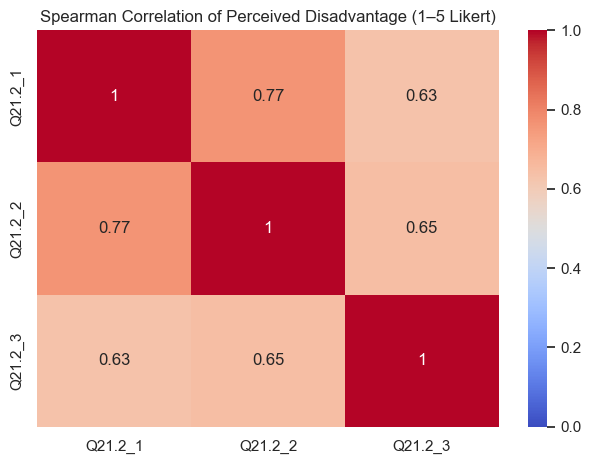


Number of 'high disadvantage' responses per person:
high_total
0    217
1     45
2     28
3     45
Name: count, dtype: int64


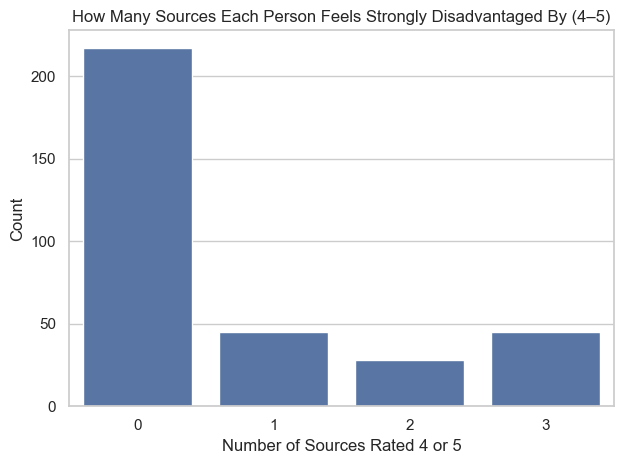

In [146]:
# Disadvantage Likert-scale variables (1–5)
disadv_vars = ['Q21.2_1', 'Q21.2_2', 'Q21.2_3']
df_disadv = df_included[disadv_vars].dropna().copy()

# 1. Descriptive stats and distributions
print("Distribution per source:")
for var in disadv_vars:
    print(f"\n{var}:")
    print(df_disadv[var].value_counts().sort_index())

# 2. Spearman correlations between the 3 items
cor_matrix = df_disadv.corr(method='spearman')
sns.heatmap(cor_matrix, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Spearman Correlation of Perceived Disadvantage (1–5 Likert)")
plt.tight_layout()
plt.show()

# 3. Count co-occurrence of high (4–5) responses
# Recode into "high" (4–5) = 1, else 0
binary_high = df_disadv[disadv_vars].apply(lambda x: x >= 4)
binary_high['high_total'] = binary_high.sum(axis=1)

# Count how many people gave high scores to 0, 1, 2, or all 3 sources
print("\nNumber of 'high disadvantage' responses per person:")
print(binary_high['high_total'].value_counts().sort_index())

# plot
sns.countplot(data=binary_high, x='high_total')
plt.title("How Many Sources Each Person Feels Strongly Disadvantaged By (4–5)")
plt.xlabel("Number of Sources Rated 4 or 5")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


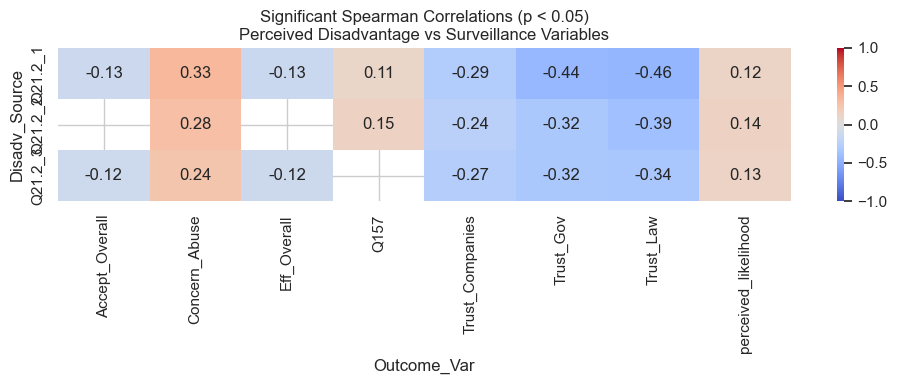

   Disadv_Source           Outcome_Var  Spearman_r  p_value
0        Q21.2_1        Accept_Overall      -0.127   0.0200
1        Q21.2_1           Eff_Overall      -0.134   0.0139
2        Q21.2_1             Trust_Gov      -0.438   0.0000
3        Q21.2_1             Trust_Law      -0.456   0.0000
4        Q21.2_1       Trust_Companies      -0.289   0.0000
5        Q21.2_1         Concern_Abuse       0.331   0.0000
6        Q21.2_1  perceived_likelihood       0.122   0.0255
7        Q21.2_1                  Q157       0.109   0.0471
8        Q21.2_2             Trust_Gov      -0.322   0.0000
9        Q21.2_2             Trust_Law      -0.389   0.0000
10       Q21.2_2       Trust_Companies      -0.242   0.0000
11       Q21.2_2         Concern_Abuse       0.282   0.0000
12       Q21.2_2  perceived_likelihood       0.137   0.0121
13       Q21.2_2                  Q157       0.147   0.0071
14       Q21.2_3        Accept_Overall      -0.116   0.0340
15       Q21.2_3           Eff_Overall  

In [147]:

# Define variable sets
disadv_vars = ['Q21.2_1', 'Q21.2_2', 'Q21.2_3'] #1: Government 2:Police 3:People of their country
surveillance_vars = [
    'Accept_Overall', 'Eff_Overall', 
    'Trust_Gov', 'Trust_Law', 'Trust_Companies',  # to be flipped
    'Concern_Abuse', 'perceived_likelihood', 'Q157' #How often do you consciously think about your digital or physical privacy in everyday life?
]

# Prepare DataFrame
corr_df = df_included[disadv_vars + surveillance_vars].dropna().copy()

# Reverse code the disadvantage variables (1 = strongly agree → 5 = strongly disagree → flip to 1 = disagree → 5 = agree)
for d in disadv_vars:
    corr_df[d] = 6 - corr_df[d]

# Reverse trust variables as well (same logic)
for trust_var in ['Trust_Gov', 'Trust_Law', 'Trust_Companies']:
    corr_df[trust_var] = 6 - corr_df[trust_var]

# Run Spearman correlations, filter p < 0.05
results = []
for d_var in disadv_vars:
    for s_var in surveillance_vars:
        r, p = spearmanr(corr_df[d_var], corr_df[s_var])
        if p < 0.05:
            results.append({
                'Disadv_Source': d_var,
                'Outcome_Var': s_var,
                'Spearman_r': round(r, 3),
                'p_value': round(p, 4)
            })

# Convert to DataFrame
filtered_df = pd.DataFrame(results)

# Plot
if not filtered_df.empty:
    pivot = filtered_df.pivot(index='Disadv_Source', columns='Outcome_Var', values='Spearman_r')
    plt.figure(figsize=(10, 4))
    sns.heatmap(pivot, annot=True, center=0, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title("Significant Spearman Correlations (p < 0.05)\nPerceived Disadvantage vs Surveillance Variables")
    plt.tight_layout()
    plt.show()
else:
    print("No statistically significant correlations (p < 0.05).")

# print
print(filtered_df)


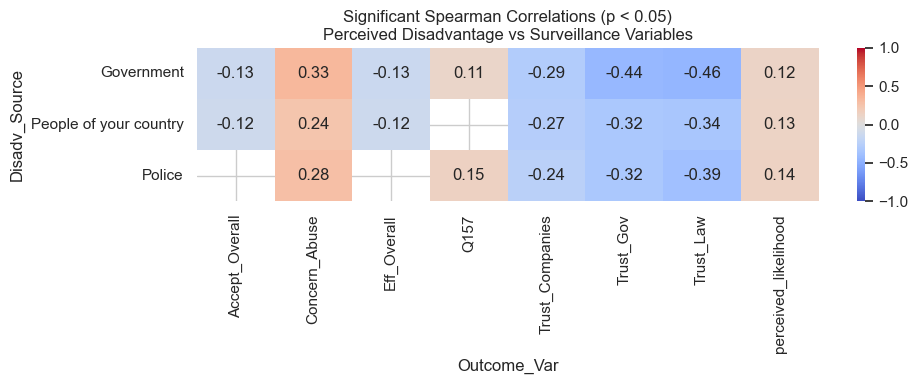

             Disadv_Source           Outcome_Var  Spearman_r  p_value
0               Government        Accept_Overall      -0.127   0.0200
1               Government           Eff_Overall      -0.134   0.0139
2               Government             Trust_Gov      -0.438   0.0000
3               Government             Trust_Law      -0.456   0.0000
4               Government       Trust_Companies      -0.289   0.0000
5               Government         Concern_Abuse       0.331   0.0000
6               Government  perceived_likelihood       0.122   0.0255
7               Government                  Q157       0.109   0.0471
8                   Police             Trust_Gov      -0.322   0.0000
9                   Police             Trust_Law      -0.389   0.0000
10                  Police       Trust_Companies      -0.242   0.0000
11                  Police         Concern_Abuse       0.282   0.0000
12                  Police  perceived_likelihood       0.137   0.0121
13                  

In [148]:

# Define variable sets
disadv_vars = ['Q21.2_1', 'Q21.2_2', 'Q21.2_3']  # 1: Government 2: Police 3: People of their country
surveillance_vars = [
    'Accept_Overall', 'Eff_Overall',
    'Trust_Gov', 'Trust_Law', 'Trust_Companies',
    'Concern_Abuse', 'perceived_likelihood', 'Q157'
]

# Mapping for nicer labels
disadv_map = {
    'Q21.2_1': 'Government',
    'Q21.2_2': 'Police',
    'Q21.2_3': 'People of your country'
}

# Prepare DataFrame
corr_df = df_included[disadv_vars + surveillance_vars].dropna().copy()

# Reverse code disadvantage variables
for d in disadv_vars:
    corr_df[d] = 6 - corr_df[d]

# Reverse trust variables
for trust_var in ['Trust_Gov', 'Trust_Law', 'Trust_Companies']:
    corr_df[trust_var] = 6 - corr_df[trust_var]

# Run Spearman correlations, filter p < 0.05
results = []
for d_var in disadv_vars:
    for s_var in surveillance_vars:
        r, p = spearmanr(corr_df[d_var], corr_df[s_var])
        if p < 0.05:
            results.append({
                'Disadv_Source': disadv_map[d_var],  # apply mapping here
                'Outcome_Var': s_var,
                'Spearman_r': round(r, 3),
                'p_value': round(p, 4)
            })

# Convert to DataFrame
filtered_df = pd.DataFrame(results)

# Plot
if not filtered_df.empty:
    pivot = filtered_df.pivot(
        index='Disadv_Source',
        columns='Outcome_Var',
        values='Spearman_r'
    )
    plt.figure(figsize=(10, 4))
    sns.heatmap(pivot, annot=True, center=0, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title("Significant Spearman Correlations (p < 0.05)\nPerceived Disadvantage vs Surveillance Variables")
    plt.tight_layout()
    plt.show()
else:
    print("No statistically significant correlations (p < 0.05).")

# print
print(filtered_df)
